In [1]:
import torch.nn.functional as F
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math
import time
import os

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Helper function

In [2]:
def lorenz_system(t, state, sigma=10, beta=8/3, rho=28):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

def van_der_pol(t, state, mu=1.0):
    x, y = state
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

In [3]:
def plot_output(data,generated):
    plt.figure(figsize=(12, 6))
    for i, label in enumerate(['x', 'y']):
        plt.subplot(2, 1, i+1)
        plt.plot(data[:, i], label=f'True {label}')
        plt.plot(generated[:, i], label=f'Predicted {label}')
        plt.legend()
        plt.ylabel(label)
    plt.xlabel('Time Steps')
    plt.suptitle('True vs Predicted')
    plt.show()

# Generate Data

In [4]:
np.random.seed(8)
torch.manual_seed(8)

epochs = 20

# Simulate the Van der Pol system
t_span = (0, 50*epochs)
t_eval = np.linspace(t_span[0], t_span[1], 10000*epochs)
initial_state = [1.0, 0.0]
solution = solve_ivp(van_der_pol, t_span, initial_state, t_eval=t_eval)
data = solution.y.T

# Normalize the data
data_mean = data.mean(axis=0)
data_std = data.std(axis=0)
data_normalized = (data - data_mean) / data_std
data_normalized = data_normalized - data_normalized.mean()

train_data = data_normalized[:] 

X_train = torch.tensor(train_data, dtype=torch.float32).to(device)

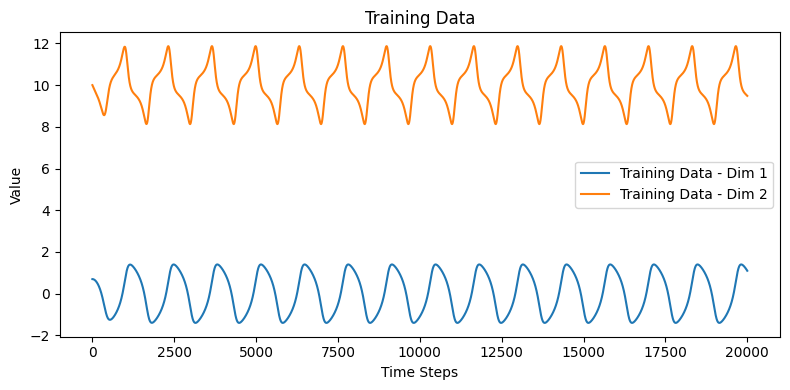

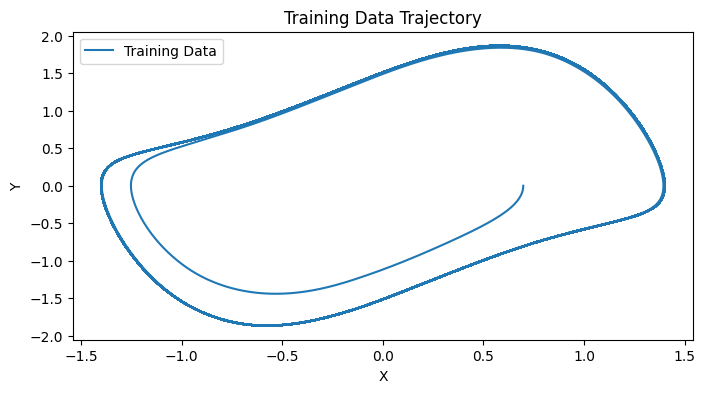

In [5]:
X_train_np = X_train.cpu().numpy()

plt.figure(figsize=(8, 4))
for i in range(X_train_np.shape[1]):
    plt.plot(X_train_np[:20000, i] + i*10, label=f'Training Data - Dim {i+1}')
    plt.title(f'Training Data')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(X_train_np[:, 0], X_train_np[:, 1], label='Training Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Training Data Trajectory')
plt.legend()
plt.show()

# ML-SNN Model

In [6]:
@torch.jit.script
def compute_output(s_e: torch.Tensor, s_i: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    cat = torch.cat([s_e, s_i], 1)
    return F.linear(cat, weight, bias)

@torch.jit.script
def compute_derivatives(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    m_inf_e = 0.5 * (1 + torch.tanh((V_e - V1) / V2))
    n_inf_e = 0.5 * (1 + torch.tanh((V_e - V3) / V4))
    # tau_n_e = 1.0 / torch.cosh((V_e - V3) / (2 * V4))
    tau_n_e = 1.0
    TM_e = T_max / (1 + torch.exp(-(V_e - V_t) / K_p))
    
    m_inf_i = 0.5 * (1 + torch.tanh((V_i - V1) / V2))
    n_inf_i = 0.5 * (1 + torch.tanh((V_i - V3) / V4))
    # tau_n_i = 1.0 / torch.cosh((V_i - V3) / (2 * V4))
    tau_n_i = 1.0
    TM_i = T_max / (1 + torch.exp(-(V_i - V_t) / K_p))
    
    I_syn_e = (gbar_e * torch.mm(s_e, omega_ee.transpose(0,1)) * (V_e - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ei.transpose(0,1)) * (V_e - E_gaba))
    I_syn_i = (gbar_e * torch.mm(s_e, omega_ie.transpose(0,1)) * (V_i - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ii.transpose(0,1)) * (V_i - E_gaba))
    
    dV_e = (I_e - g_L*(V_e - V_L) - g_K*n_e*(V_e - V_K) - g_Ca*m_inf_e*(V_e - V_Ca) - I_syn_e) / Cm
    dn_e = phi*(n_inf_e - n_e) / tau_n_e
    ds_e = ar_e * TM_e * (1.0 - s_e) - ad_e * s_e
    
    dV_i = (I_i - g_L*(V_i - V_L) - g_K*n_i*(V_i - V_K) - g_Ca*m_inf_i*(V_i - V_Ca) - I_syn_i) / Cm
    dn_i = phi*(n_inf_i - n_i) / tau_n_i
    ds_i = ar_i * TM_i * (1.0 - s_i) - ad_i * s_i
    
    return dV_e, dn_e, ds_e, dV_i, dn_i, ds_i

@torch.jit.script
def rk4_step(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor, dt: float,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    k1 = compute_derivatives(V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k2 = V_e + 0.5 * dt * k1[0]
    n_e_k2 = n_e + 0.5 * dt * k1[1]
    s_e_k2 = s_e + 0.5 * dt * k1[2]
    V_i_k2 = V_i + 0.5 * dt * k1[3]
    n_i_k2 = n_i + 0.5 * dt * k1[4]
    s_i_k2 = s_i + 0.5 * dt * k1[5]
    k2 = compute_derivatives(V_e_k2, n_e_k2, s_e_k2, V_i_k2, n_i_k2, s_i_k2, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k3 = V_e + 0.5 * dt * k2[0]
    n_e_k3 = n_e + 0.5 * dt * k2[1]
    s_e_k3 = s_e + 0.5 * dt * k2[2]
    V_i_k3 = V_i + 0.5 * dt * k2[3]
    n_i_k3 = n_i + 0.5 * dt * k2[4]
    s_i_k3 = s_i + 0.5 * dt * k2[5]
    k3 = compute_derivatives(V_e_k3, n_e_k3, s_e_k3, V_i_k3, n_i_k3, s_i_k3, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k4 = V_e + dt * k3[0]
    n_e_k4 = n_e + dt * k3[1]
    s_e_k4 = s_e + dt * k3[2]
    V_i_k4 = V_i + dt * k3[3]
    n_i_k4 = n_i + dt * k3[4]
    s_i_k4 = s_i + dt * k3[5]
    k4 = compute_derivatives(V_e_k4, n_e_k4, s_e_k4, V_i_k4, n_i_k4, s_i_k4, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_new = V_e + (dt/6.0) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    n_e_new = n_e + (dt/6.0) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    s_e_new = s_e + (dt/6.0) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    
    V_i_new = V_i + (dt/6.0) * (k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    n_i_new = n_i + (dt/6.0) * (k1[4] + 2*k2[4] + 2*k3[4] + k4[4])
    s_i_new = s_i + (dt/6.0) * (k1[5] + 2*k2[5] + 2*k3[5] + k4[5])
    
    return V_e_new, n_e_new, s_e_new, V_i_new, n_i_new, s_i_new


@torch.jit.script
def integrate_chunk_with_output(
    input: torch.Tensor, 
    chunk_size: int,
    init_V_e: torch.Tensor, init_n_e: torch.Tensor, init_s_e: torch.Tensor,
    init_V_i: torch.Tensor, init_n_i: torch.Tensor, init_s_i: torch.Tensor,
    dt: float, I: float,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float,
    proj_weight: torch.Tensor, proj_bias: torch.Tensor,
    out_weight: torch.Tensor, out_bias: torch.Tensor
) -> Tuple[torch.Tensor,
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor], 
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:
    steps = chunk_size
    
    V_e, n_e, s_e = init_V_e, init_n_e, init_s_e
    V_i, n_i, s_i = init_V_i, init_n_i, init_s_i

    outputs = []
    
    V_e_list = torch.jit.annotate(List[torch.Tensor], [])
    n_e_list = torch.jit.annotate(List[torch.Tensor], [])
    s_e_list = torch.jit.annotate(List[torch.Tensor], [])
    V_i_list = torch.jit.annotate(List[torch.Tensor], [])
    n_i_list = torch.jit.annotate(List[torch.Tensor], [])
    s_i_list = torch.jit.annotate(List[torch.Tensor], [])

    projected_input = F.linear(input * 40, proj_weight, proj_bias) + I
    
    # Split into excitatory and inhibitory drive:
    NE = V_e.size(1)
    I_e = projected_input[:, :NE]
    I_i = projected_input[:, NE:]
    
    for t in range(steps):  
        # Perform one RK4 step with current input:
        V_e, n_e, s_e, V_i, n_i, s_i = rk4_step(
            V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i, dt,
            omega_ee, omega_ei, omega_ie, omega_ii,
            V1, V2, V3, V4, T_max, V_t, K_p,
            g_Ca, V_Ca, g_K, V_K, g_L, V_L,
            phi, ar_e, ad_e, ar_i, ad_i,
            gbar_e, gbar_i, E_ampa, E_gaba, Cm)
        
        out = compute_output(s_e, s_i, out_weight, out_bias)
        outputs.append(out)
        
        V_e_list.append(V_e[0].clone())
        n_e_list.append(n_e[0].clone())
        s_e_list.append(s_e[0].clone())
        V_i_list.append(V_i[0].clone())
        n_i_list.append(n_i[0].clone())
        s_i_list.append(s_i[0].clone())

    outputs_tensor = torch.stack(outputs, dim=0)
    final_states = (V_e, n_e, s_e, V_i, n_i, s_i)
    all_states = (torch.stack(V_e_list, dim=0),
                  torch.stack(n_e_list, dim=0),
                  torch.stack(s_e_list, dim=0),
                  torch.stack(V_i_list, dim=0),
                  torch.stack(n_i_list, dim=0),
                  torch.stack(s_i_list, dim=0))
    
    return outputs_tensor, final_states, all_states

# --------------------------------------------------------------------
# Morris-Lecar SNN Model
# --------------------------------------------------------------------
class MorrisLecarSNN(nn.Module):
    def __init__(self, input_size, output_size, chunk_size, NE=250, NI=250, dt=0.1,
                 Cm=20.0, g_Ca=4.0, g_K=8.0, g_L=2.0, V_Ca=120.0, V_K=-84.0, V_L=-60.0,
                 phi=0.067, V1=-1.2, V2=18.0, V3=12.0, V4=17.4, ar_e=3.0, ad_e=0.1,
                 ar_i=3.0, ad_i=0.1, T_max=1.0, V_t=2.0, K_p=5.0, gbar_e=1.0, gbar_i=1.0,
                 E_ampa=0.0, E_gaba=-75.0, I= 70.0):
        super(MorrisLecarSNN, self).__init__()
        self.NE = NE
        self.NI = NI
        self.dt = dt
        self.hidden_size = NE + NI
        self.chunk_size = chunk_size

        # Model parameters
        self.I = I
        self.Cm = Cm
        self.g_Ca = g_Ca
        self.g_K = g_K
        self.g_L = g_L
        self.V_Ca = V_Ca
        self.V_K = V_K
        self.V_L = V_L
        self.phi = phi
        self.V1 = V1
        self.V2 = V2
        self.V3 = V3
        self.V4 = V4
        self.ar_e = ar_e
        self.ad_e = ad_e
        self.ar_i = ar_i
        self.ad_i = ad_i
        self.T_max = T_max
        self.V_t = V_t
        self.K_p = K_p
        self.gbar_e = gbar_e
        self.gbar_i = gbar_i
        self.E_ampa = E_ampa
        self.E_gaba = E_gaba

        self.previous_output = None
        self.current_input = None

        # Input layer
        self.input_projection = nn.Linear(input_size, self.hidden_size)
        
        # Synaptic weights
        self.omega_ee_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ei_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ie_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ii_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        
        # Upper bound
        self.upper_bound = 1 / math.sqrt(self.hidden_size)

        # Output layer
        self.output_layer = nn.Linear(self.hidden_size, output_size)

        # State storage (if needed)
        self.store_states = False
        self._storage = None
        self._storage_idx = 0
    
    # Property to get bounded omega matrices
    @property
    def omega_ee(self):
        return torch.sigmoid(self.omega_ee_raw) * self.upper_bound
    
    @property
    def omega_ei(self):
        return torch.sigmoid(self.omega_ei_raw) * self.upper_bound
    
    @property
    def omega_ie(self):
        return torch.sigmoid(self.omega_ie_raw) * self.upper_bound
    
    @property
    def omega_ii(self):
        return torch.sigmoid(self.omega_ii_raw) * self.upper_bound
    
    def _init_storage(self, total_steps: int):
        device = self.input_projection.weight.device
        self._storage = {
            'V_e': torch.zeros(total_steps, self.NE, device=device),
            'n_e': torch.zeros(total_steps, self.NE, device=device),
            's_e': torch.zeros(total_steps, self.NE, device=device),
            'V_i': torch.zeros(total_steps, self.NI, device=device),
            'n_i': torch.zeros(total_steps, self.NI, device=device),
            's_i': torch.zeros(total_steps, self.NI, device=device)
        }
        self._storage_idx = 0

    def enable_storage(self, total_steps: int):
        self.store_states = True
        self._init_storage(total_steps)

    def disable_storage(self):
        self.store_states = False
        self._storage = None
        self._storage_idx = 0

    def get_storage(self):
        return self._storage

    def _init_states(self):
        device = self.input_projection.weight.device
        V_e = 30 * torch.rand((1, self.NE), device=device)
        n_e = torch.rand((1, self.NE), device=device)
        s_e = torch.zeros((1, self.NE), device=device)
        V_i = -50 + 30 * torch.rand((1, self.NI), device=device)
        n_i = torch.rand((1, self.NI), device=device)
        s_i = torch.zeros((1, self.NI), device=device)
        return (V_e, n_e, s_e, V_i, n_i, s_i)

    def forward(self, input, states=None, teacher_forcing_alpha=None):
        outputs_list = []

        if states is None:
            states = self._init_states()
            
        # Generalized teacher forcing
        if self.current_input == None:
            self.current_input = input
        else:
            self.current_input = (1 - teacher_forcing_alpha) * self.previous_output + teacher_forcing_alpha * input
        
        # We need to get the projection and output layer parameters.
        proj_weight = self.input_projection.weight
        proj_bias = self.input_projection.bias
        out_weight = self.output_layer.weight
        out_bias = self.output_layer.bias

        # Call the scripted integration function that returns outputs for each step in the chunk.
        chunk_outputs, states, all_states = integrate_chunk_with_output(
            self.current_input, self.chunk_size, states[0], states[1], states[2],
            states[3], states[4], states[5],
            self.dt, self.I,
            self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
            self.V1, self.V2, self.V3, self.V4,
            self.T_max, self.V_t, self.K_p,
            self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
            self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
            self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
            self.Cm,
            proj_weight, proj_bias,
            out_weight, out_bias
        )
       
        self.previous_output = chunk_outputs[-1].detach()
        chunk_outputs = chunk_outputs.transpose(0, 1)
        outputs_list.append(chunk_outputs)
        
        if self.store_states:
            steps = self.chunk_size
            with torch.no_grad():
                self._storage['V_e'][self._storage_idx:self._storage_idx + steps] = all_states[0]
                self._storage['n_e'][self._storage_idx:self._storage_idx + steps] = all_states[1]
                self._storage['s_e'][self._storage_idx:self._storage_idx + steps] = all_states[2]
                self._storage['V_i'][self._storage_idx:self._storage_idx + steps] = all_states[3]
                self._storage['n_i'][self._storage_idx:self._storage_idx + steps] = all_states[4]
                self._storage['s_i'][self._storage_idx:self._storage_idx + steps] = all_states[5]
                self._storage_idx += steps
        
        outputs = torch.cat(outputs_list, dim=1)
        return outputs, states

    def test(self, input, test_lenght, states=None):
        batch_size, _ = input.shape
        outputs_list = []

        if states is None:
            states = self._init_states()

        test_input = input
      
        # We need to get the projection and output layer parameters.
        proj_weight = self.input_projection.weight
        proj_bias = self.input_projection.bias
        out_weight = self.output_layer.weight
        out_bias = self.output_layer.bias

        for start in range(0, test_lenght - self.chunk_size + 1 , self.chunk_size):
            chunk_outputs, states, all_states = integrate_chunk_with_output(
                test_input, self.chunk_size, states[0], states[1], states[2],
                states[3], states[4], states[5],
                self.dt, self.I,
                self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
                self.V1, self.V2, self.V3, self.V4,
                self.T_max, self.V_t, self.K_p,
                self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
                self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
                self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
                self.Cm,
                proj_weight, proj_bias,
                out_weight, out_bias
            )
            test_input = chunk_outputs[-1,:,:]
            chunk_outputs = chunk_outputs.transpose(0, 1)

            outputs_list.append(chunk_outputs)
            if self.store_states:
                steps = self.chunk_size
                with torch.no_grad():
                    self._storage['V_e'][self._storage_idx:self._storage_idx + steps] = all_states[0]
                    self._storage['n_e'][self._storage_idx:self._storage_idx + steps] = all_states[1]
                    self._storage['s_e'][self._storage_idx:self._storage_idx + steps] = all_states[2]
                    self._storage['V_i'][self._storage_idx:self._storage_idx + steps] = all_states[3]
                    self._storage['n_i'][self._storage_idx:self._storage_idx + steps] = all_states[4]
                    self._storage['s_i'][self._storage_idx:self._storage_idx + steps] = all_states[5]
                    self._storage_idx += steps
        outputs = torch.cat(outputs_list, dim=1) 
        return outputs

    def warmup(self, input, warmup_duration, states=None):
        with torch.no_grad():
            outputs_list = []
    
            if states is None:
                states = self._init_states()

            proj_weight = self.input_projection.weight
            proj_bias = self.input_projection.bias
            out_weight = self.output_layer.weight
            out_bias = self.output_layer.bias

            chunk_outputs, states, _ = integrate_chunk_with_output(
                input, warmup_duration, states[0], states[1], states[2],
                states[3], states[4], states[5],
                self.dt, self.I,
                self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
                self.V1, self.V2, self.V3, self.V4,
                self.T_max, self.V_t, self.K_p,
                self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
                self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
                self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
                self.Cm,
                proj_weight, proj_bias,
                out_weight, out_bias
            )
           
        return states, chunk_outputs[-1,:,:]


    def plot_full_state(self, num_neurons=5, neuron_offset=2.0, figure_name=""):
        if not self.store_states or self._storage is None:
            print("Storage not enabled or no data stored!")
            return
        
        store = {k: v.cpu().numpy() for k, v in self._storage.items()}
        time_steps = store['V_e'].shape[0]
        time = np.arange(0, time_steps) * self.dt

        fig = plt.figure(figsize=(18, 12))
        plt.suptitle("Neuronal State Dynamics (T=100s)", fontsize=16)
        gs = fig.add_gridspec(3, 2)
        axs = {
            'V_e': fig.add_subplot(gs[0, 0]),
            'V_i': fig.add_subplot(gs[0, 1]),
            'n_e': fig.add_subplot(gs[1, 0]),
            'n_i': fig.add_subplot(gs[1, 1]),
            's_e': fig.add_subplot(gs[2, 0]),
            's_i': fig.add_subplot(gs[2, 1])
        }

        rand_e = np.random.choice(self.NE, num_neurons, replace=False)
        rand_i = np.random.choice(self.NI, num_neurons, replace=False)

        for idx, n in enumerate(rand_e):
            offset = idx * neuron_offset
            axs['V_e'].plot(time, (store['V_e'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_e'].plot(time, store['n_e'][:, n] + offset)
            axs['s_e'].plot(time, store['s_e'][:, n] + offset)

        for idx, n in enumerate(rand_i):
            offset = idx * neuron_offset
            axs['V_i'].plot(time, (store['V_i'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_i'].plot(time, store['n_i'][:, n] + offset)
            axs['s_i'].plot(time, store['s_i'][:, n] + offset)

        titles = {
            'V_e': "Excitatory Membrane Potentials",
            'V_i': "Inhibitory Membrane Potentials",
            'n_e': "Excitatory Gating Variables",
            'n_i': "Inhibitory Gating Variables",
            's_e': "Excitatory Synaptic Variables",
            's_i': "Inhibitory Synaptic Variables"
        }
        for key, ax in axs.items():
            ax.set_title(titles[key])
            ax.set_xlabel("Time (s)")
            ax.grid(True, alpha=0.3)
            if key in ['V_e', 'V_i']:
                ax.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if figure_name:
            plt.savefig(figure_name, bbox_inches='tight')
        plt.show()

## Define the ML-SNN architecture and training parameters

In [7]:
np.random.seed(8)
torch.manual_seed(8)

def gtf_alpha_schedule(epoch, num_epochs, max_alpha=1.0, min_alpha=0.5):
    return max_alpha - (max_alpha - min_alpha) * (epoch / num_epochs)

chunk_size = 100
states = None
NE = 250
NI = 250

model = MorrisLecarSNN(input_size=2, output_size=2, chunk_size=chunk_size, NE=NE, NI=NI).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)

criterion = nn.MSELoss()
signal_len = int(X_train.size(0)/epochs) 

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

initial_model_ckeckpoint = 'van-der-pol-initial.pth'
trained_model_checkpoint = 'van-der-pol-final.pth'

In [8]:
torch.save(model.state_dict(), initial_model_ckeckpoint)
print(f"Initial model state saved to {initial_model_ckeckpoint}")

Initial model state saved to van-der-pol-initial.pth


## Training loop

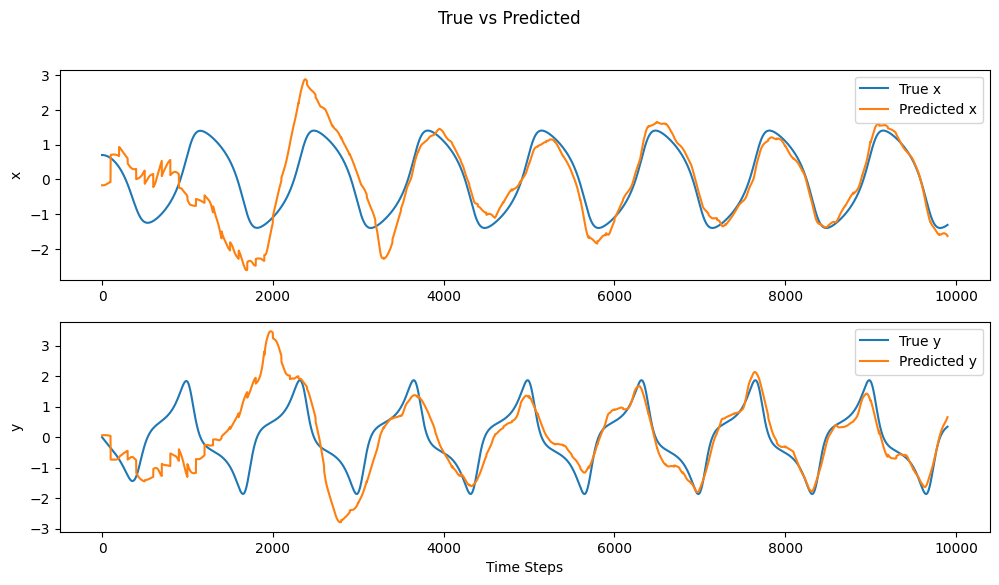

Epoch [1/20], Loss: 0.7013044017639504, tf: 1.0


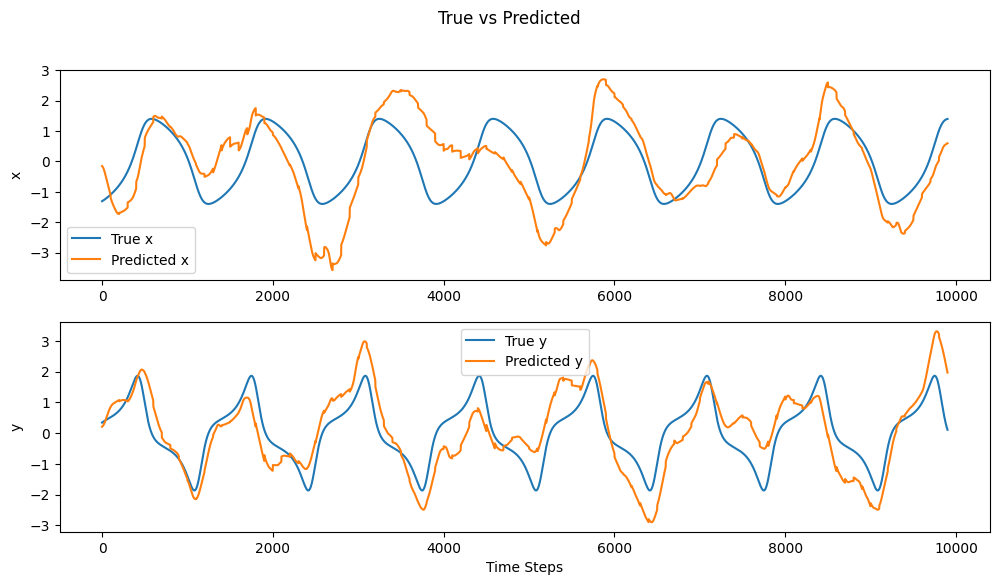

Epoch [2/20], Loss: 0.825564524182866, tf: 0.975


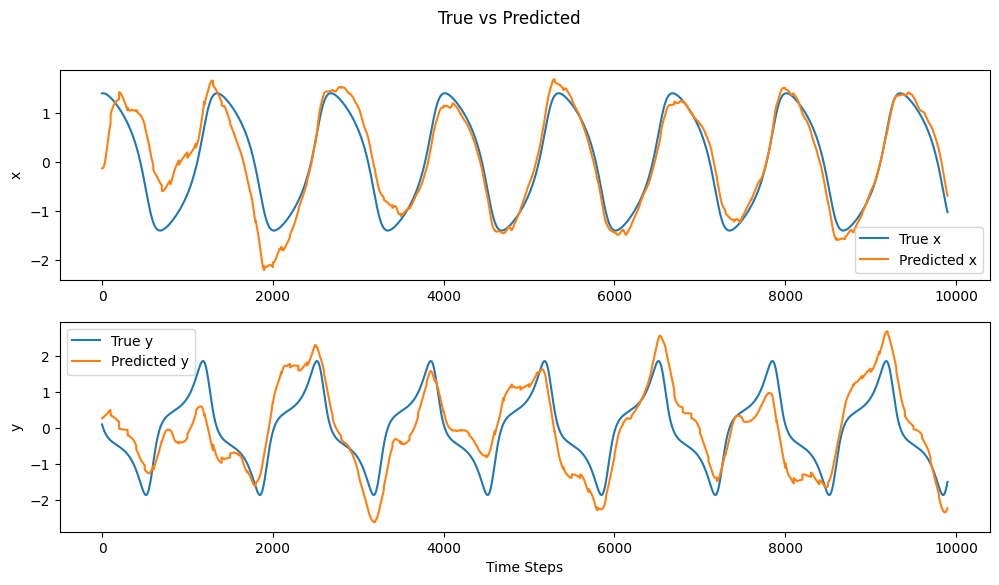

Epoch [3/20], Loss: 0.3227495721601235, tf: 0.95


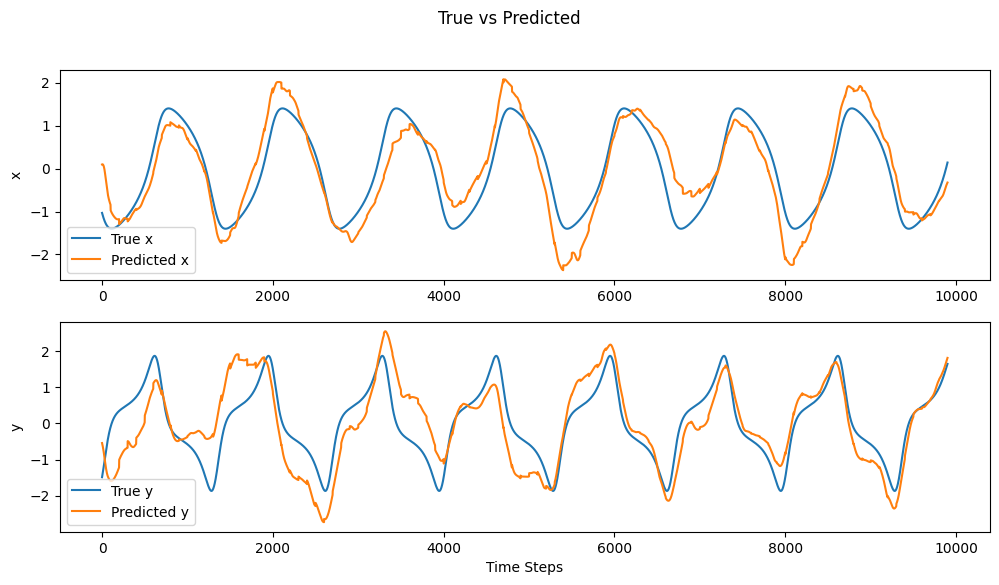

Epoch [4/20], Loss: 0.381476067533583, tf: 0.925


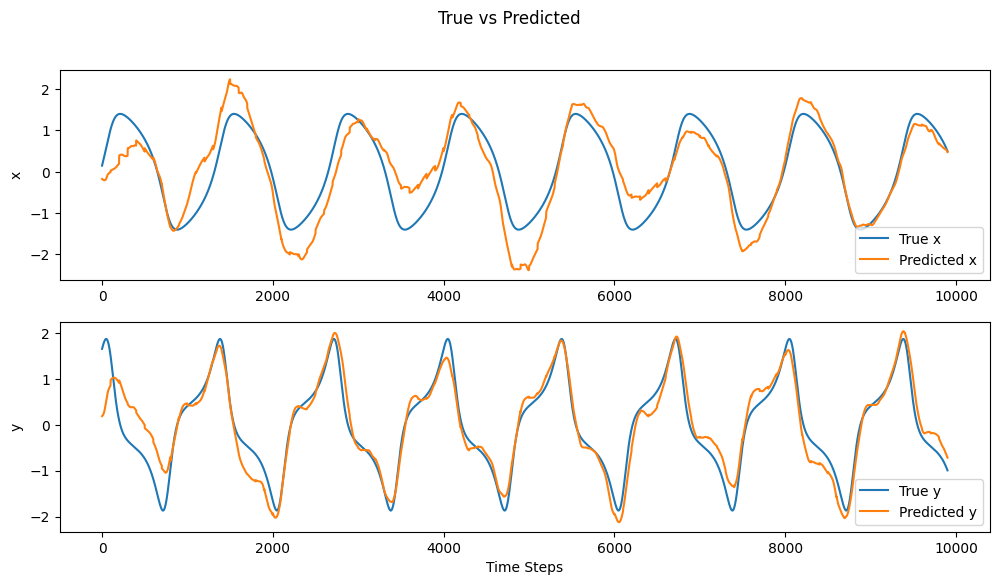

Epoch [5/20], Loss: 0.19282453508167627, tf: 0.9


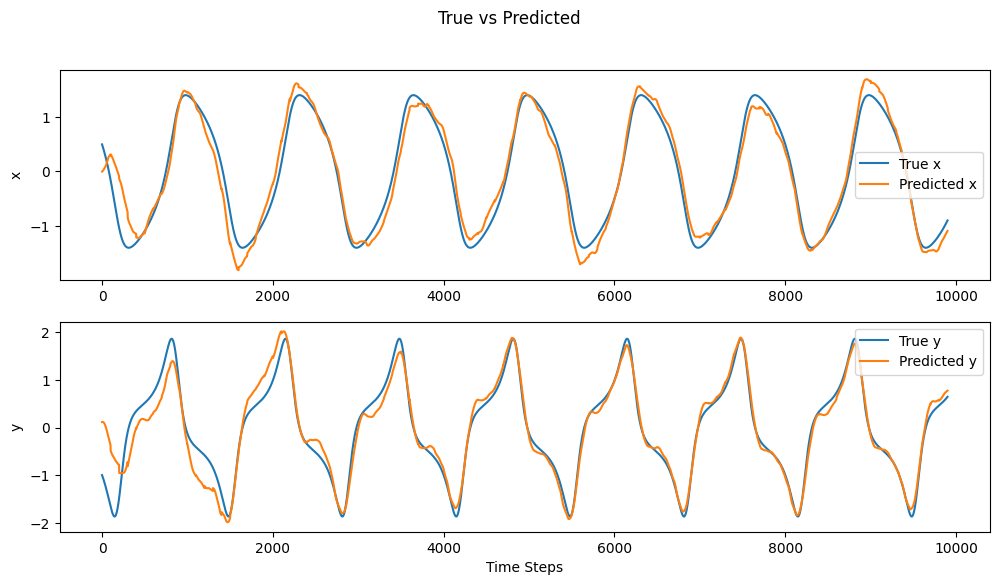

Epoch [6/20], Loss: 0.06235462598454575, tf: 0.875


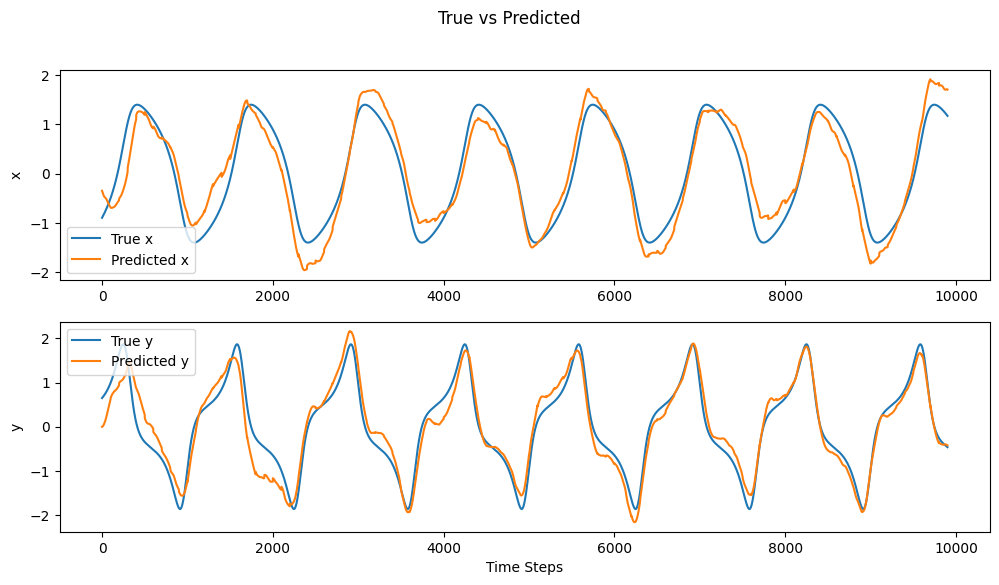

Epoch [7/20], Loss: 0.10821625114091546, tf: 0.85


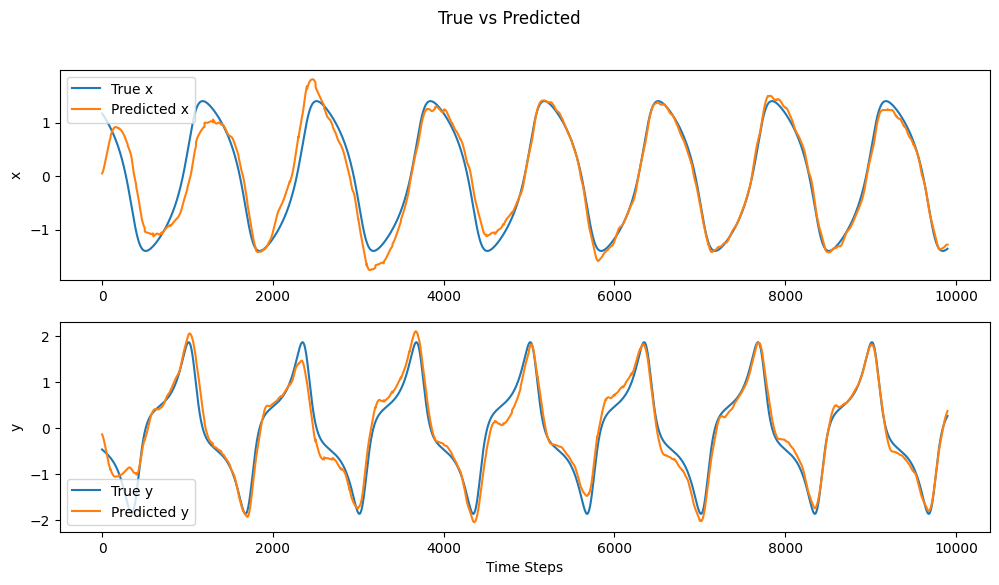

Epoch [8/20], Loss: 0.05577901464639486, tf: 0.825


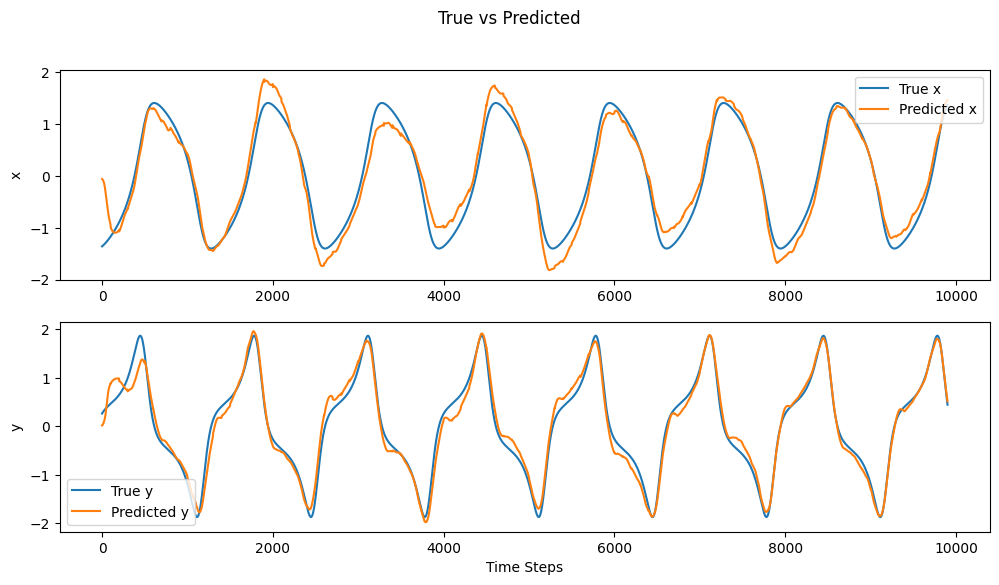

Epoch [9/20], Loss: 0.04438795497675802, tf: 0.8


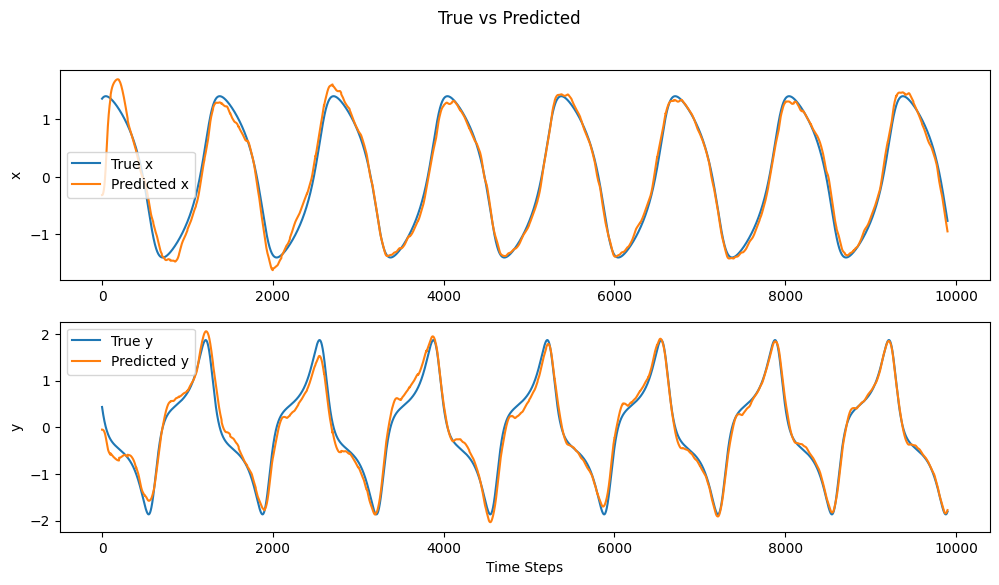

Epoch [10/20], Loss: 0.02433601636077241, tf: 0.775


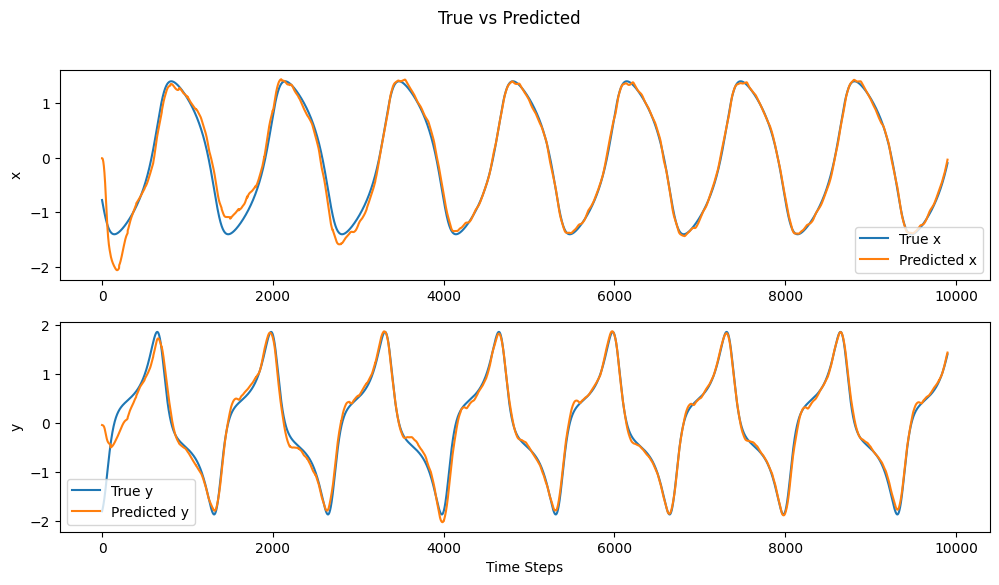

Epoch [11/20], Loss: 0.02021007870823614, tf: 0.75


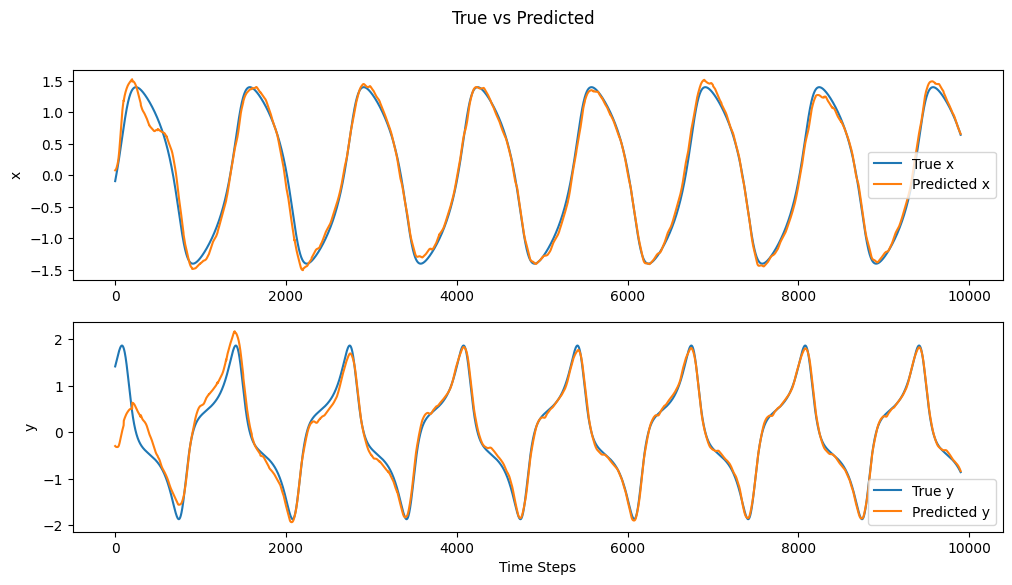

Epoch [12/20], Loss: 0.03593877110243876, tf: 0.725


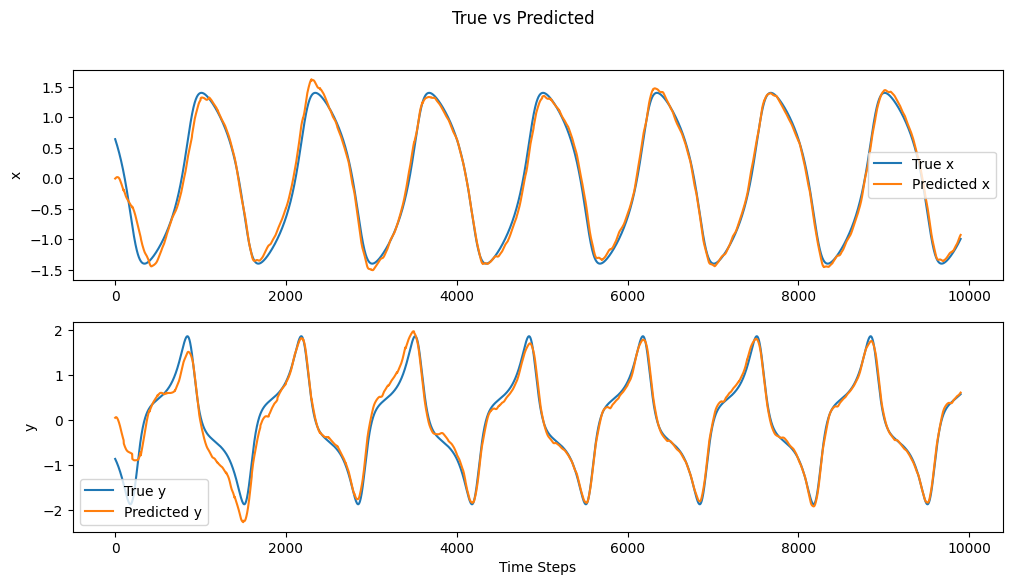

Epoch [13/20], Loss: 0.029977485829644247, tf: 0.7


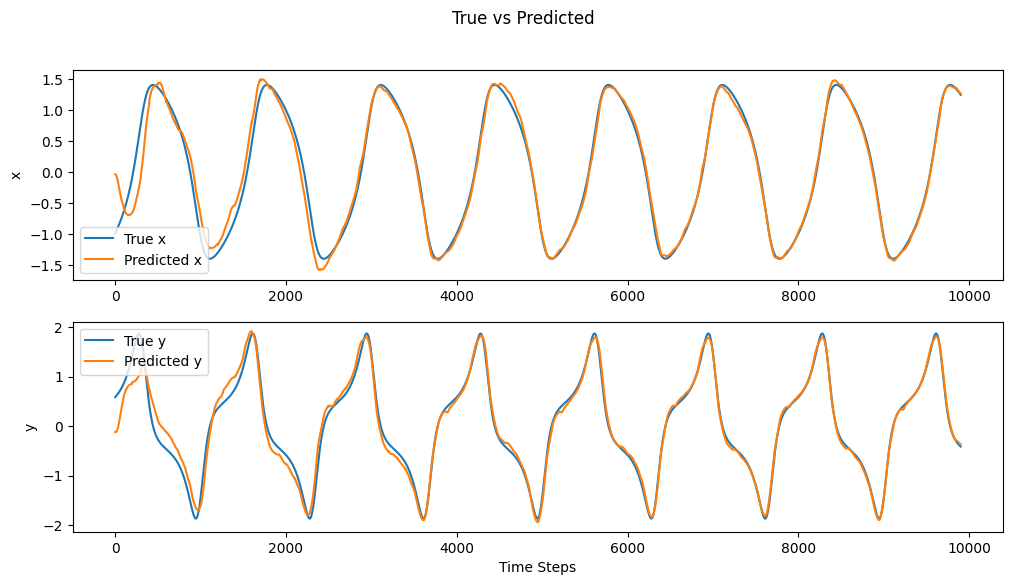

Epoch [14/20], Loss: 0.02646921638530273, tf: 0.675


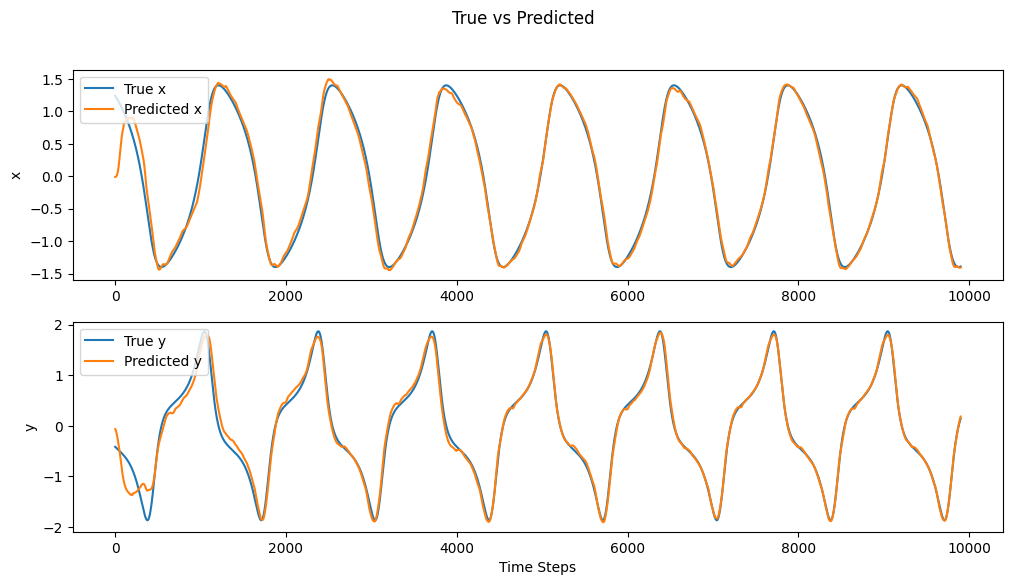

Epoch [15/20], Loss: 0.01562854692677058, tf: 0.65


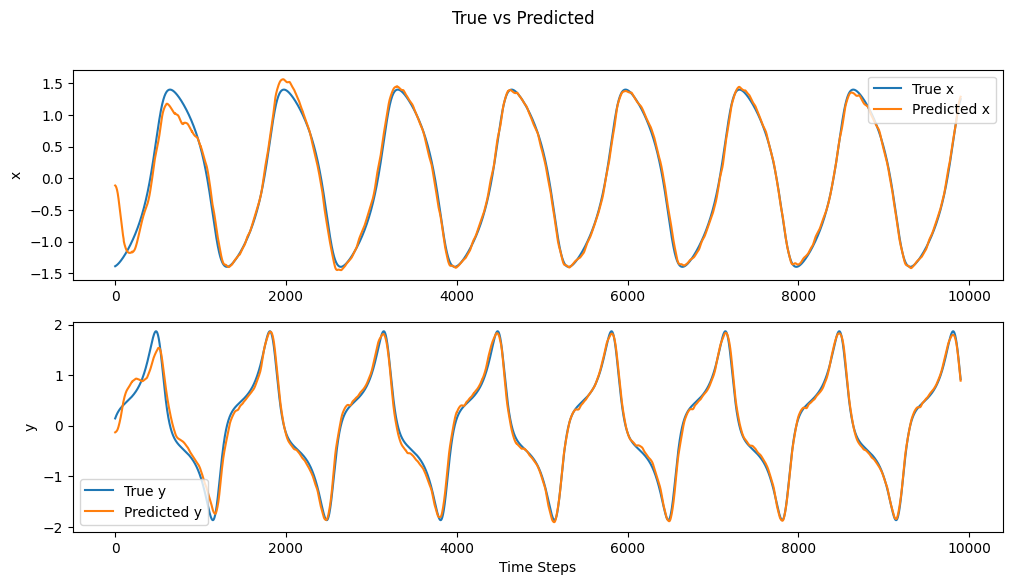

Epoch [16/20], Loss: 0.012574423848749055, tf: 0.625


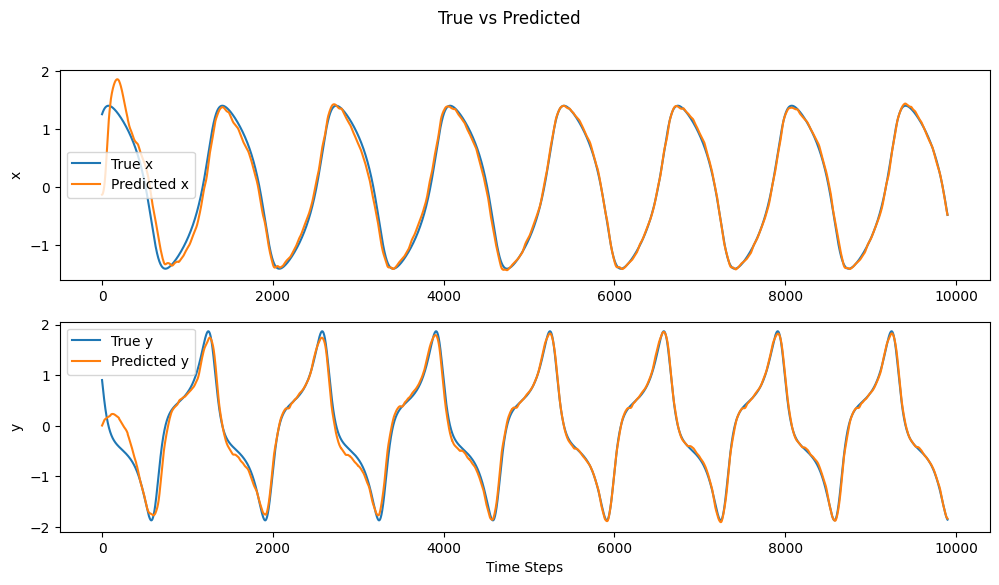

Epoch [17/20], Loss: 0.018242487796401446, tf: 0.6


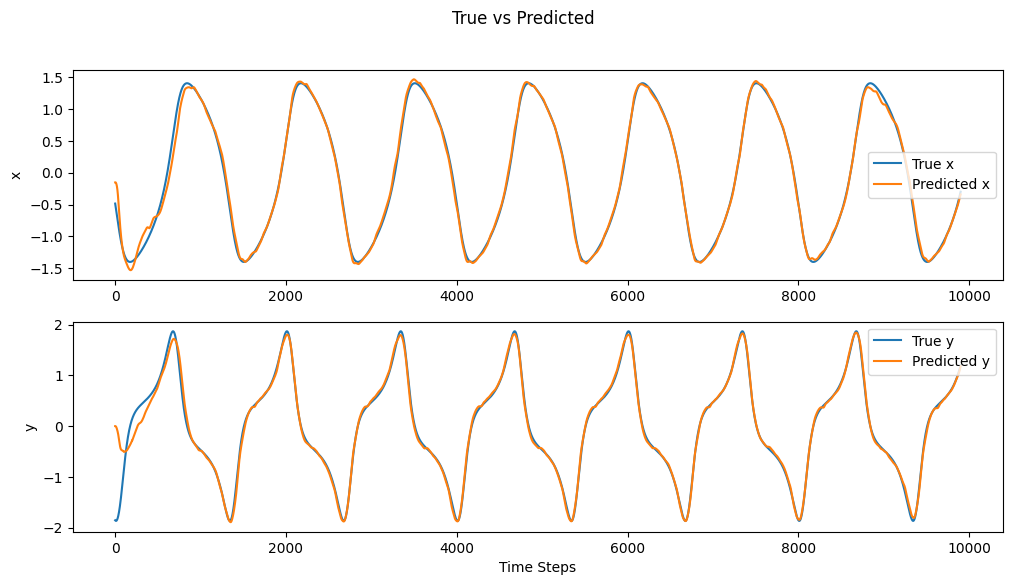

Epoch [18/20], Loss: 0.014198519416786072, tf: 0.575


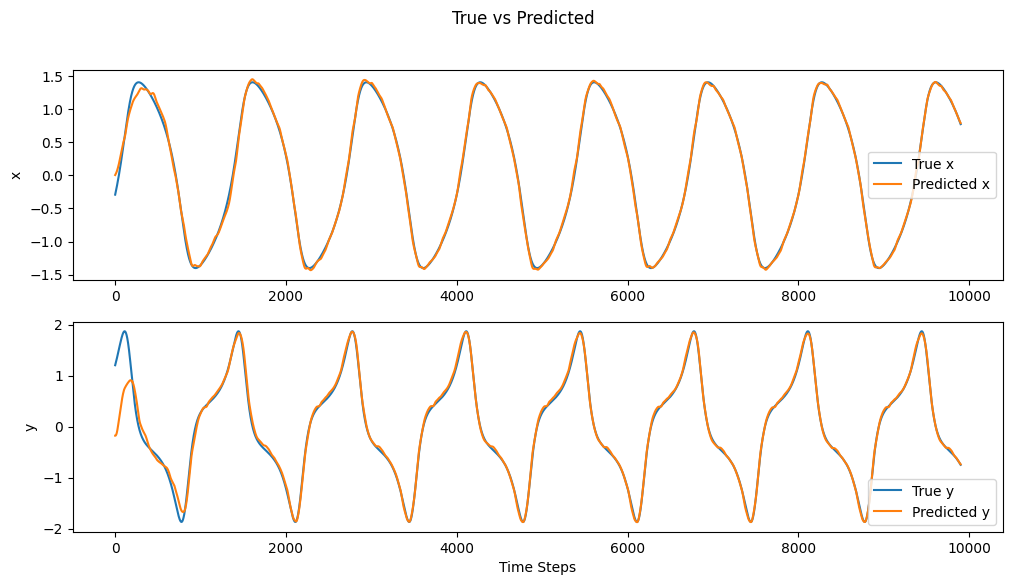

Epoch [19/20], Loss: 0.014525550049873315, tf: 0.55


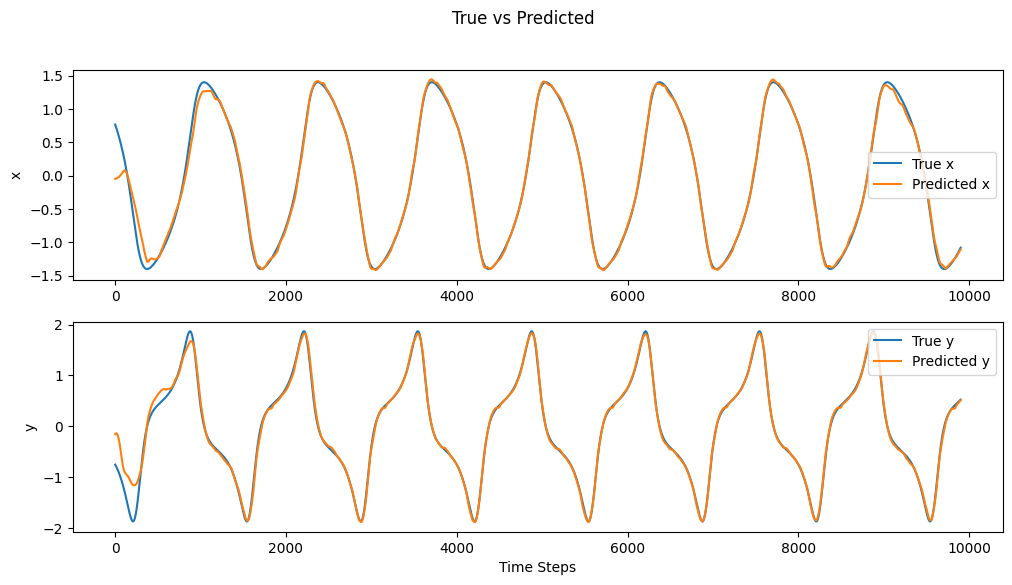

Epoch [20/20], Loss: 0.009290374699758902, tf: 0.525
Model and optimizer state saved successfully!
CPU times: user 6min 55s, sys: 4.36 s, total: 6min 59s
Wall time: 6min 55s


In [9]:
%%time

np.random.seed(8)
torch.manual_seed(8)

warmup_duration = 1000 #(100ms)

index = 0
for epoch in range(epochs):
    model.train()
    teacher_forcing_alpha = gtf_alpha_schedule(epoch, epochs)
    
    total_loss = 0
    states = None  # Reset recurrent states at the beginning of the batch
    epoch_outputs = []  # To accumulate outputs over time for predictions
    epoch_inputs = []
    model._storage_idx = 0  # Reset storage index for this batch
    with torch.no_grad():
        states, _ = model.warmup(torch.zeros(1, 2).to(device), warmup_duration, states)       

    for start in range(0, signal_len - chunk_size, chunk_size): 
        end = index + chunk_size

        x_chunk = X_train[index,:].unsqueeze(0).to(device) 
        y_chunk = X_train[index + 1:end + 1,:].unsqueeze(0).to(device)

        optimizer.zero_grad()
        
        outputs, states = model(x_chunk, states, teacher_forcing_alpha)
        
        epoch_outputs.append(outputs.squeeze().detach().cpu().numpy())
        epoch_inputs.append(y_chunk.squeeze().detach().cpu().numpy())

        loss = criterion(outputs, y_chunk)
        loss.backward()        
        optimizer.step()

        index = index + chunk_size

        if states is not None:
            states = tuple([state.detach() for state in states]) if isinstance(states, tuple) else states.detach()
            
        total_loss += loss.item()
    
    scheduler.step() # Update learning rate

    epoch_outputs = np.concatenate(epoch_outputs, axis=0)
    epoch_inputs = np.concatenate(epoch_inputs, axis=0)
    
    plot_output(epoch_inputs, epoch_outputs)
    avg_loss = (total_loss*100) / (signal_len - 1)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss}, tf: {teacher_forcing_alpha}")

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}

torch.save(checkpoint, trained_model_checkpoint)
print("Model and optimizer state saved successfully!")

In [10]:
checkpoint = torch.load(trained_model_checkpoint, map_location=device)

trained_model = MorrisLecarSNN(input_size=2, output_size=2, chunk_size=chunk_size, NE=NE, NI=NI).to(device)

trained_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

## Testing the model

In [11]:
def generate_trajectory(model, initial_state, states, generation_len):
    model.eval()
    model.enable_storage(generation_len)
    with torch.no_grad():        
        output = model.test(initial_state, generation_len, states)
        generated = np.vstack((initial_state.squeeze(0).cpu().numpy(),output.squeeze(0).cpu().numpy()))

    return np.array(generated).squeeze()

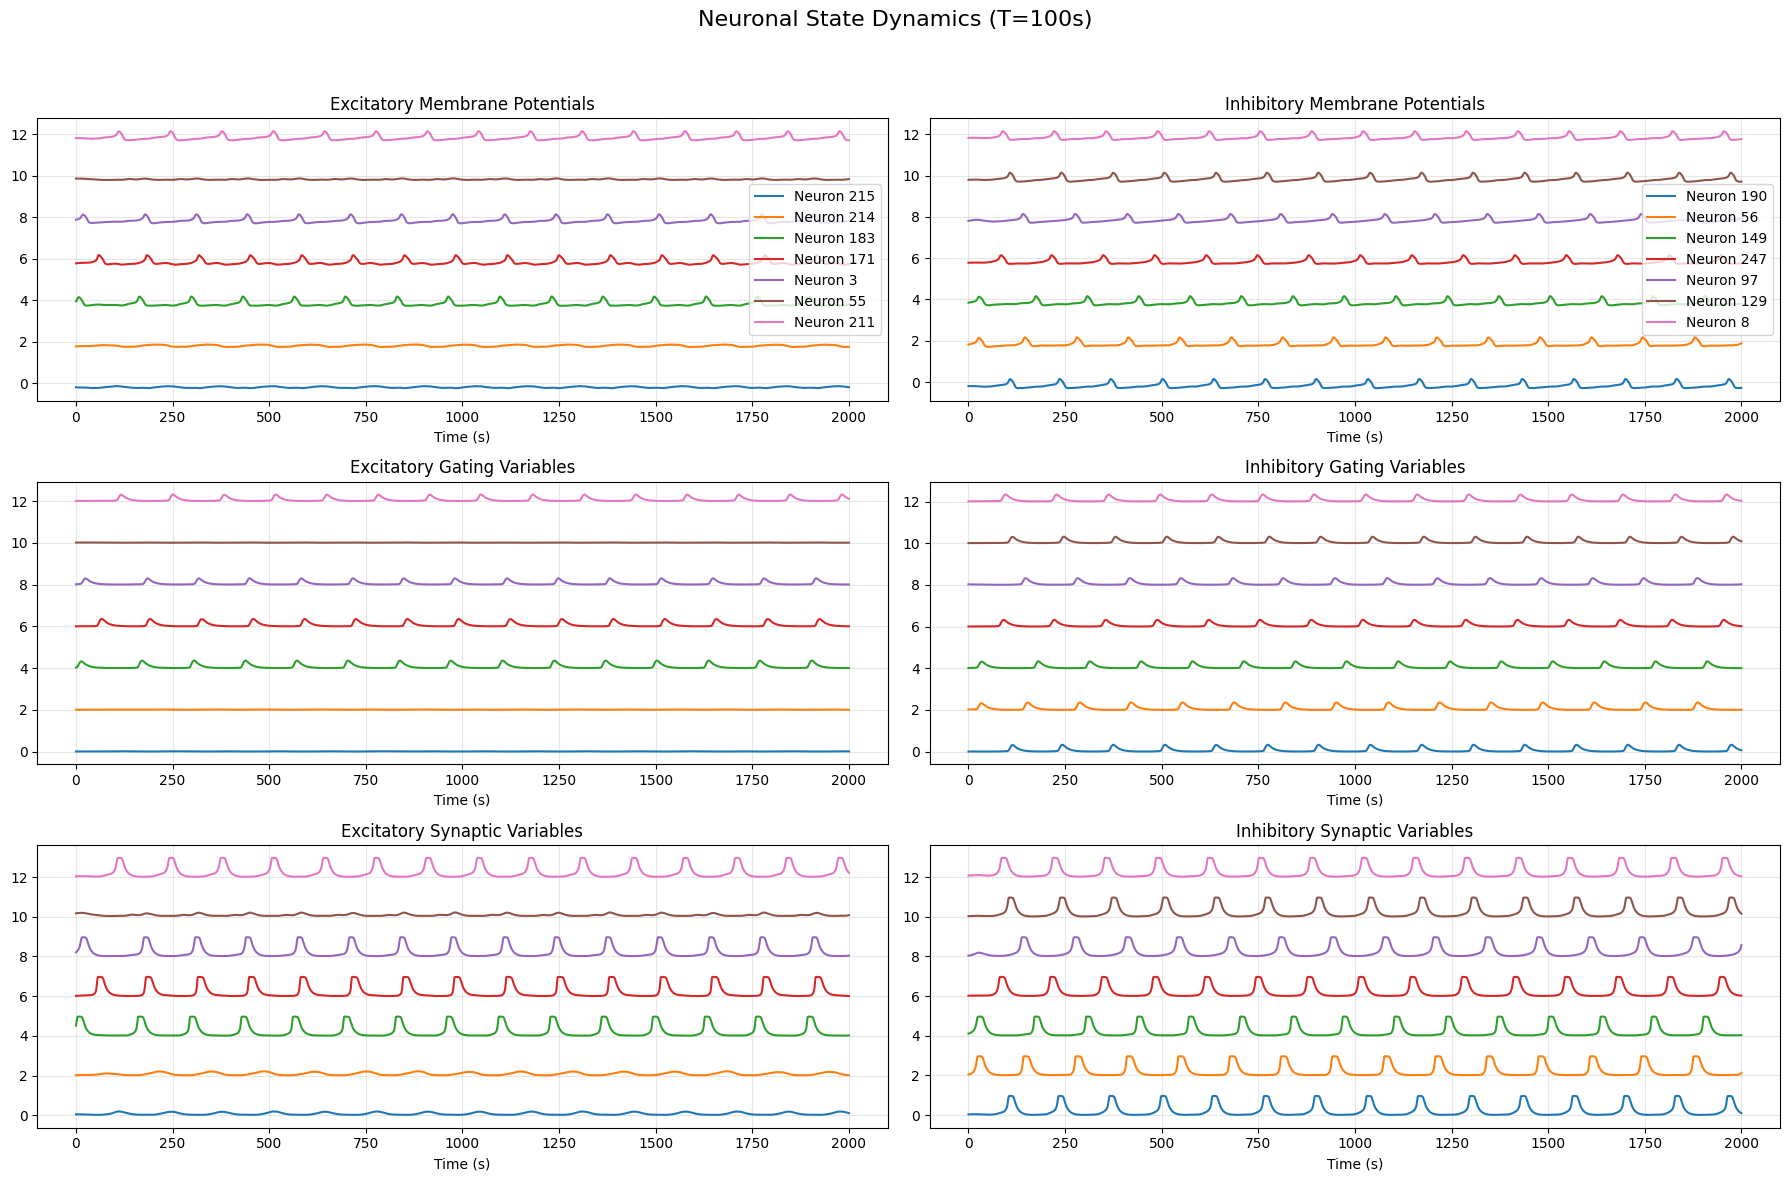

In [12]:
# Generate trajectory
np.random.seed(8)
torch.manual_seed(8)

initial_state = torch.tensor([1.0,0.0]).to(device)
states = None
states, initial_input = trained_model.warmup(initial_state.unsqueeze(0), warmup_duration, states)

generation_len = 20000
generated = generate_trajectory(trained_model, initial_input, states, generation_len)

trained_model.plot_full_state(num_neurons=7, figure_name="full_state_dynamics.png")
# trained_model.disable_storage()

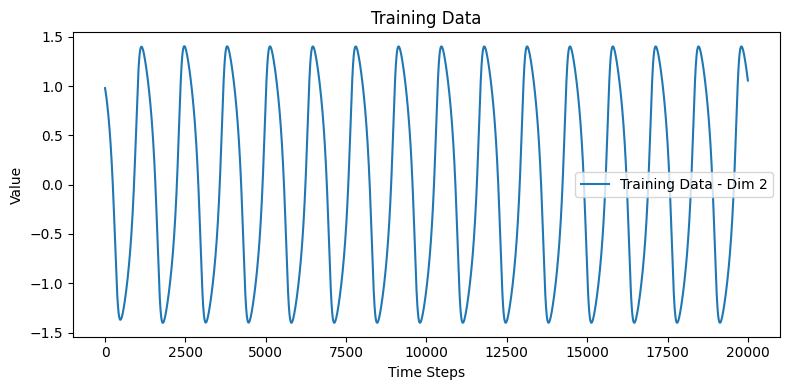

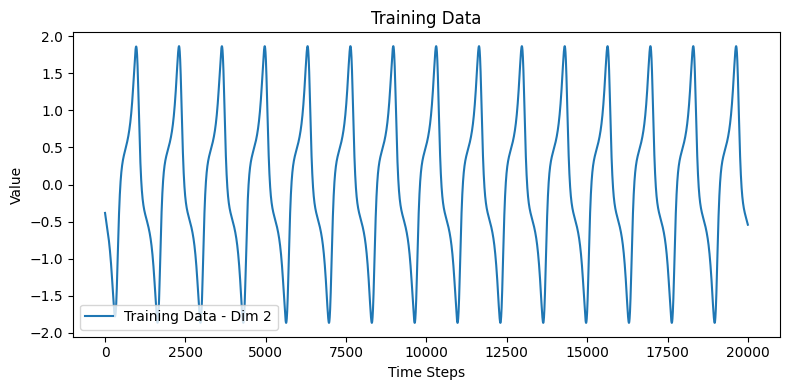

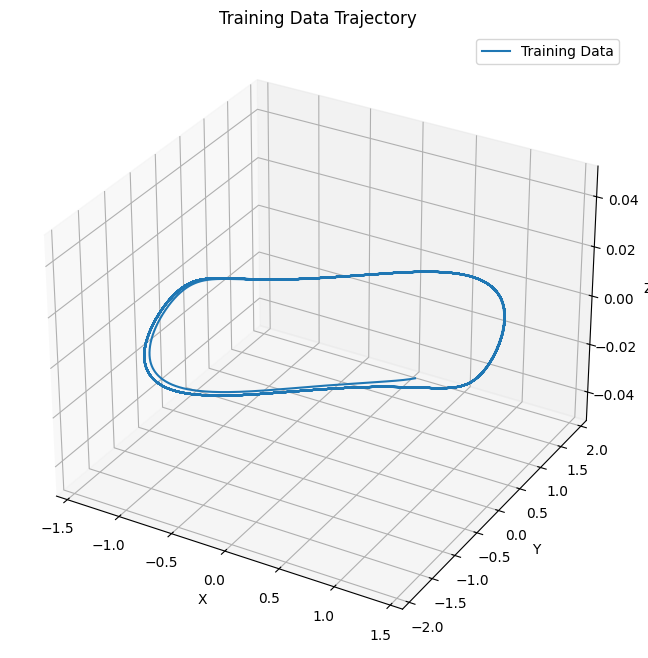

In [13]:
np.random.seed(8)
torch.manual_seed(8)

initial_state_denormalized = (initial_input.squeeze().cpu().numpy() * data_std) + data_mean

t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 20000)
solution = solve_ivp(van_der_pol, t_span, initial_state_denormalized, t_eval=t_eval)
test_data_unnormalized = solution.y.T

test_data_normalized = (test_data_unnormalized - data_mean) / data_std


plt.figure(figsize=(8, 4))
plt.plot(test_data_normalized[:, 0], label=f'Training Data - Dim {i+1}')
plt.title(f'Training Data')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(test_data_normalized[:, 1], label=f'Training Data - Dim {i+1}')
plt.title(f'Training Data')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(test_data_normalized[:, 0], test_data_normalized[:, 1], label='Training Data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Training Data Trajectory')
ax.legend()
plt.show()

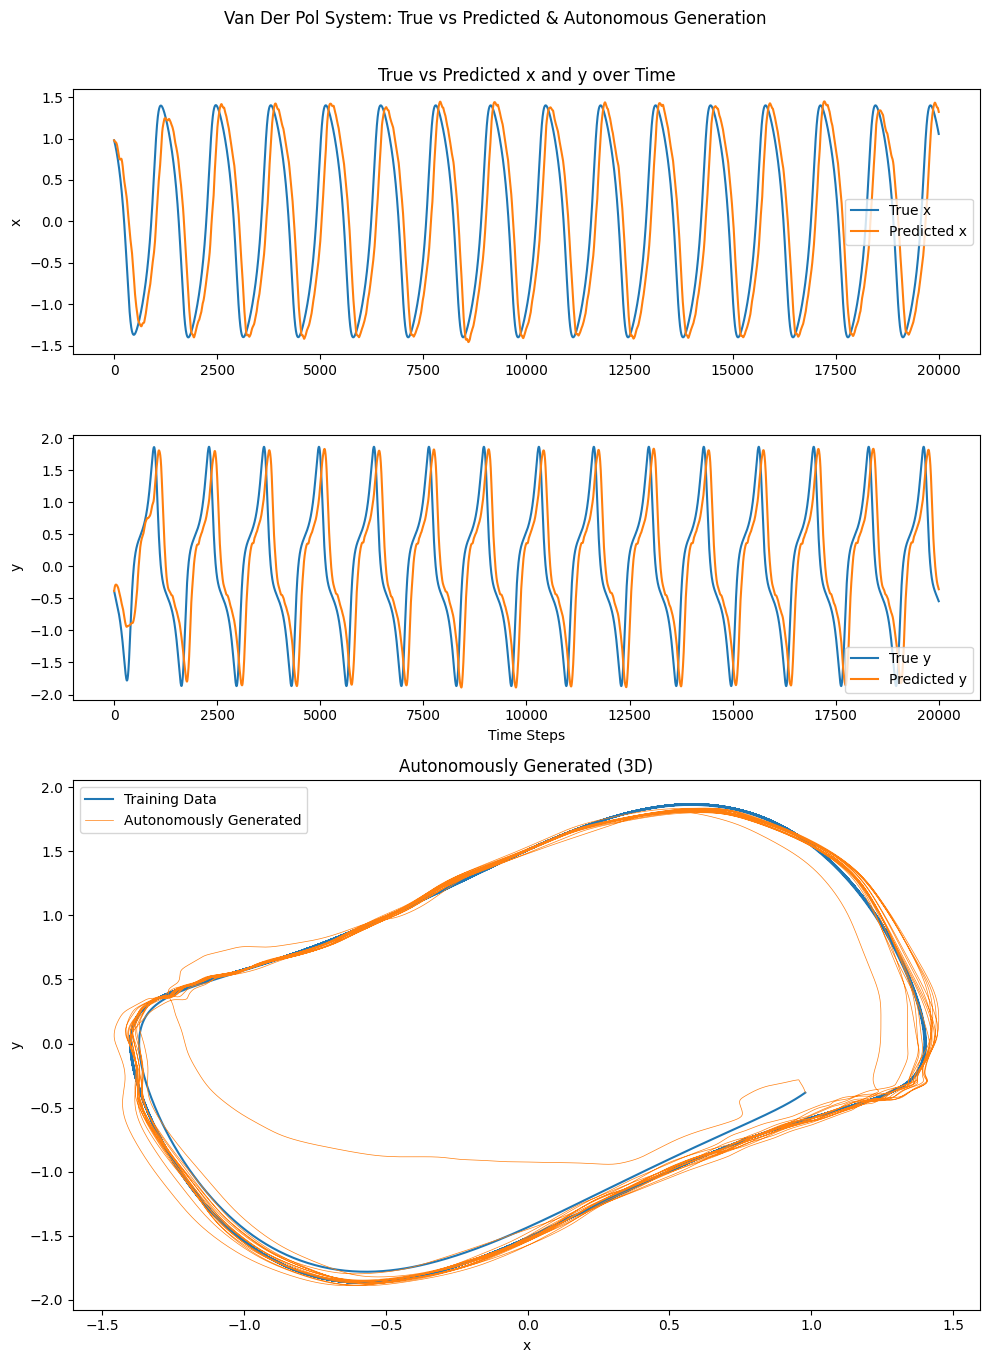

In [14]:
fig = plt.figure(figsize=(10, 14))
gs = plt.GridSpec(3, 1, height_ratios=[1, 1, 2]) 

# First subplot for 'x' time series
ax1 = fig.add_subplot(gs[0, 0]) 
ax1.plot(test_data_normalized[:, 0], label='True x')

if hasattr(generated, 'cpu'):
    ax1.plot(generated[:, 0].cpu().numpy(), label='Predicted x')
else:
     ax1.plot(generated[:, 0], label='Predicted x')

ax1.legend()
ax1.set_ylabel('x')
ax1.set_title('True vs Predicted x and y over Time') 

# Second subplot for 'y' time series
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(test_data_normalized[:, 1], label='True y')

if hasattr(generated, 'cpu'):
    ax2.plot(generated[:, 1].cpu().numpy(), label='Predicted y')
else:
    ax2.plot(generated[:, 1], label='Predicted y')

ax2.legend()
ax2.set_ylabel('y')
ax2.set_xlabel('Time Steps') 

ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(test_data_normalized[:, 0], test_data_normalized[:, 1], label='Training Data') 

if hasattr(generated, 'cpu'):
    ax3.plot(generated[:, 0].cpu().numpy(), generated[:, 1].cpu().numpy(), lw=0.5, label='Autonomously Generated') 
else:
    ax3.plot(generated[:, 0], generated[:, 1], lw=0.5, label='Autonomously Generated')

ax3.set_title('Autonomously Generated (3D)')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle('Van Der Pol System: True vs Predicted & Autonomous Generation', y=1.00)
plt.show()

## Draw Figures

In [15]:
%config InlineBackend.figure_format = 'retina'

config = {
    'figure.figsize': (8, 6),
    'figure.autolayout': True,
    'font.size': 15,
    'lines.linewidth': 3,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,     
    'ytick.labelsize': 16,        
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.fontsize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False
}

plt.rcParams.update(config)

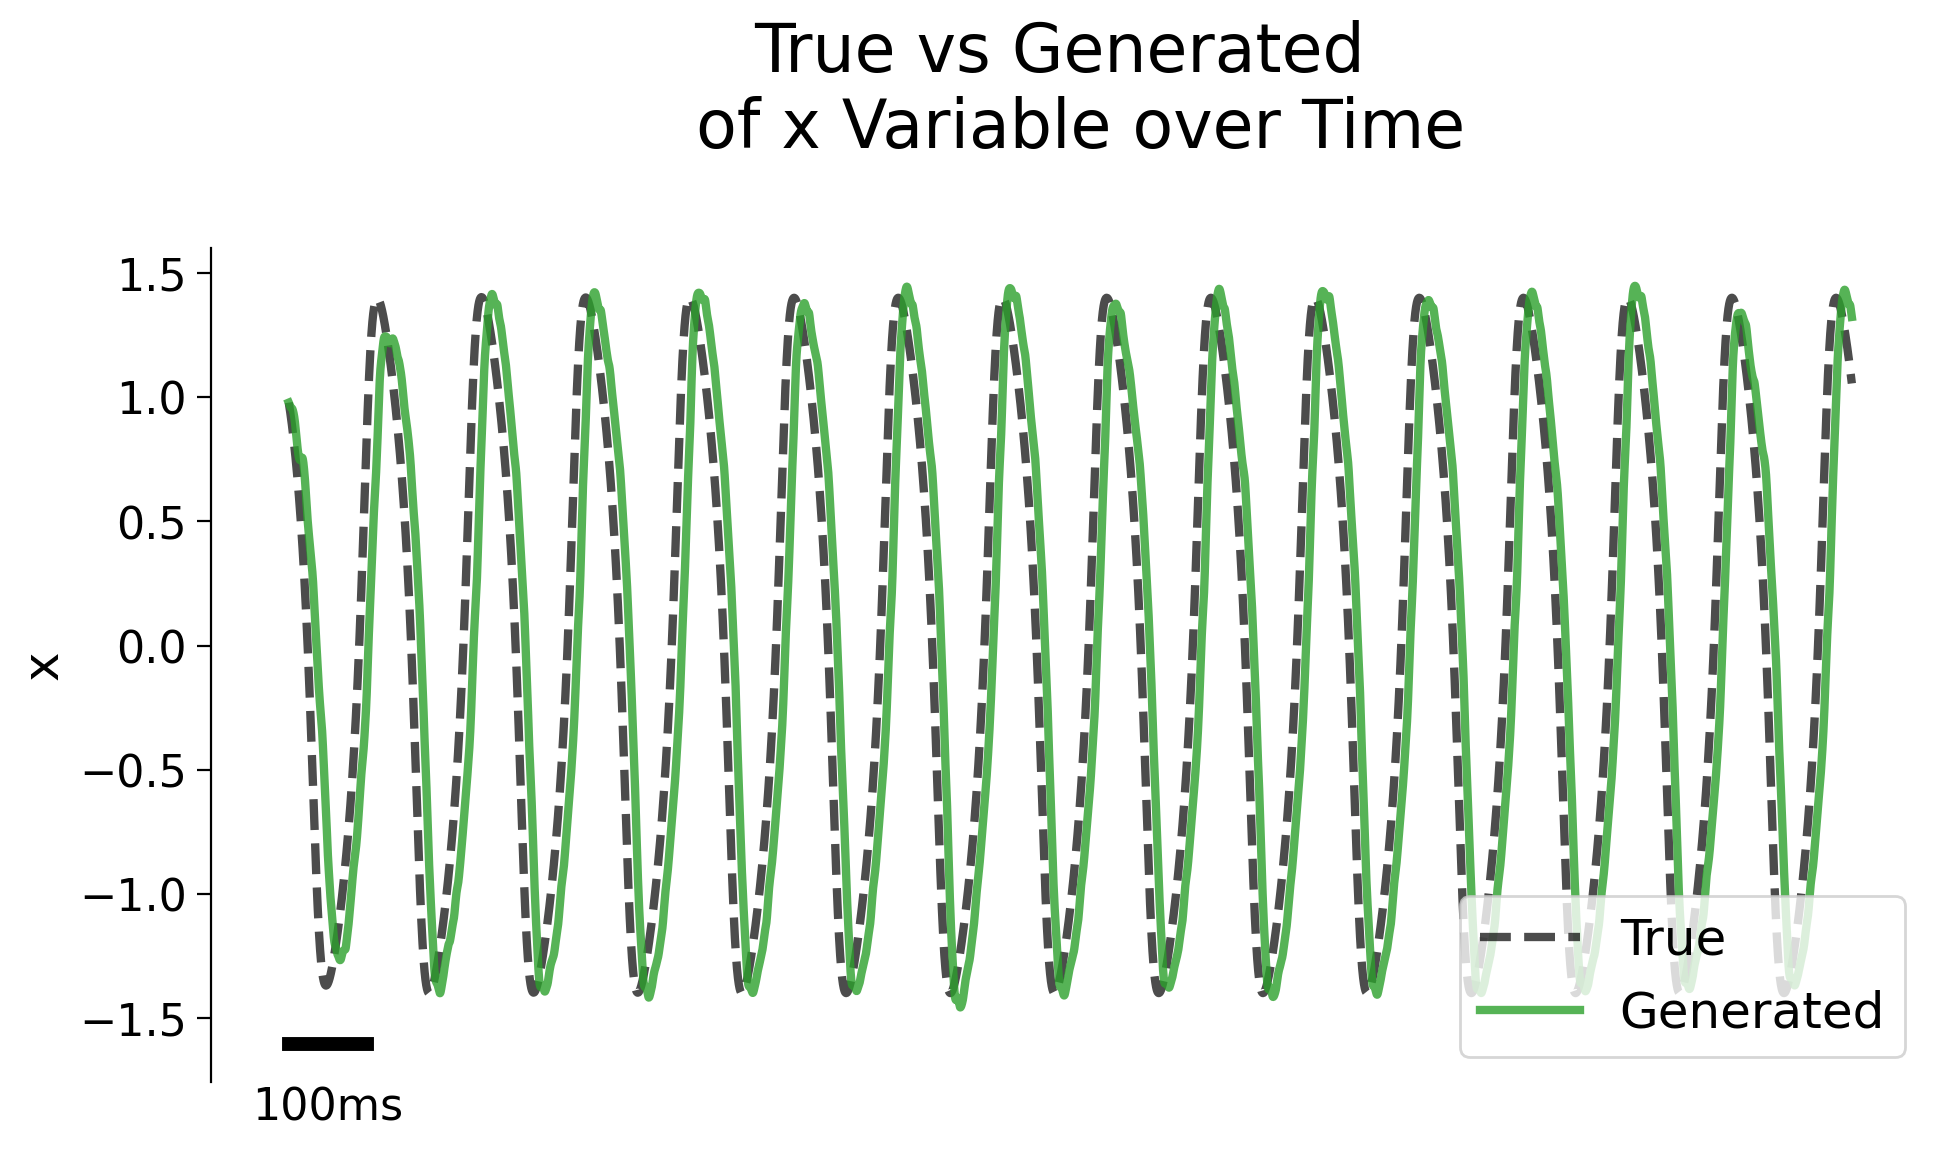

In [16]:
plt.figure(figsize=(10,6))

dt = 0.1

plt.title('True vs Generated \n of x Variable over Time', y=1.1)
plt.ylabel('x')
plt.plot(np.arange(0, generation_len) * dt, test_data_normalized[:,0],
         label="True", color='k', linestyle='--', alpha=0.7)

plt.plot(np.arange(0, generation_len) * dt, generated[:generation_len, 0],
         label="Generated", color='#2ca02c', linestyle='-', alpha=0.8)

plt.xticks([]) 
plt.gca().spines['bottom'].set_visible(False)

x_start = 0
x_end = 100 
y_pos = plt.ylim()[0] - 0.001 * (plt.ylim()[1] - plt.ylim()[0])

plt.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=5)
plt.text((x_start + x_end) / 2, y_pos - 0.05 * (plt.ylim()[1] - plt.ylim()[0]), "100ms", 
         ha='center', va='top', fontsize=16)
plt.legend(loc='lower right')

plt.xticks()
plt.yticks()  

plt.savefig('VanderPol-x variable.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

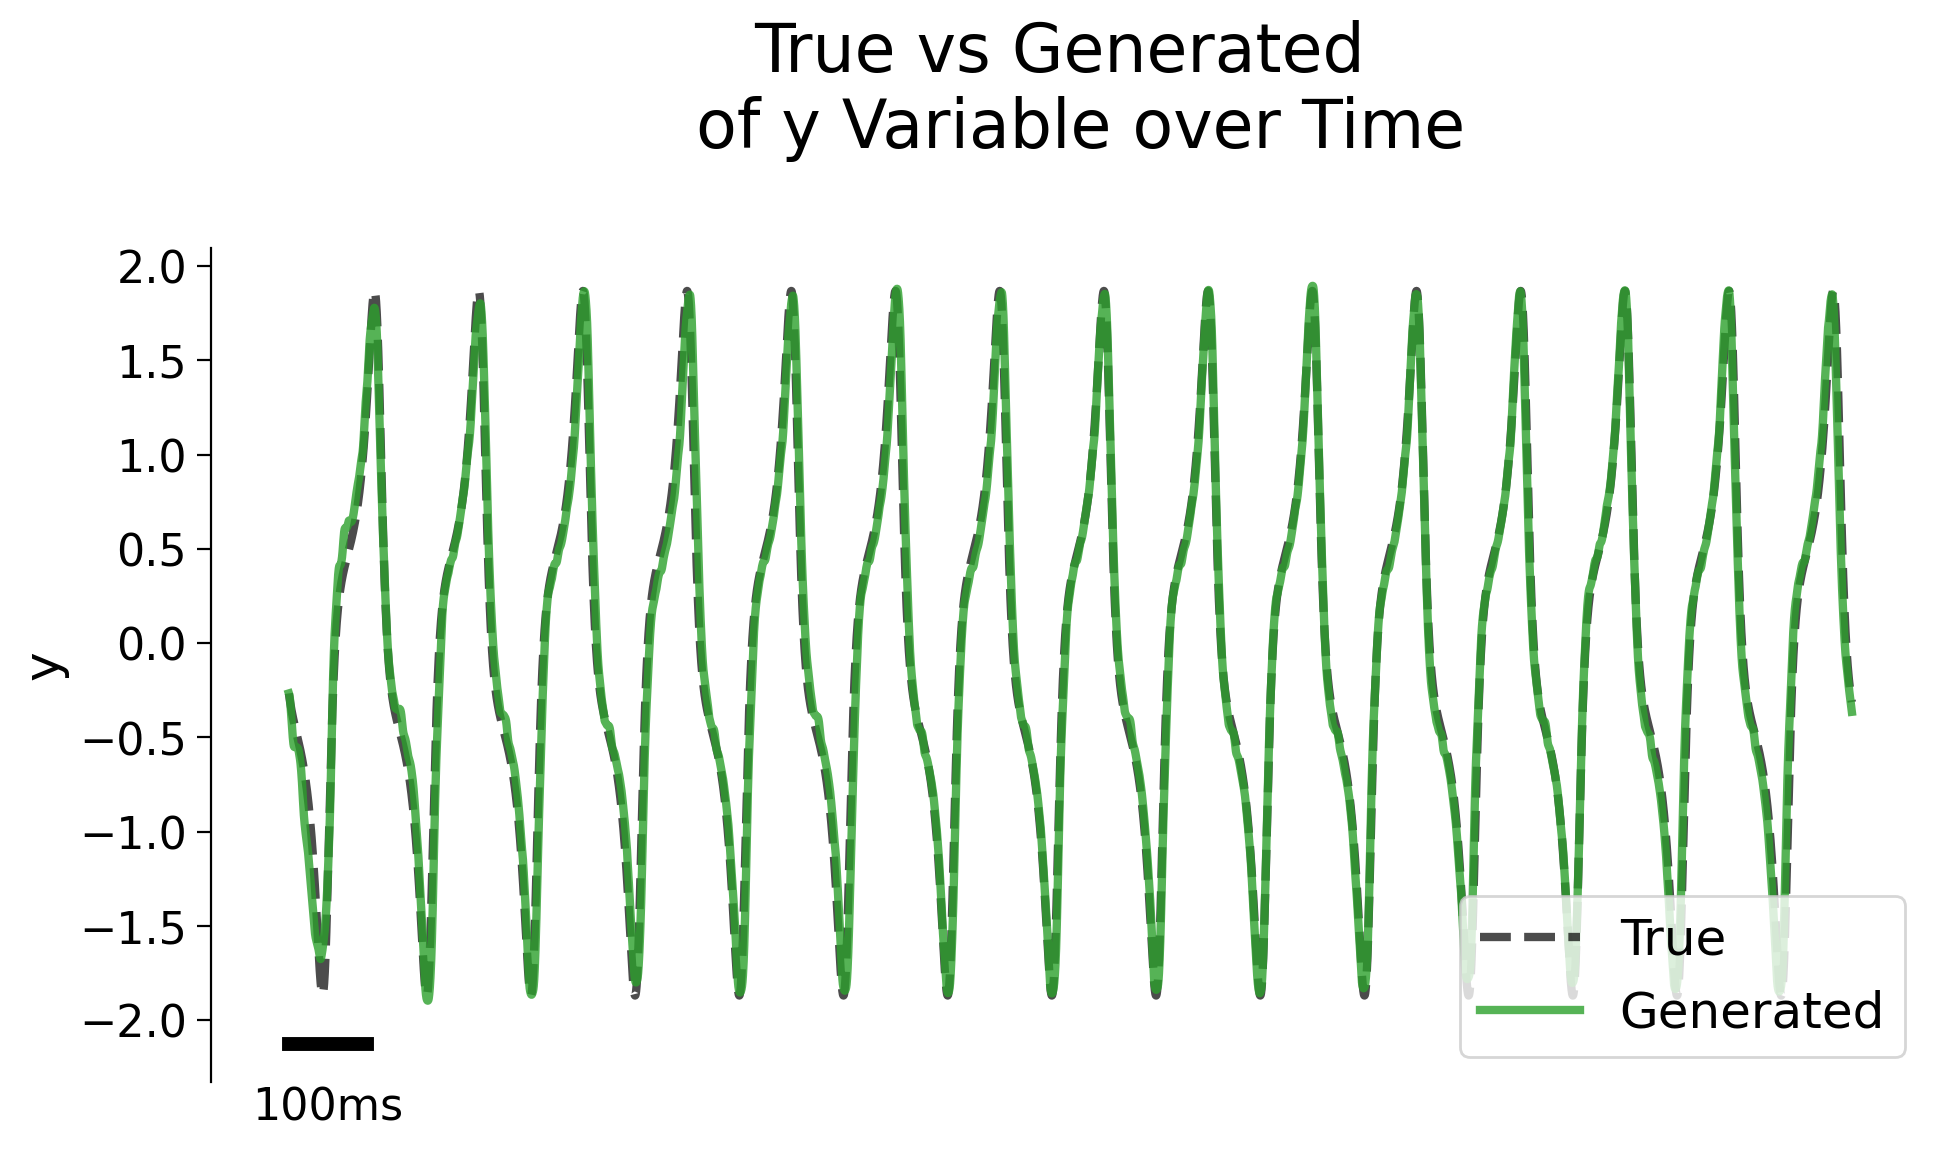

In [61]:
plt.figure(figsize=(10,6))
plt.title('True vs Generated \n of y Variable over Time', y=1.1)

plt.ylabel('y')
plt.plot(np.arange(0, generation_len) * dt, test_data_normalized[:,1],
         label="True", color='k', linestyle='--', alpha=0.7) # Black, Solid

plt.plot(np.arange(0, generation_len) * dt, generated[:generation_len, 1],
         label="Generated", color='#2ca02c', linestyle='-', alpha=0.8) # Matplotlib default green, Dashed

plt.xticks([]) 

plt.gca().spines['bottom'].set_visible(False)

x_start = 0
x_end = 100 
y_pos = plt.ylim()[0] - 0.01 * (plt.ylim()[1] - plt.ylim()[0]) 

plt.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=5)
plt.text((x_start + x_end) / 2, y_pos - 0.05 * (plt.ylim()[1] - plt.ylim()[0]), "100ms", 
         ha='center', va='top', fontsize=16)

plt.legend(loc='lower right')

plt.xticks()
plt.yticks()

plt.savefig('VanderPol-y variable.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

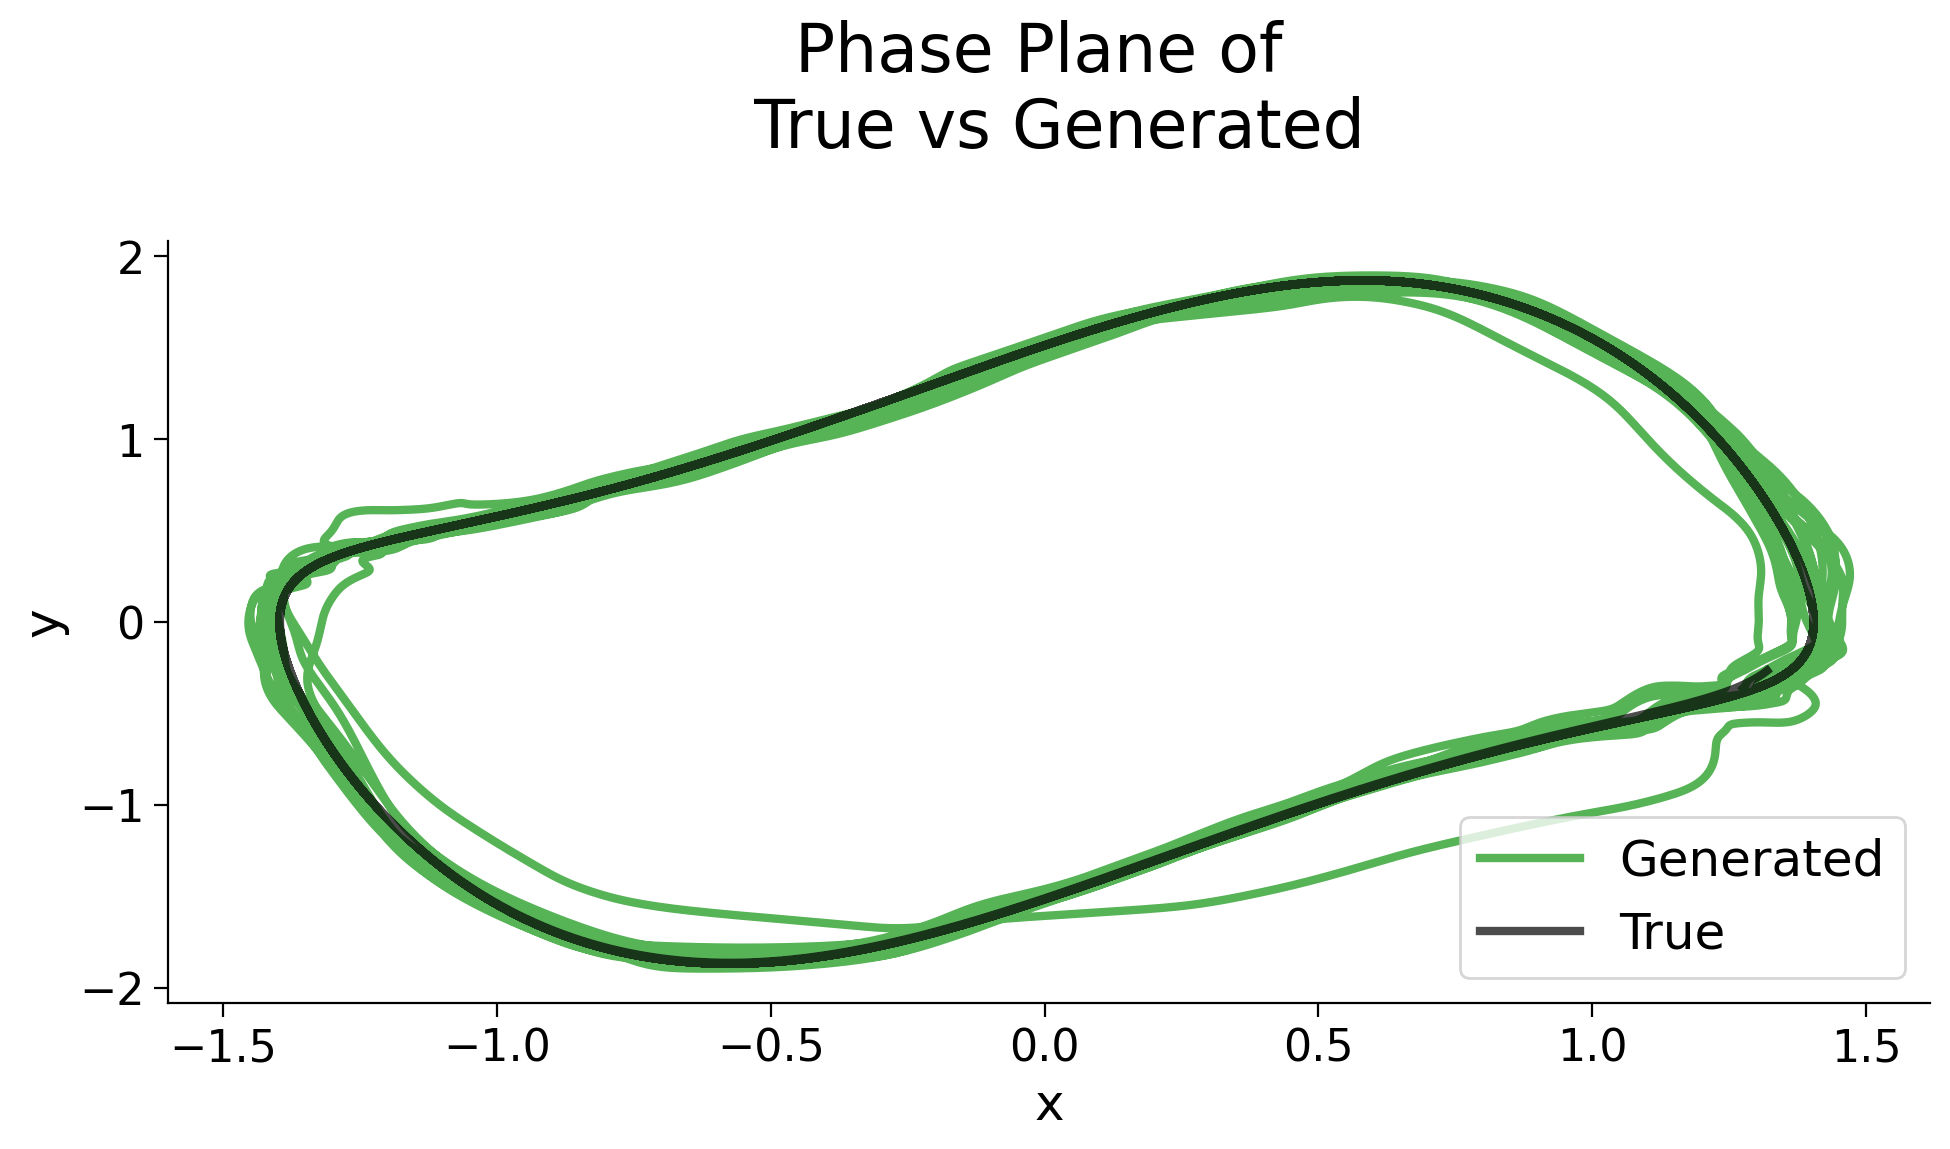

In [62]:
plt.figure(figsize=(10,6))

plt.title('Phase Plane of \n True vs Generated', y=1.1)
plt.ylabel('y')
plt.xlabel('x')

plt.plot(generated[:generation_len, 0], generated[:generation_len, 1],
         label="Generated", color='#2ca02c', linestyle='-', alpha=0.8) # Matplotlib default green, Dashed
plt.plot(test_data_normalized[:, 0], test_data_normalized[:, 1],
         label="True", color='k', linestyle='-', alpha=0.7) # Black, Solid

plt.legend(loc='lower right')

plt.xticks()
plt.yticks() 

plt.savefig('VanderPol-x-y variable.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

In [63]:
def plot_voltage_trace_stacked(data, num_neurons=5, neuron_offset=1.0, figure_name_prefix="", dt=0.1, linewidth=1.5):

    store = {k: v.cpu().numpy() for k, v in data.items()}
    time_steps = store['V_e'].shape[0]
    time = np.arange(0, time_steps) * dt

    dt = 0.1

    rand_e = np.random.choice(NE, num_neurons, replace=False)
    rand_i = np.random.choice(NI, num_neurons, replace=False)

    plot_configs = {
        'V_e': ("Excitatory Membrane Potentials", 'D', store['V_e'], rand_e, lambda x: x / 150),
        'V_i': ("Inhibitory Membrane Potentials", 'E', store['V_i'], rand_i, lambda x: x / 150),
        's_e': ("Excitatory Synaptic Variable", 'F', store['s_e'], rand_e, lambda x: x),
        's_i': ("Inhibitory Synaptic Variable", 'G', store['s_i'], rand_i, lambda x: x),
        'n_e': ("Excitatory Gating Variable", 'H', store['n_e'], rand_e, lambda x: x),
        'n_i': ("Inhibitory Gating Variable", 'I', store['n_i'], rand_e, lambda x: x),
        
    }

    for plot_key, (title, order, trace_data, neurons, transform) in plot_configs.items():
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)

        for idx, n in enumerate(neurons):
            offset = idx * neuron_offset
            
            plot_trace = transform(trace_data[:generation_len, n]) + offset + 1
            ax.plot(np.arange(0, generation_len) * dt, plot_trace, label=f'Neuron {n}')

            ax.plot(np.arange(0, generation_len) * dt, np.full_like(time, offset + 1), 
                    color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        
        # Hide the box/spines
        plt.gca().spines['bottom'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        
        # Set titles
        ax.set_title(title, y=1.05)
        ax.set_ylabel("Neurons")

        ax.set_yticks(np.arange(1, num_neurons + 1))
        ax.set_xticks([])
        
        ax.grid(True, alpha=0.3)

        plt.xticks([])
        
        x_start = 0
        x_end = 100  
        y_pos = plt.ylim()[0] - 0.01 * (plt.ylim()[1] - plt.ylim()[0]) 
        
        plt.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=5)
        plt.text((x_start + x_end) / 2, y_pos - 0.05 * (plt.ylim()[1] - plt.ylim()[0]), "100ms", 
         ha='center', va='top', fontsize=16)
        
        if figure_name_prefix:
            filename = f"{figure_name_prefix}_{plot_key}.svg"
            plt.savefig(filename, format='svg', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)



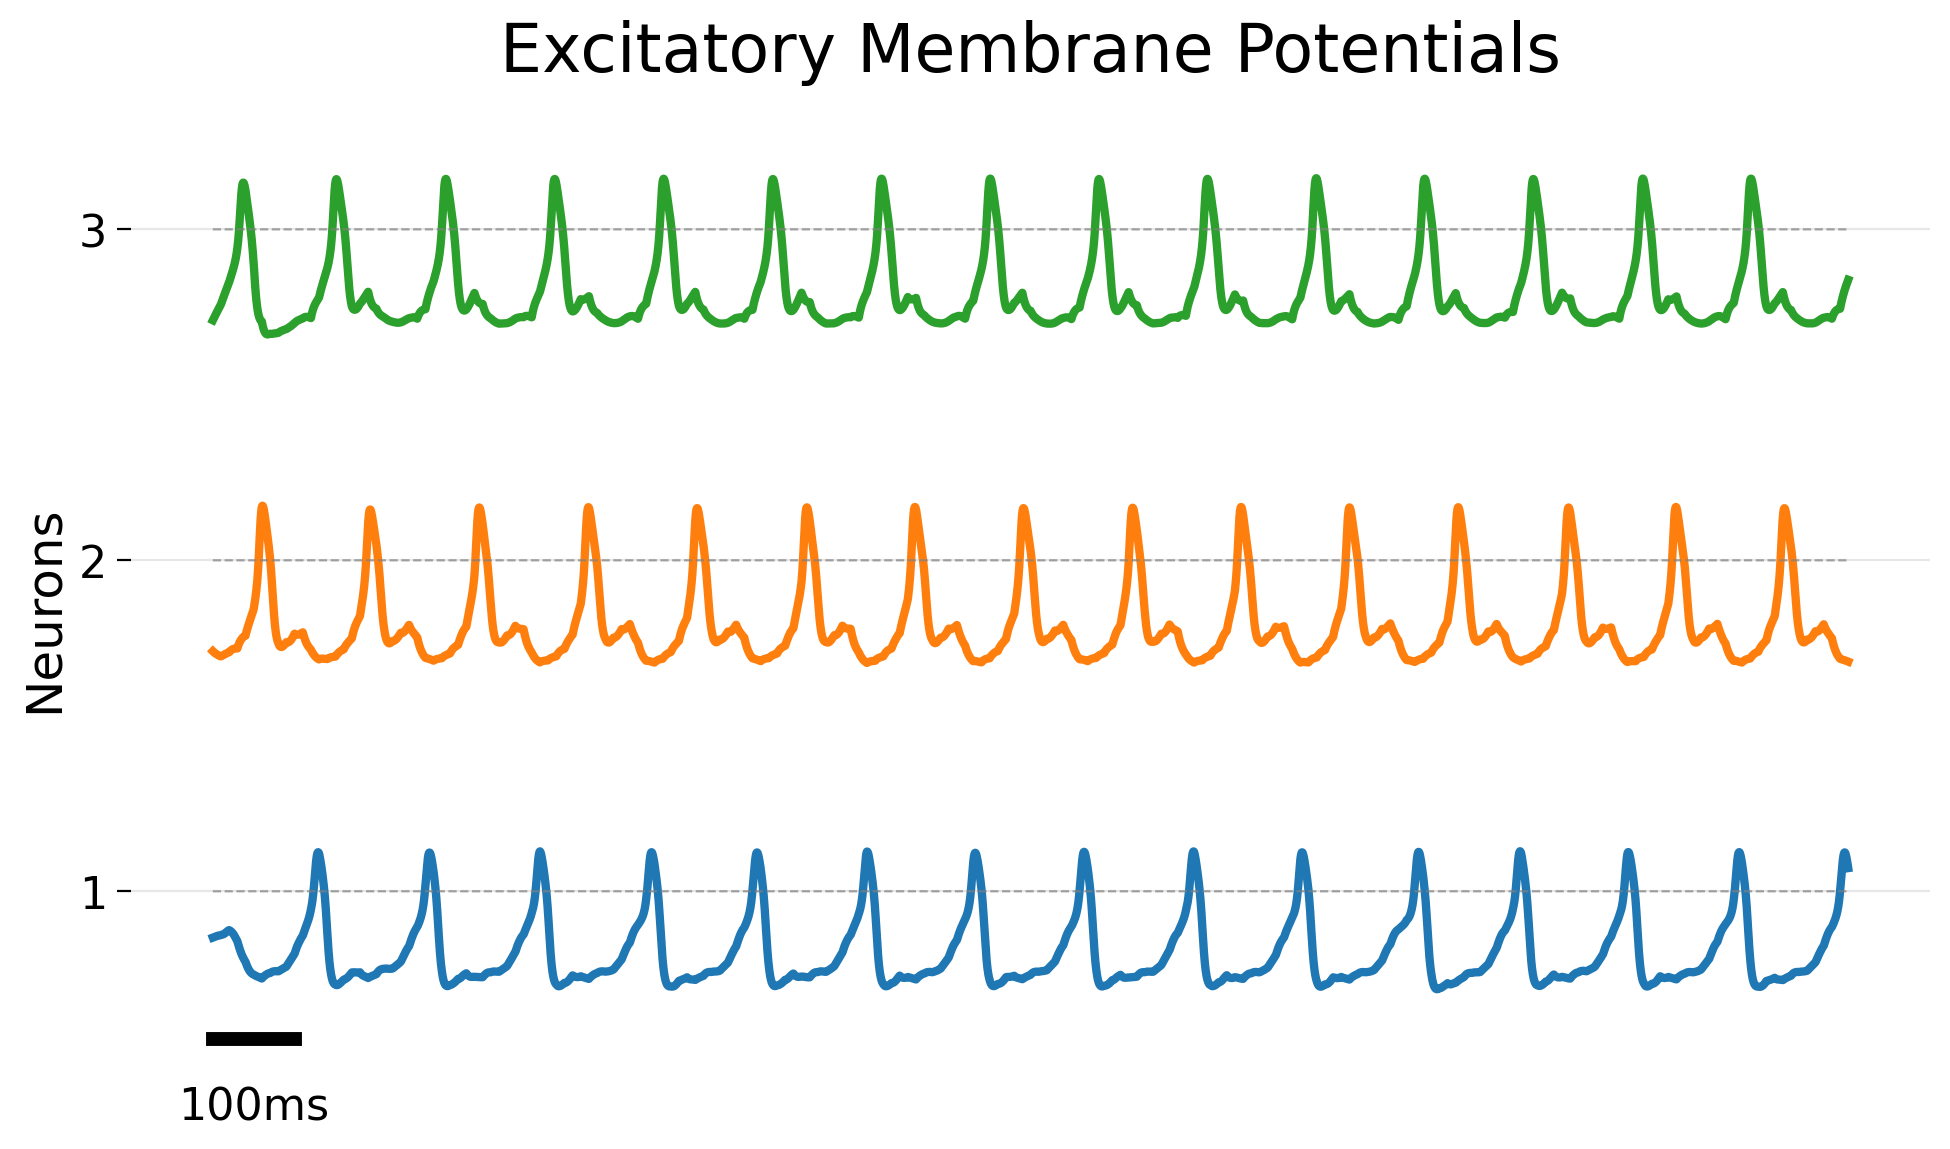

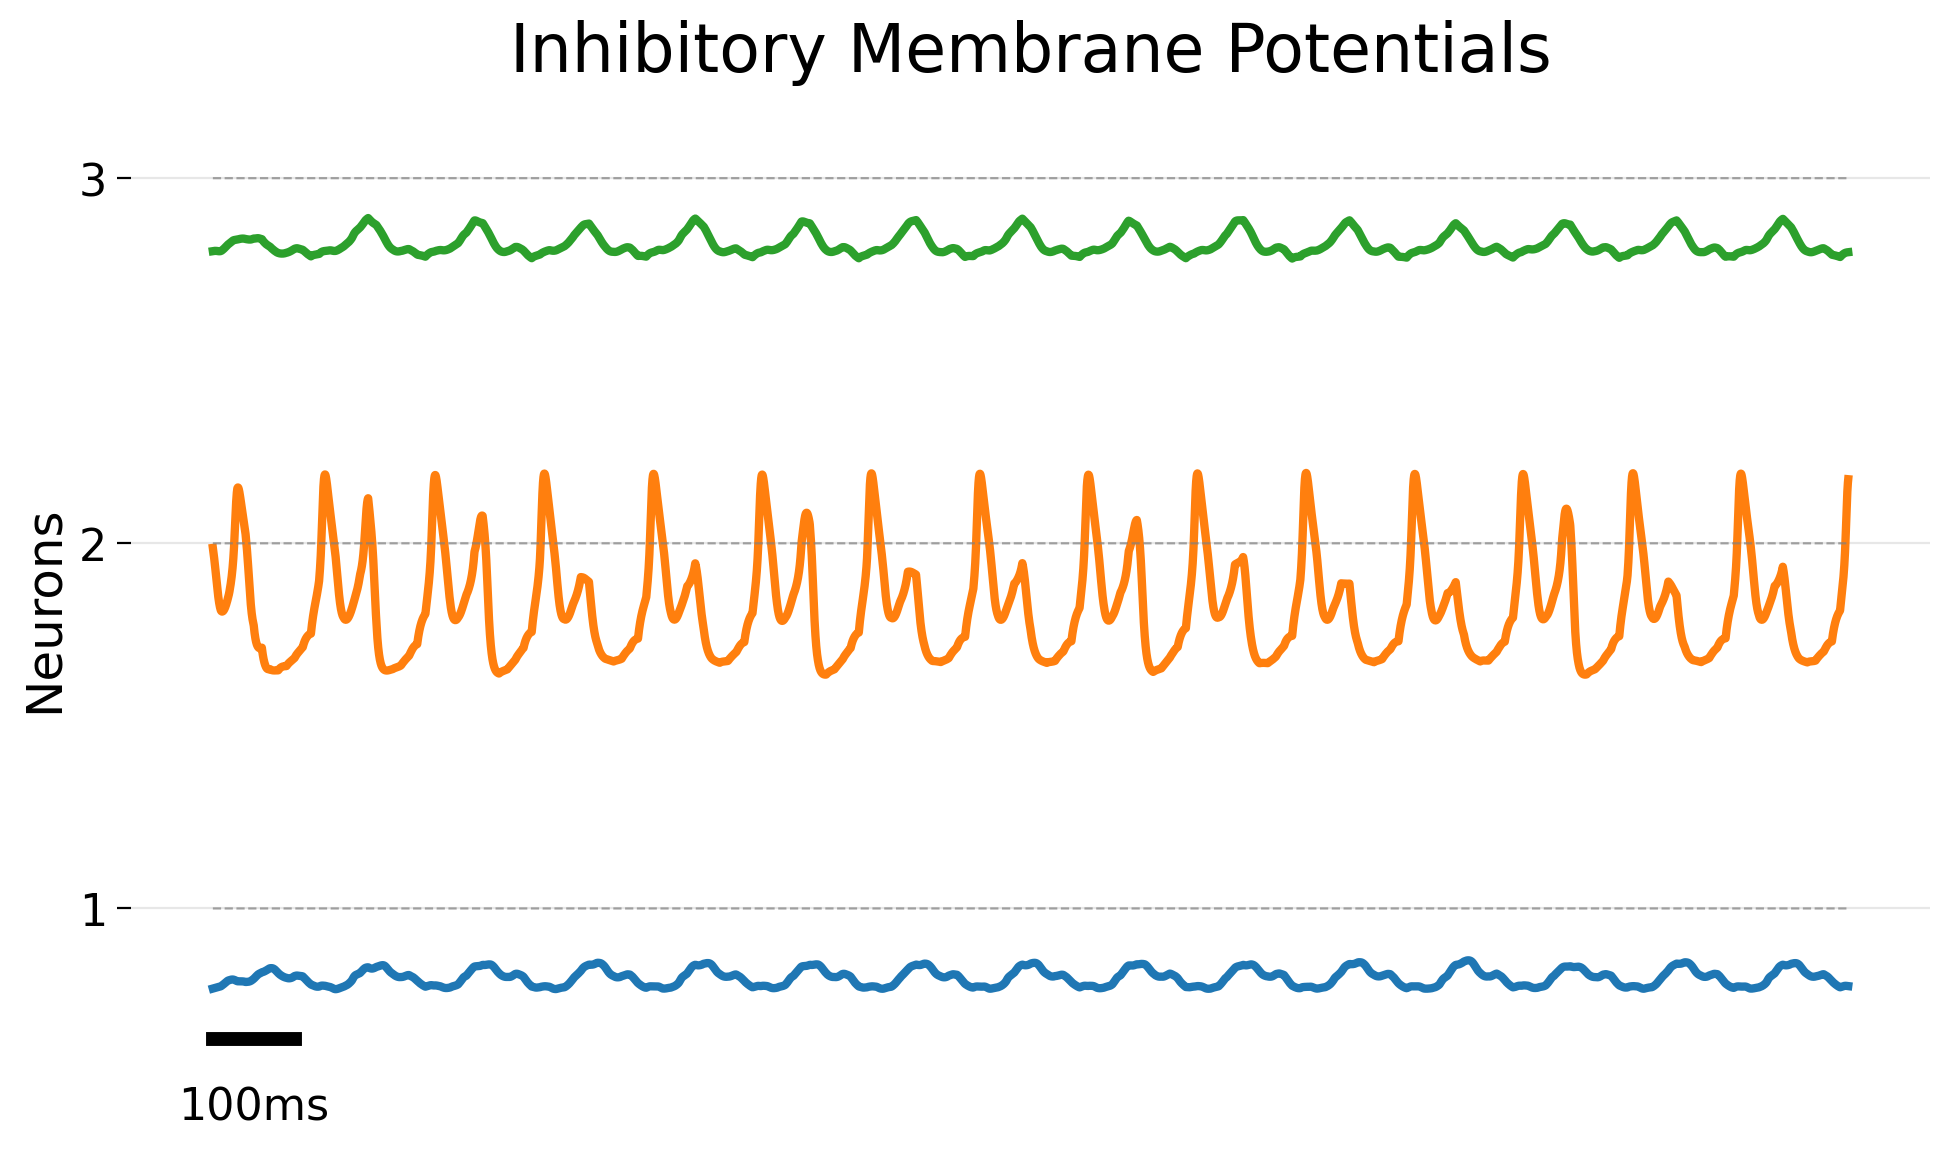

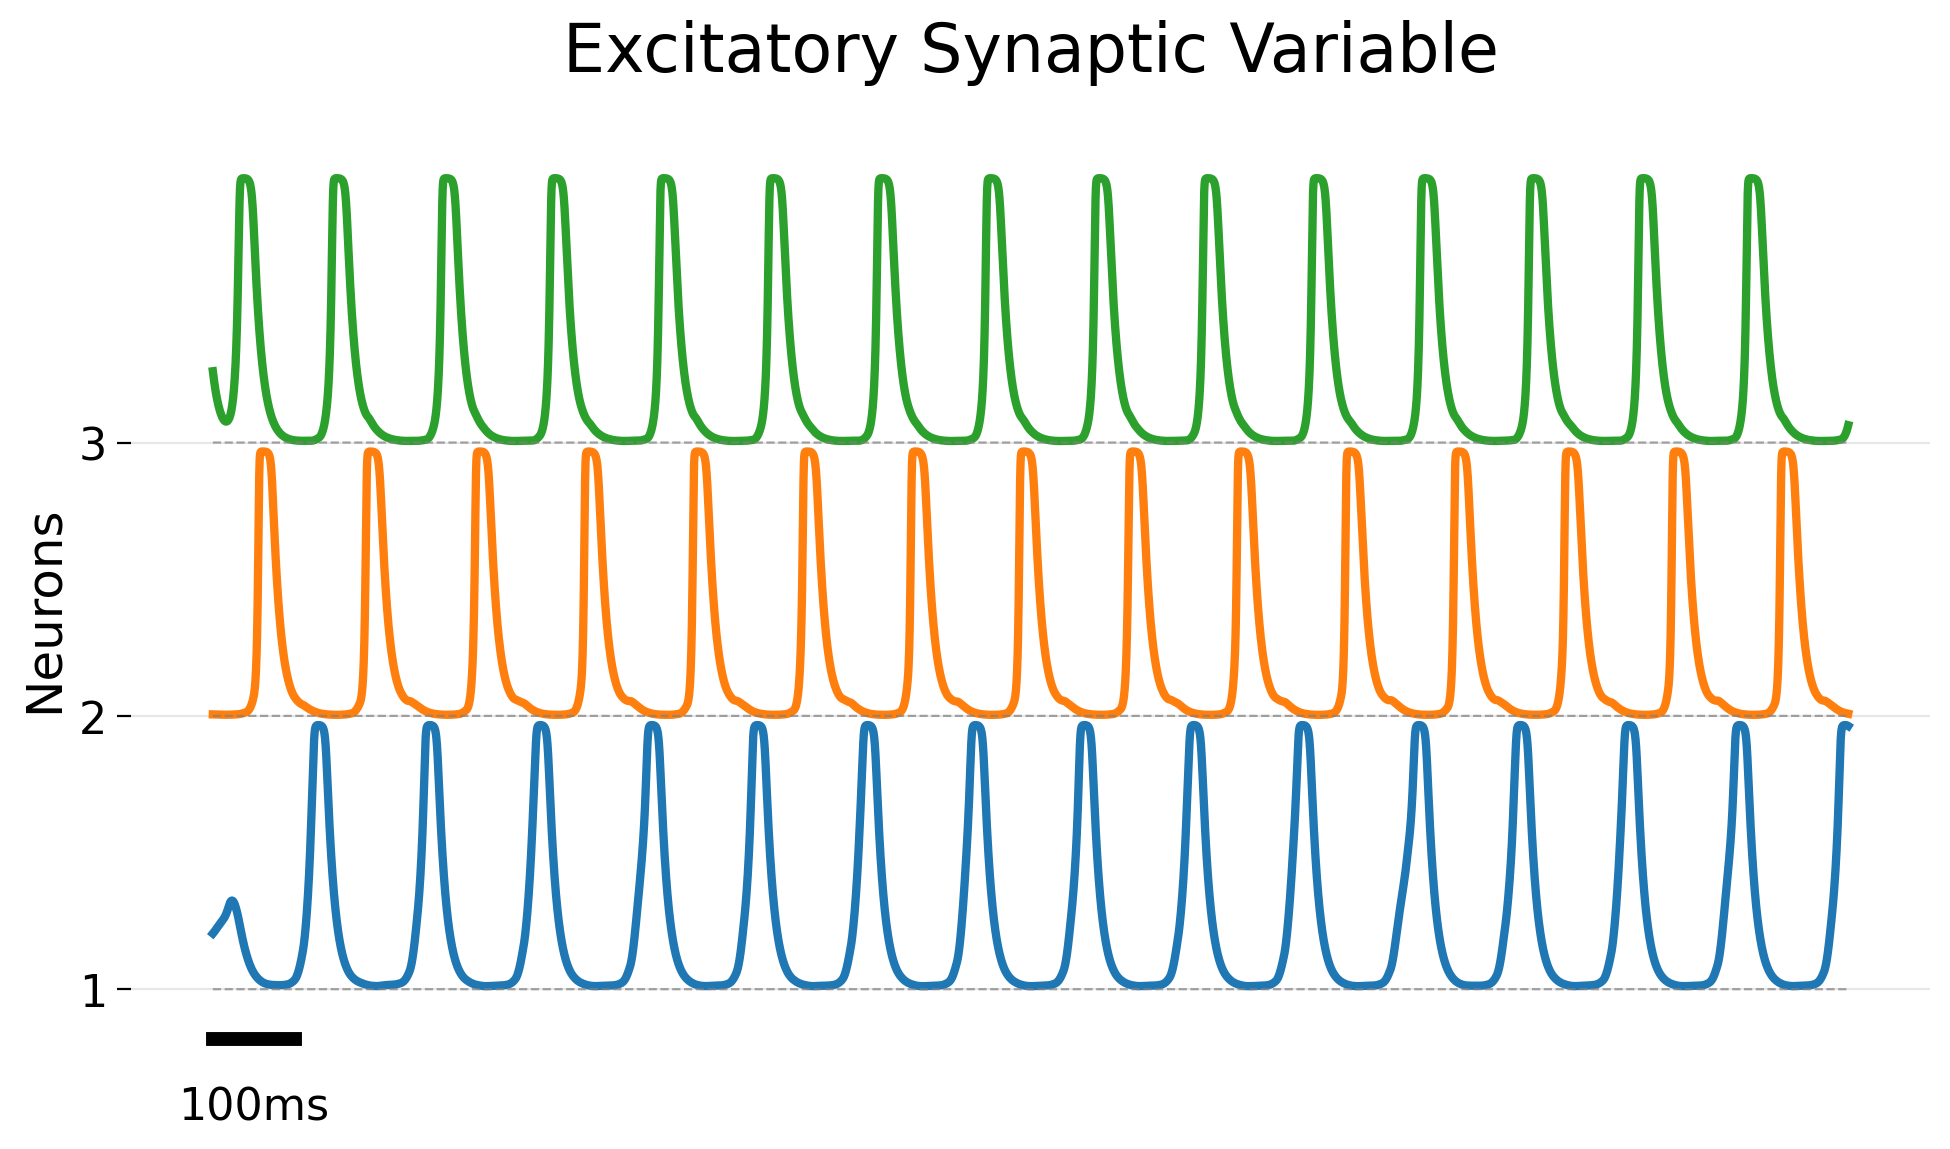

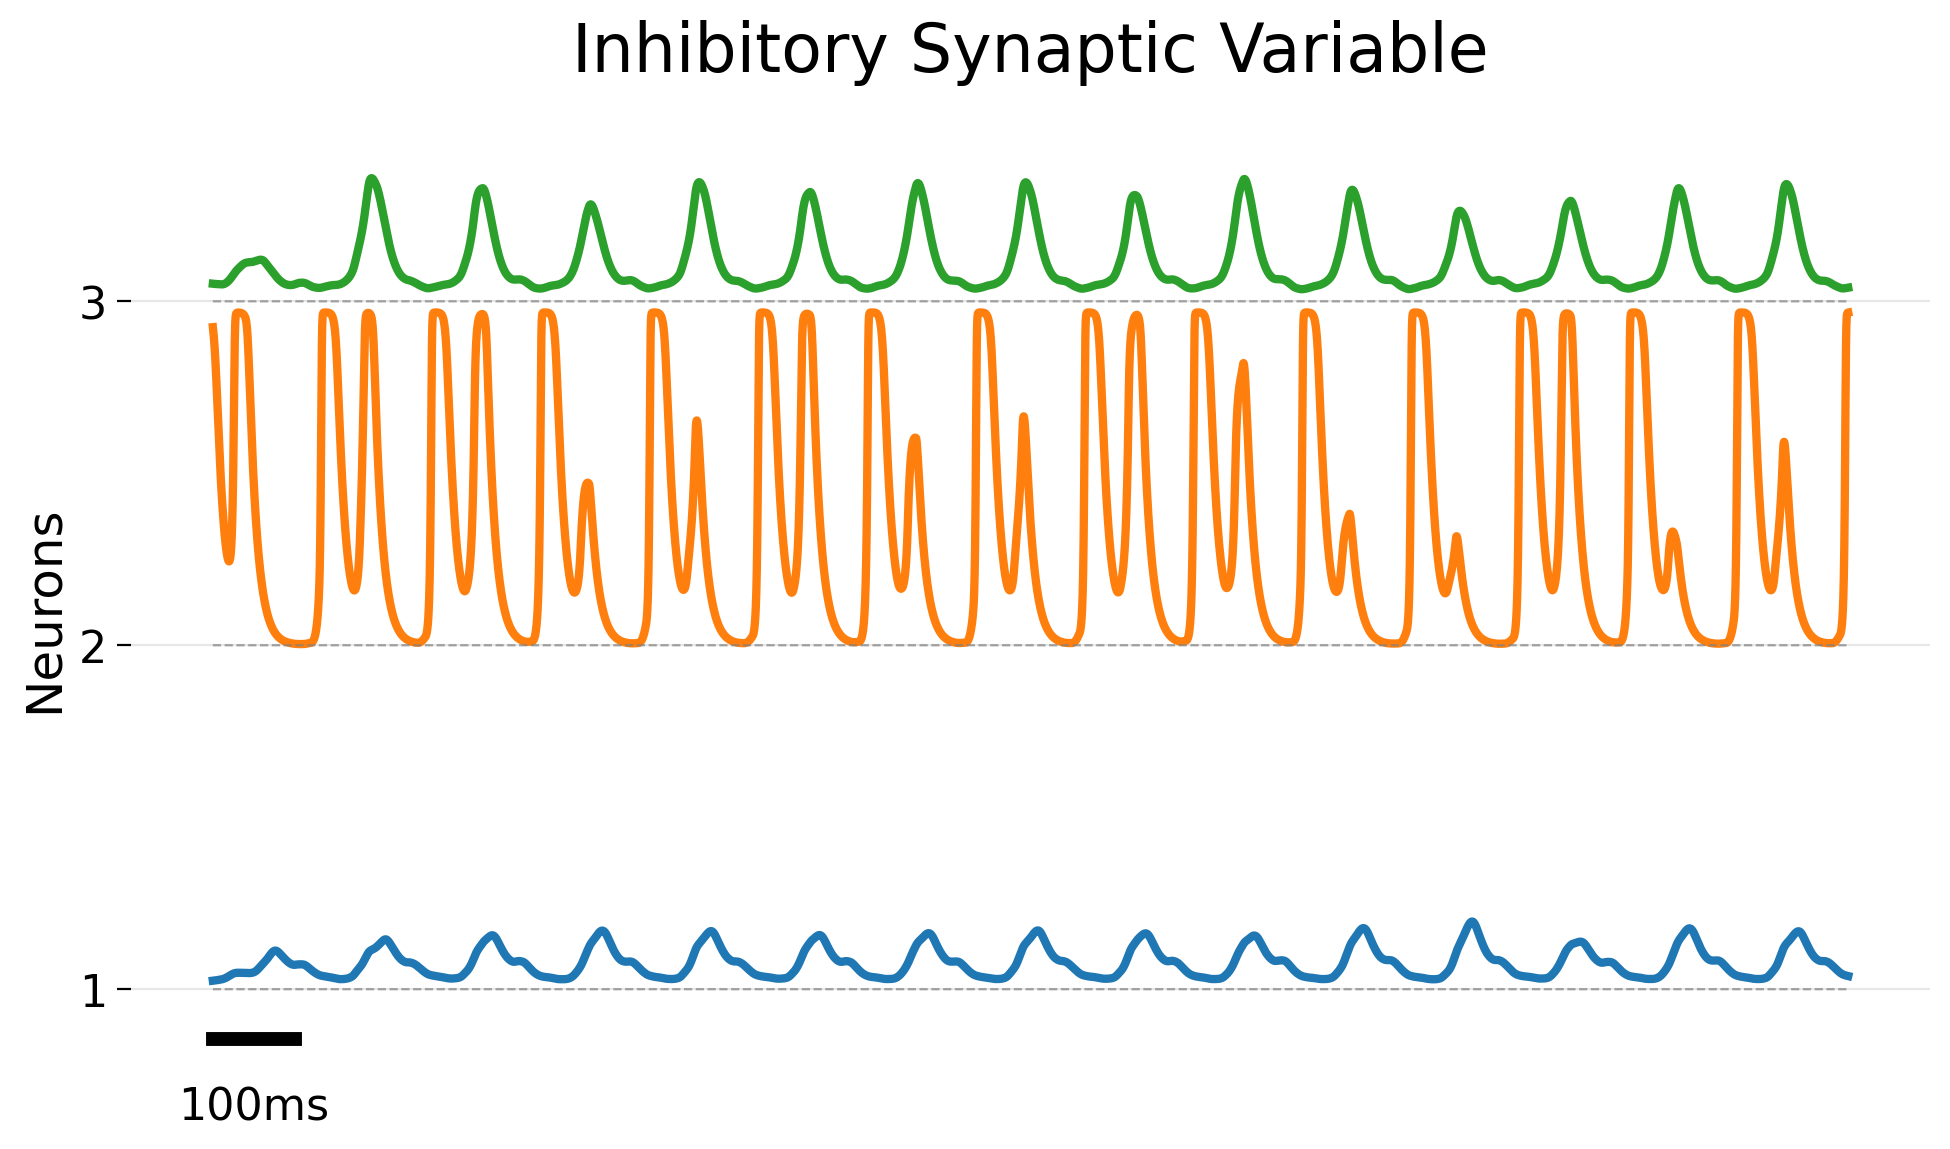

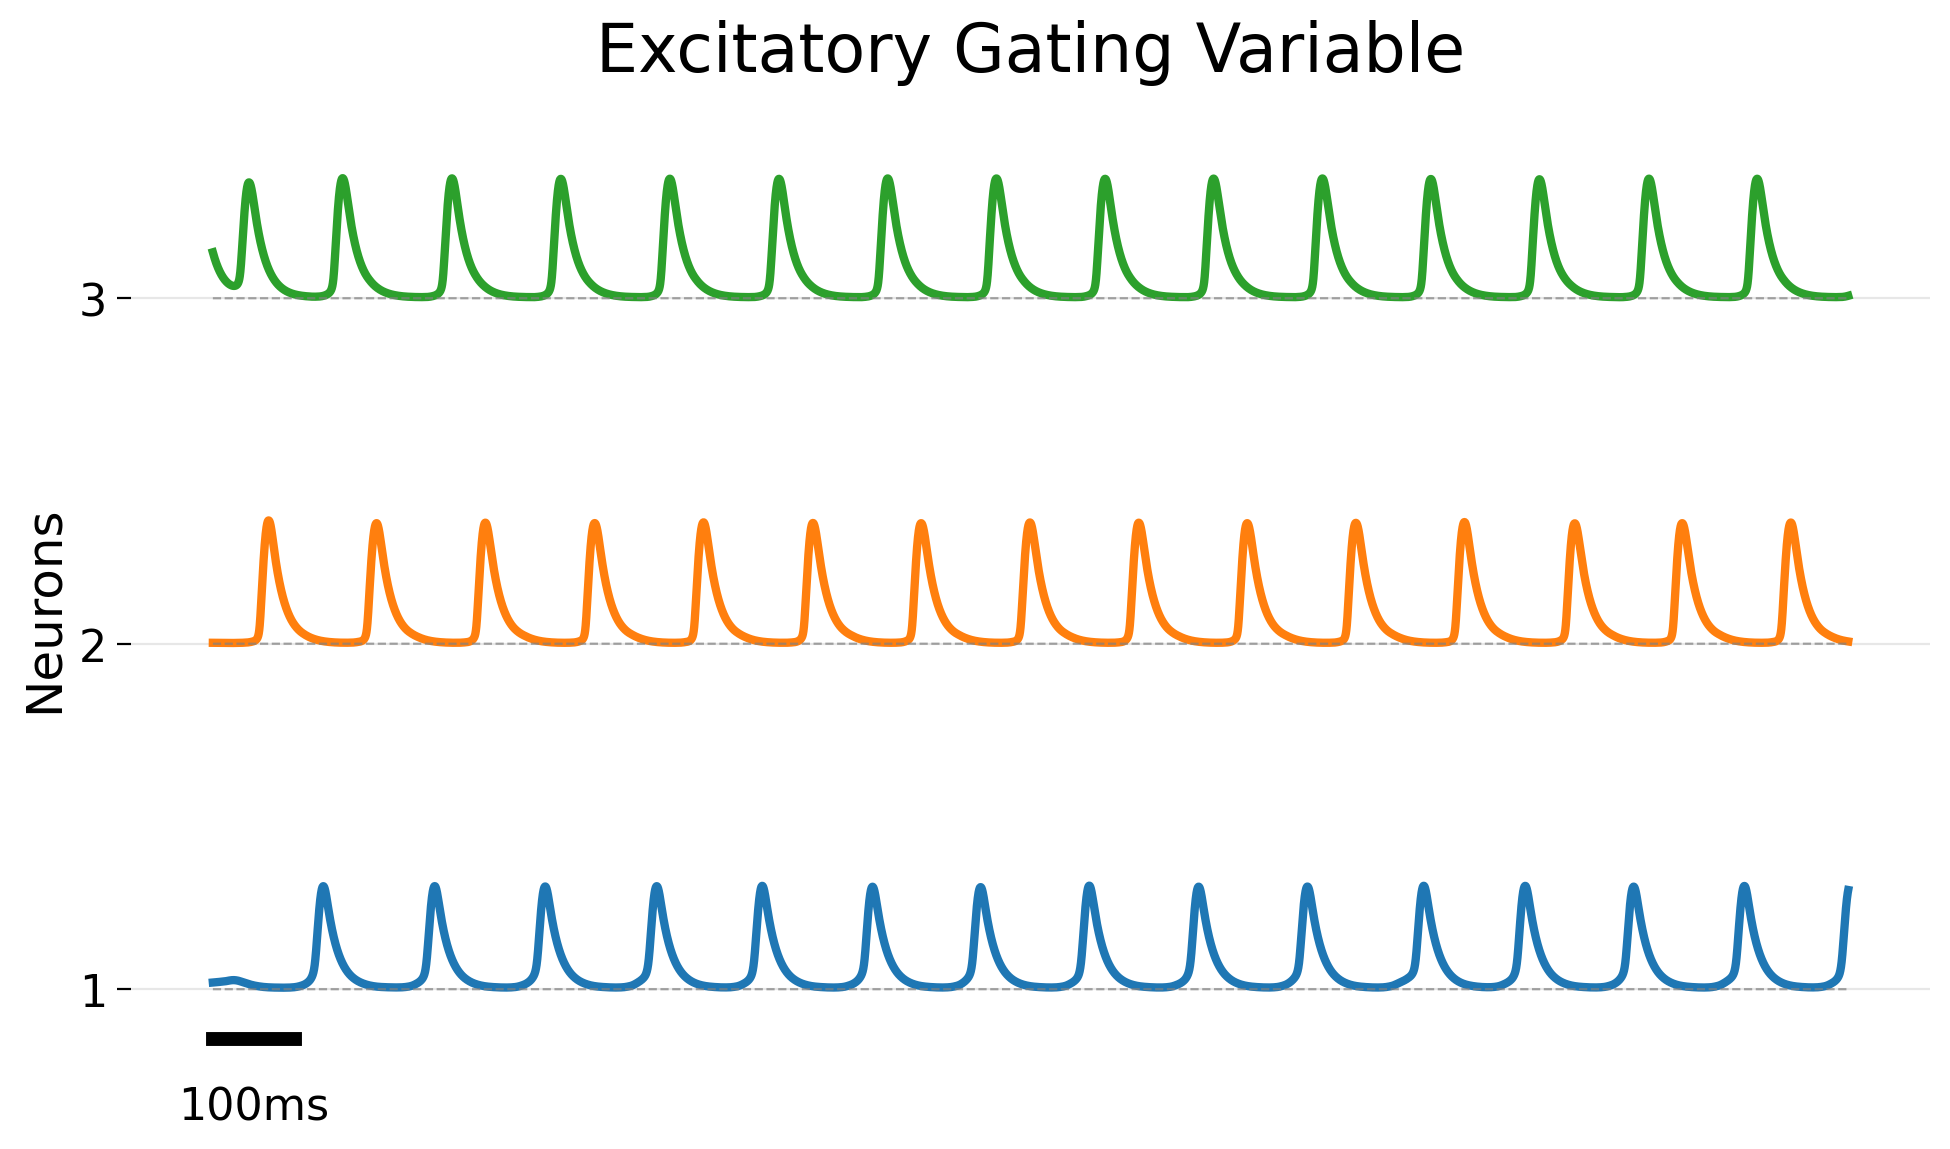

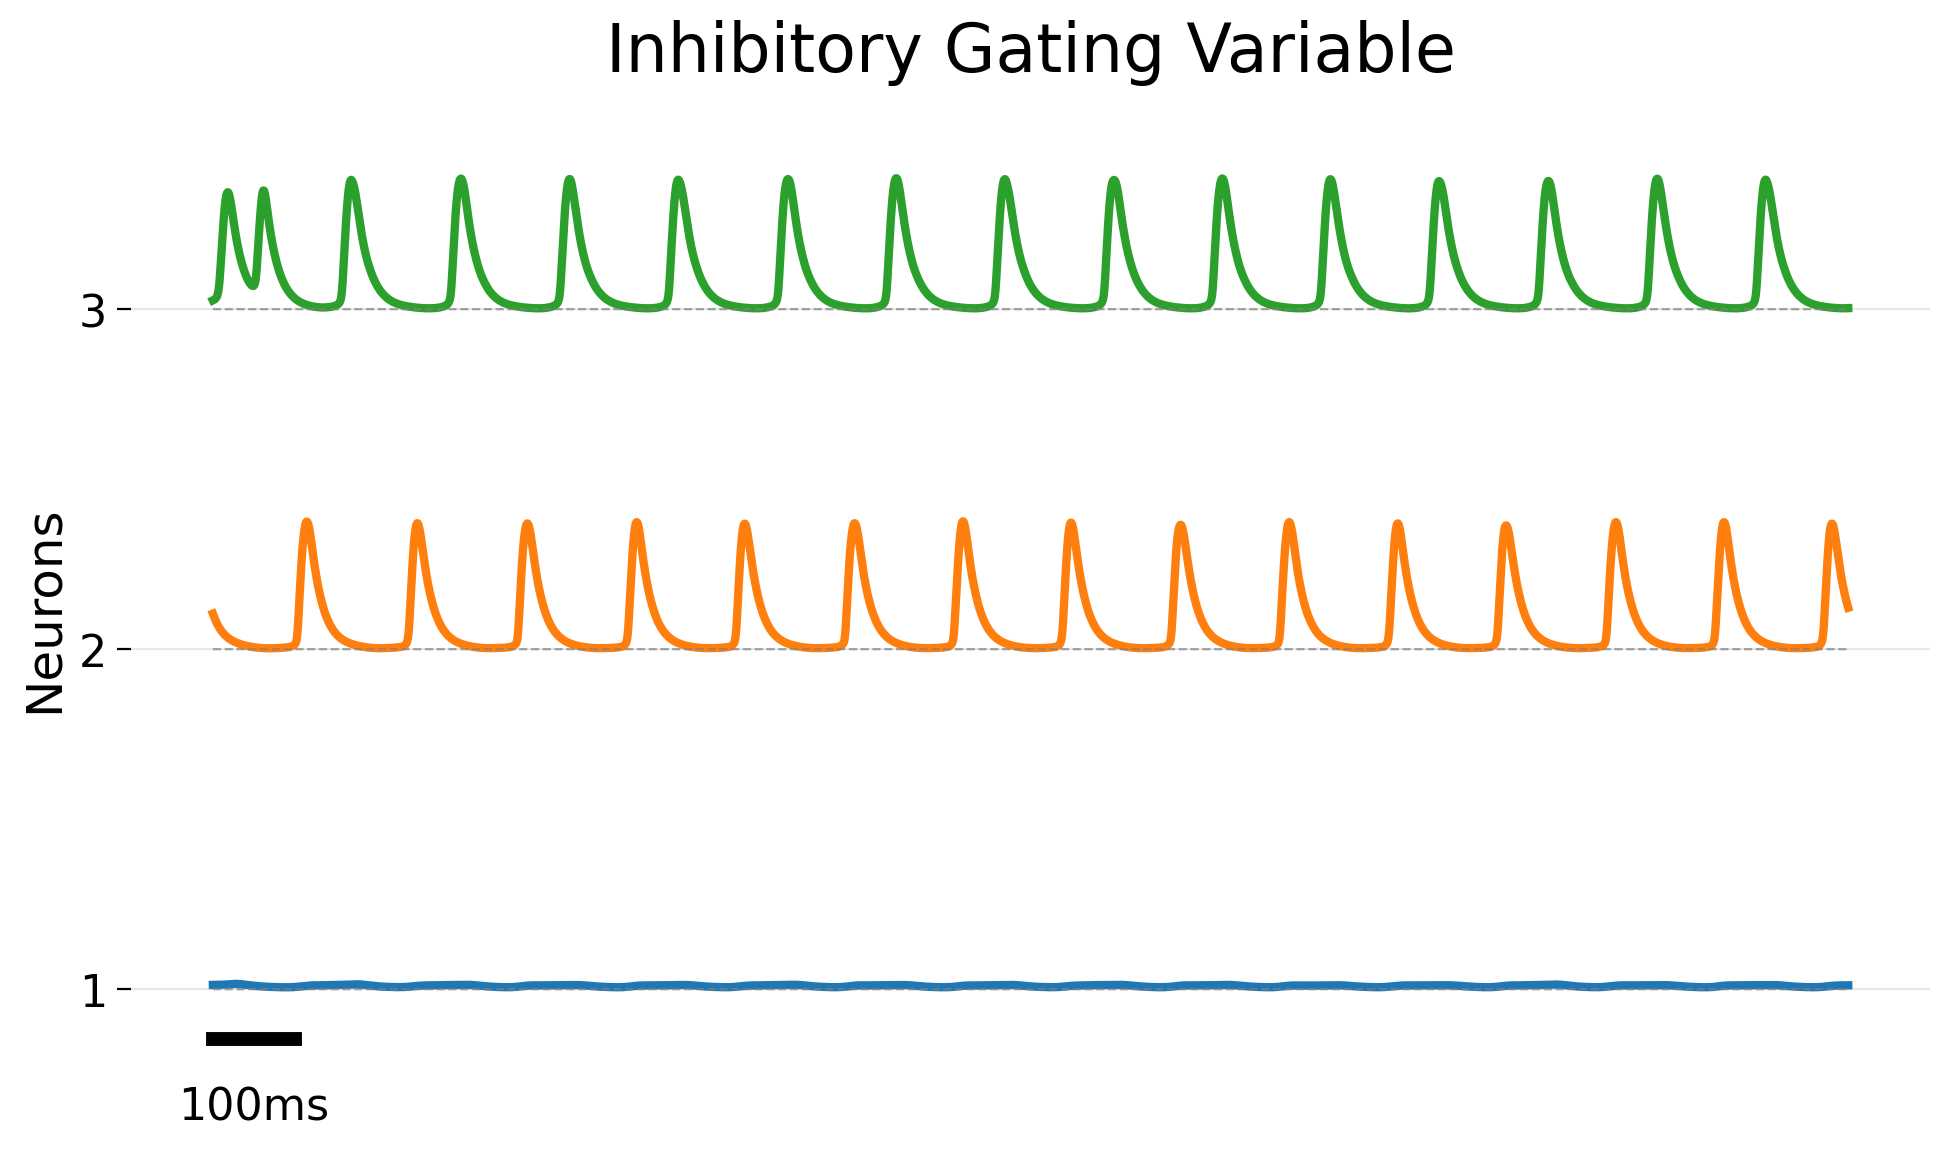

In [64]:
data = {
            'V_e': torch.zeros(generation_len,NE, device=device),
            'n_e': torch.zeros(generation_len, NE, device=device),
            's_e': torch.zeros(generation_len, NE, device=device),
            'V_i': torch.zeros(generation_len, NI, device=device),
            'n_i': torch.zeros(generation_len, NI, device=device),
            's_i': torch.zeros(generation_len, NI, device=device)
        }

data = trained_model.get_storage()
plot_voltage_trace_stacked(data, 3, 1, "Voltage_traces_VanDerPol")

## Plot Heatmap and Eigenvalues Figure of Synaptic Weights before and after trainning

In [44]:
def plot_sampled_weights_heatmap(initial_state_dict, N_full=250, N_sub=50, seed=42, title=""):
    W_ee_full = initial_state_dict['omega_ee_raw'].cpu().numpy()
    W_ei_full = initial_state_dict['omega_ei_raw'].cpu().numpy()
    W_ie_full = initial_state_dict['omega_ie_raw'].cpu().numpy()
    W_ii_full = initial_state_dict['omega_ii_raw'].cpu().numpy()
    
    np.random.seed(seed)
    E_indices = np.random.choice(N_full, size=N_sub, replace=False)
    I_indices = np.random.choice(N_full, size=N_sub, replace=False)

    W_ee_sub = W_ee_full[np.ix_(E_indices, E_indices)]
    W_ei_sub = W_ei_full[np.ix_(E_indices, I_indices)]
    W_ie_sub = W_ie_full[np.ix_(I_indices, E_indices)]
    W_ii_sub = W_ii_full[np.ix_(I_indices, I_indices)]

    top_row = np.hstack((W_ee_sub, W_ei_sub))
    bottom_row = np.hstack((W_ie_sub, W_ii_sub))
    W_sub_full = np.vstack((top_row, bottom_row))

    max_abs_val = np.max(np.abs(W_sub_full))
    vmin, vmax = -max_abs_val, max_abs_val
    
    plt.figure(figsize=(12, 10)) 
    
    plt.imshow(W_sub_full, cmap='RdYlBu', aspect='equal', vmin=vmin, vmax=vmax)
    
    cbar = plt.colorbar(shrink=0.8)
    cbar.ax.tick_params(labelsize=10)

    plt.axhline(N_sub - 0.5, color='black', linestyle='-')
    plt.axvline(N_sub - 0.5, color='black', linestyle='-')
    
    for i in range(1, 2 * N_sub):
        if i != N_sub:
            plt.axhline(i - 0.5, color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
            plt.axvline(i - 0.5, color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

    text_color = 'black'
    text_size = 22
    plt.text(N_sub/2, N_sub/2, 'E $\\to$ E', color=text_color, ha='center', va='center', weight='bold')
    plt.text(N_sub + N_sub/2, N_sub/2, 'I $\\to$ E', color=text_color, ha='center', va='center', weight='bold')
    plt.text(N_sub/2, N_sub + N_sub/2, 'E $\\to$ I', color=text_color, ha='center', va='center', weight='bold')
    plt.text(N_sub + N_sub/2, N_sub + N_sub/2, 'I $\\to$ I', color=text_color, ha='center', va='center', weight='bold')

    tick_positions = [N_sub/2, N_sub + N_sub/2]
    tick_labels = ['Excitatory', 'Inhibitory']

    plt.xticks(tick_positions, tick_labels, rotation=0,) # Remove rotation for clarity
    plt.yticks(tick_positions, tick_labels)

    plt.xlabel('Pre-synaptic Neuron Population', labelpad=10)
    plt.ylabel('Post-synaptic Neuron Population', labelpad=10)
    plt.title(title, weight='bold')

    plt.tight_layout()
    plt.savefig(f'{title}.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()

In [45]:
from numpy.linalg import eig

def plot_full_spectrum(state_dict, title="Eigenvalue Spectrum", N_full=250, color='tab:blue'):

    def get_weights(key):
        try:
            return state_dict[key].cpu().numpy()
        except KeyError as e:
            raise ValueError(f"Required key '{e}' not found in the state_dict.")

    W_ee = get_weights('omega_ee_raw')
    W_ei = get_weights('omega_ei_raw')
    W_ie = get_weights('omega_ie_raw')
    W_ii = get_weights('omega_ii_raw')

    top_row = np.hstack((W_ee, W_ei))
    bottom_row = np.hstack((W_ie, W_ii))
    W_full = np.vstack((top_row, bottom_row))
    print(W_full.max())
    
    print(f"Computing eigenvalues for {title} (Matrix size: {W_full.shape})...")
    eigvals, _ = eig(W_full)
    
    plt.figure(figsize=(8, 8))
    
    plt.scatter(eigvals.real, eigvals.imag, 
                s=20, alpha=0.7, color=color)

    theta = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.6, label='Unit Circle')
    
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

    max_abs_val = np.max(np.abs(eigvals)) * 1.1
    plot_limit = max(max_abs_val, 1.2)
    
    plt.xlim([-plot_limit, plot_limit])
    plt.ylim([-plot_limit, plot_limit])
    plt.gca().set_aspect('equal', adjustable='box') 
    
    plt.xlabel('Real Part ($\mathrm{Re}(\lambda)$)', fontsize=14)
    plt.ylabel('Imaginary Part ($\mathrm{Im}(\lambda)$)', fontsize=14)
    plt.title(title, fontsize=16, weight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_Spectrum.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()

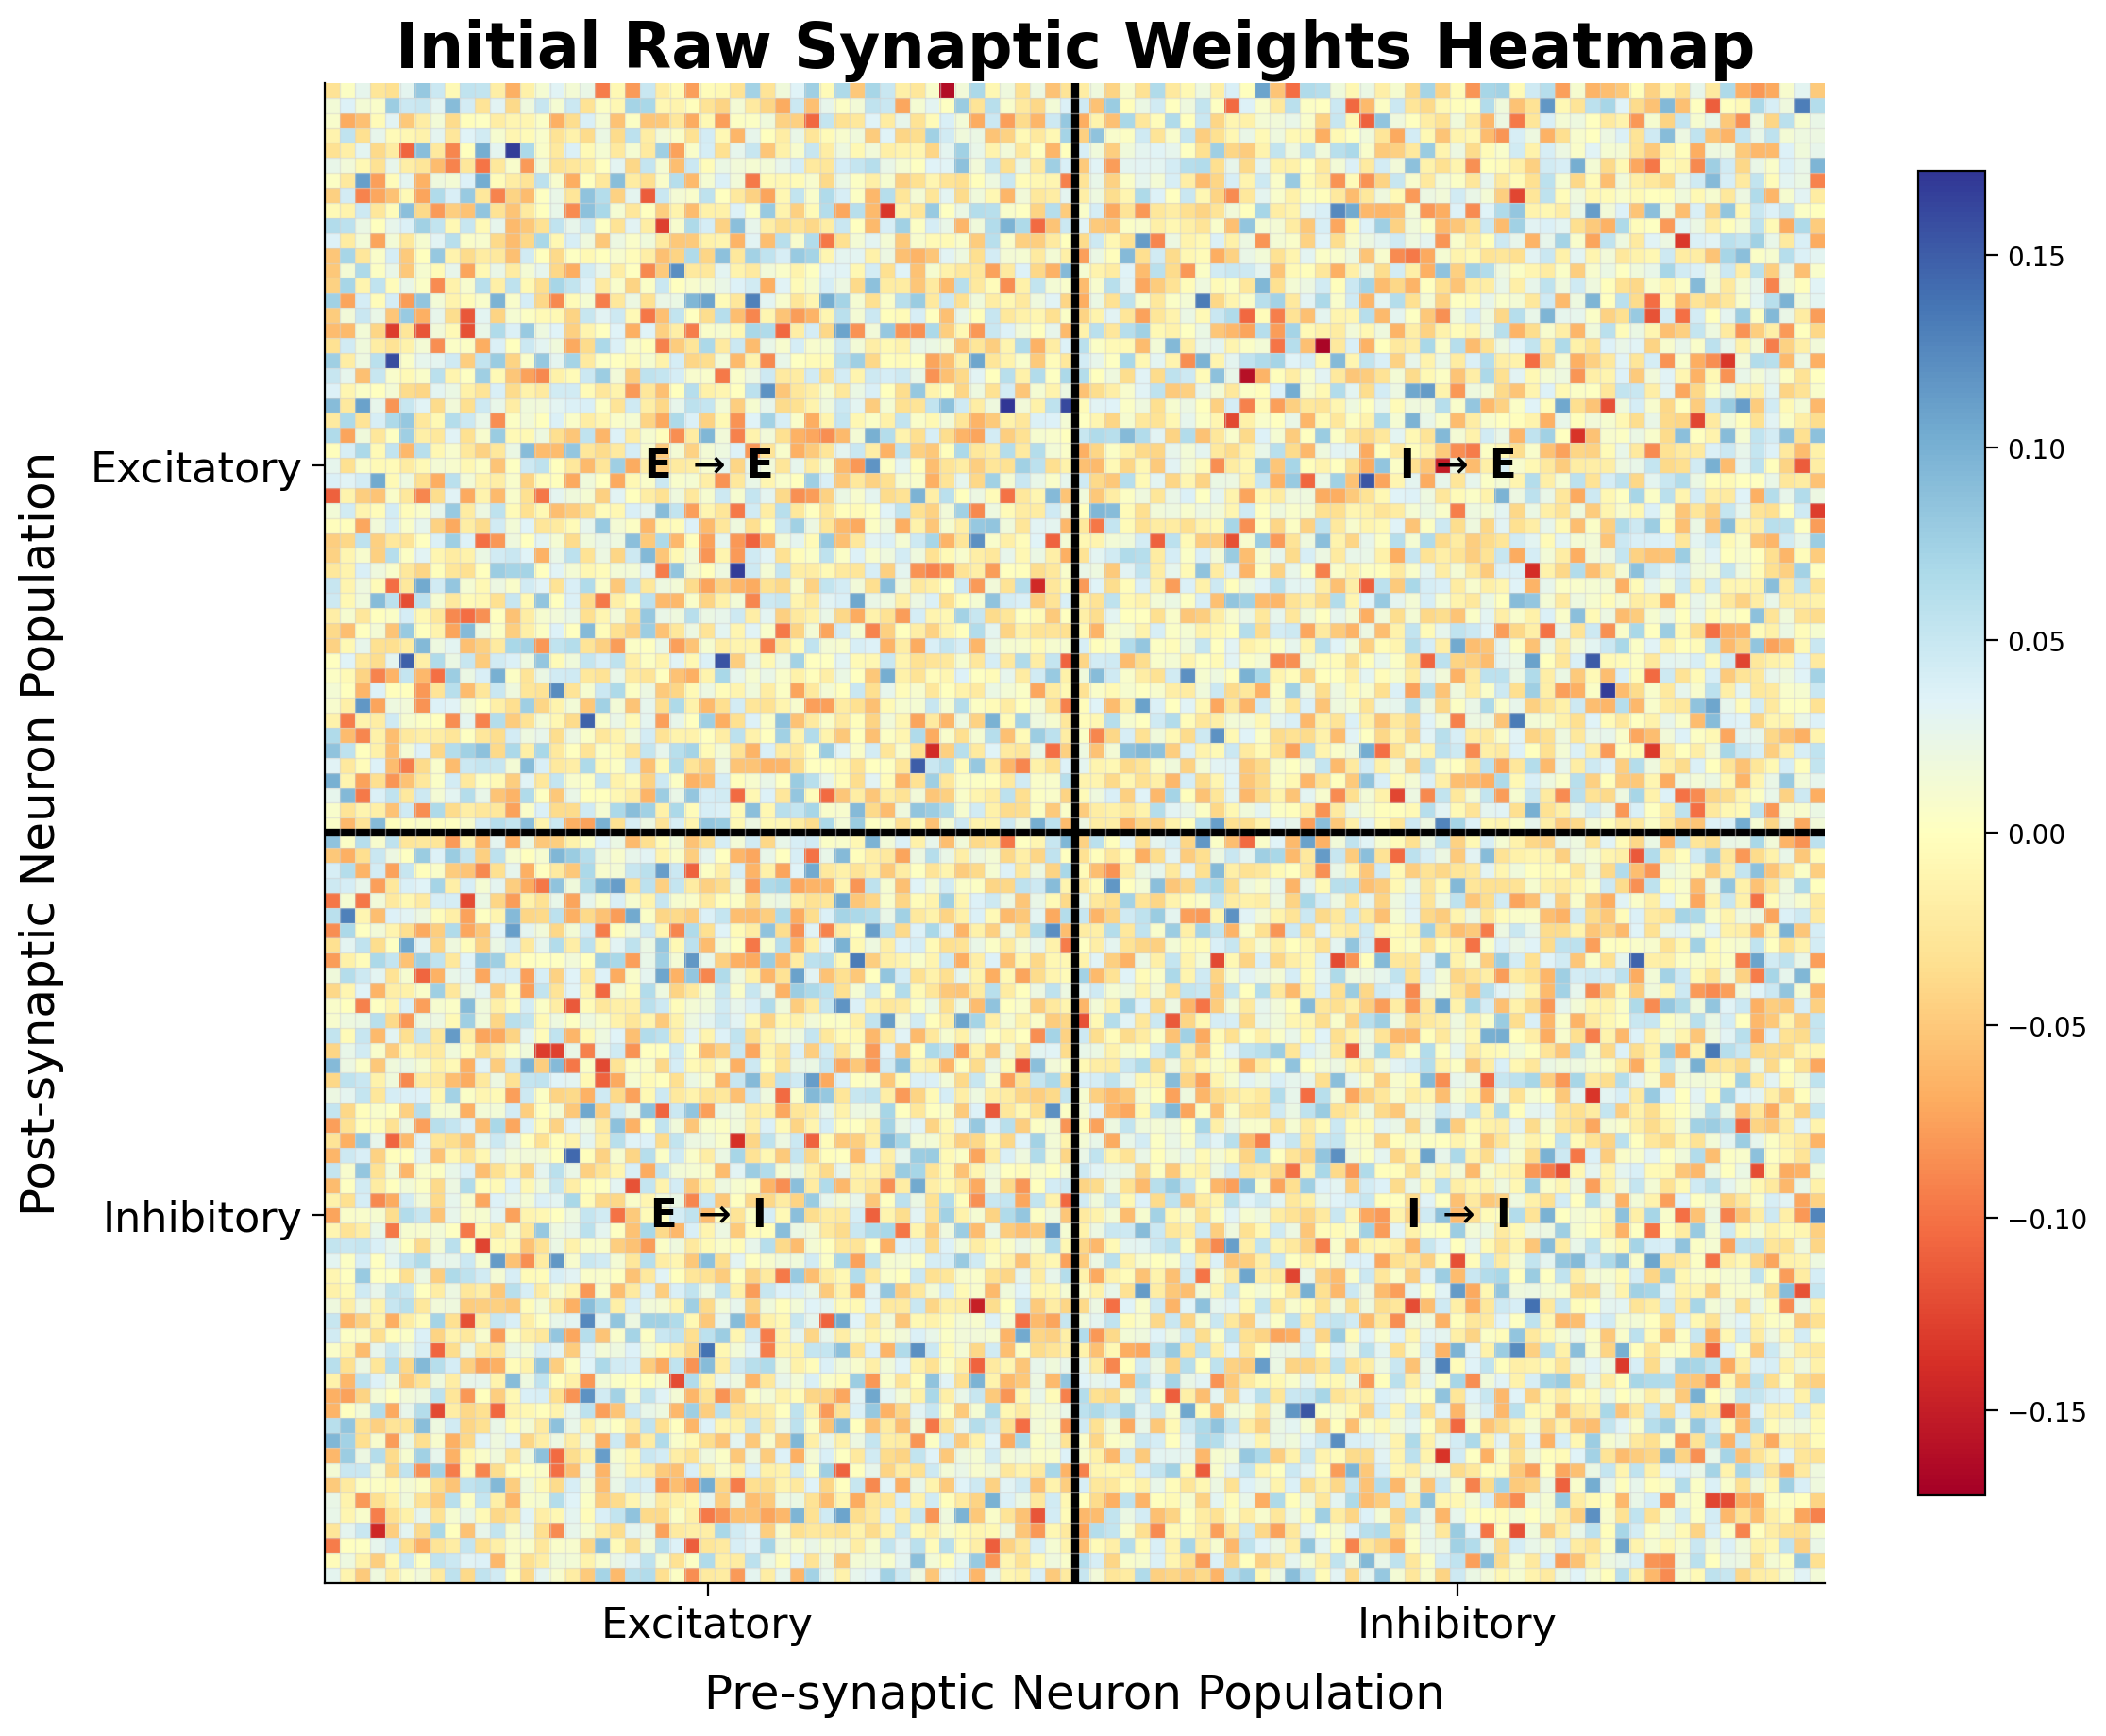

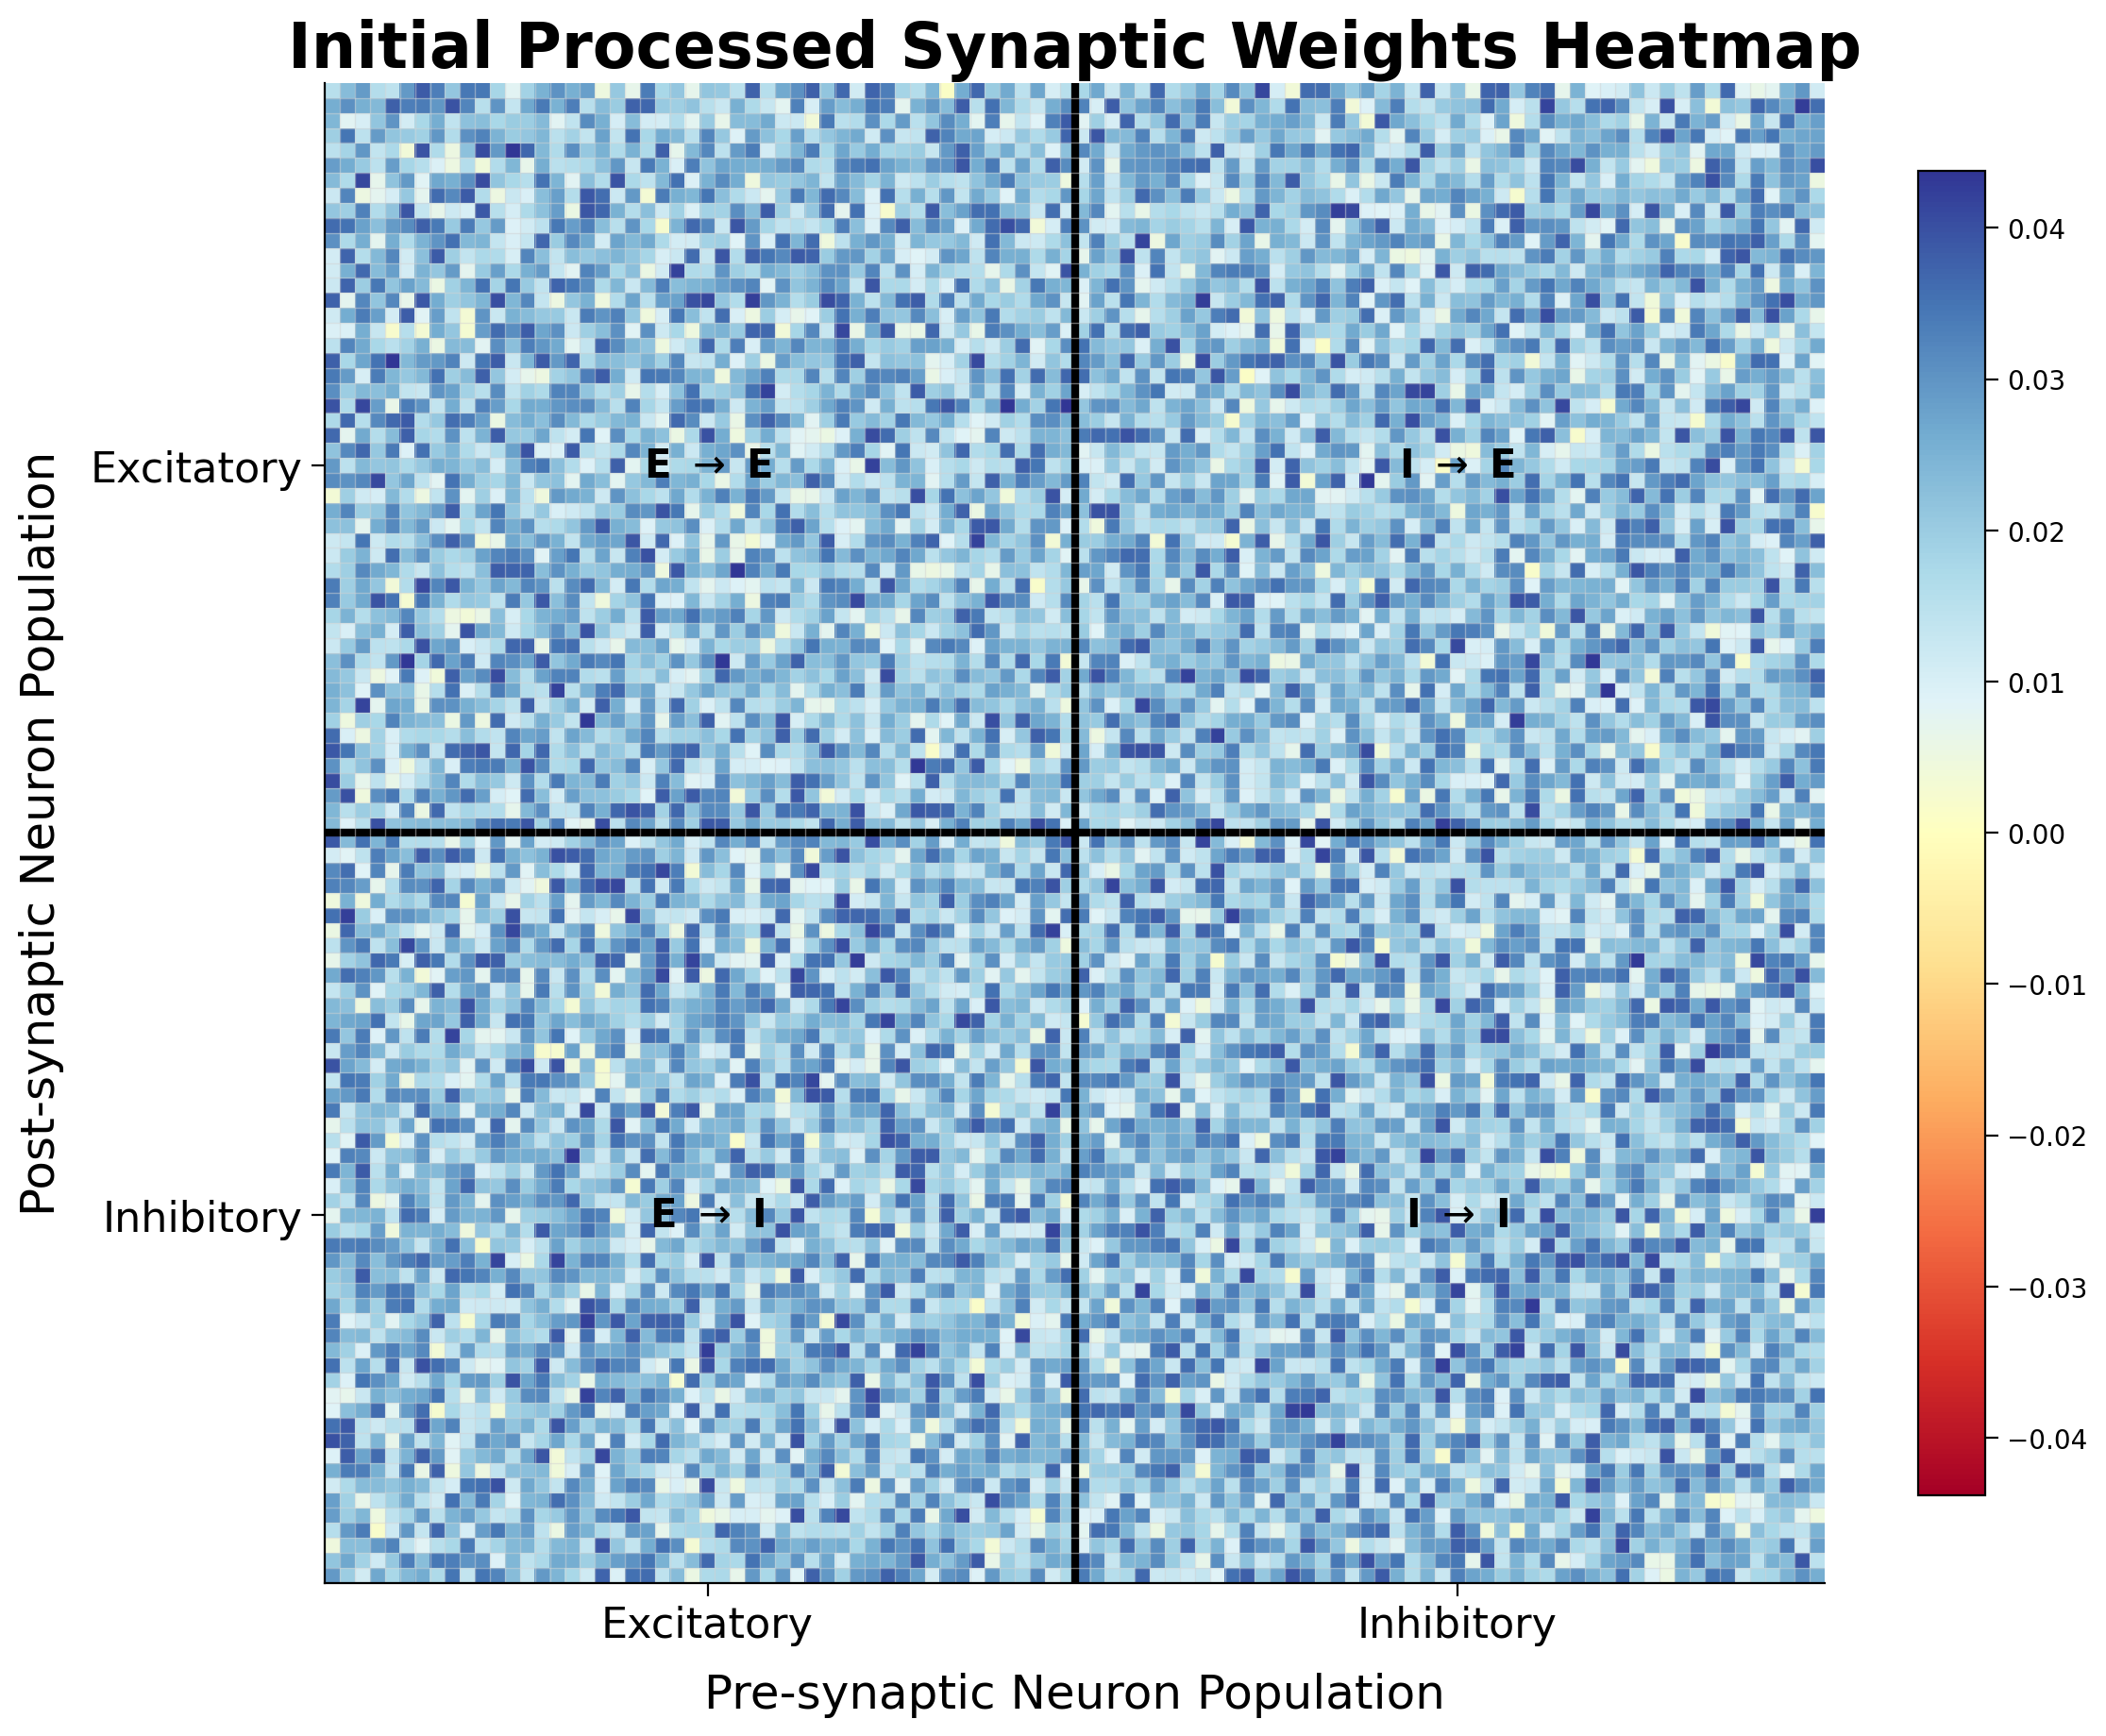

In [46]:
initial_checkpoint = torch.load(initial_model_ckeckpoint, map_location=device)
initial_model = MorrisLecarSNN(input_size=2, output_size=2, chunk_size=chunk_size, NE=NE, NI=NI).to(device)
initial_model.load_state_dict(initial_checkpoint)
initial_state_dict = initial_model.state_dict()

upper_bound = 1 / math.sqrt(500)

RAW_INITIAL_STATE_DICT = {
    'omega_ee_raw': initial_state_dict['omega_ee_raw']*upper_bound,
    'omega_ei_raw': initial_state_dict['omega_ei_raw']*upper_bound,
    'omega_ie_raw': initial_state_dict['omega_ie_raw']*upper_bound,
    'omega_ii_raw': initial_state_dict['omega_ii_raw']*upper_bound}

Proc_INITIAL_STATE_DICT = {
    'omega_ee_raw': torch.sigmoid(initial_state_dict['omega_ee_raw'])*upper_bound,
    'omega_ei_raw': torch.sigmoid(initial_state_dict['omega_ei_raw'])*upper_bound,
    'omega_ie_raw': torch.sigmoid(initial_state_dict['omega_ie_raw'])*upper_bound,
    'omega_ii_raw': torch.sigmoid(initial_state_dict['omega_ii_raw'])*upper_bound}

plot_sampled_weights_heatmap(RAW_INITIAL_STATE_DICT, N_full=250, N_sub=50, title="Initial Raw Synaptic Weights Heatmap")
plot_sampled_weights_heatmap(Proc_INITIAL_STATE_DICT, N_full=250, N_sub=50, title="Initial Processed Synaptic Weights Heatmap")

0.20272818
Computing eigenvalues for Eigenvalue Spectrum of RAW Initial Weights (Matrix size: (500, 500))...


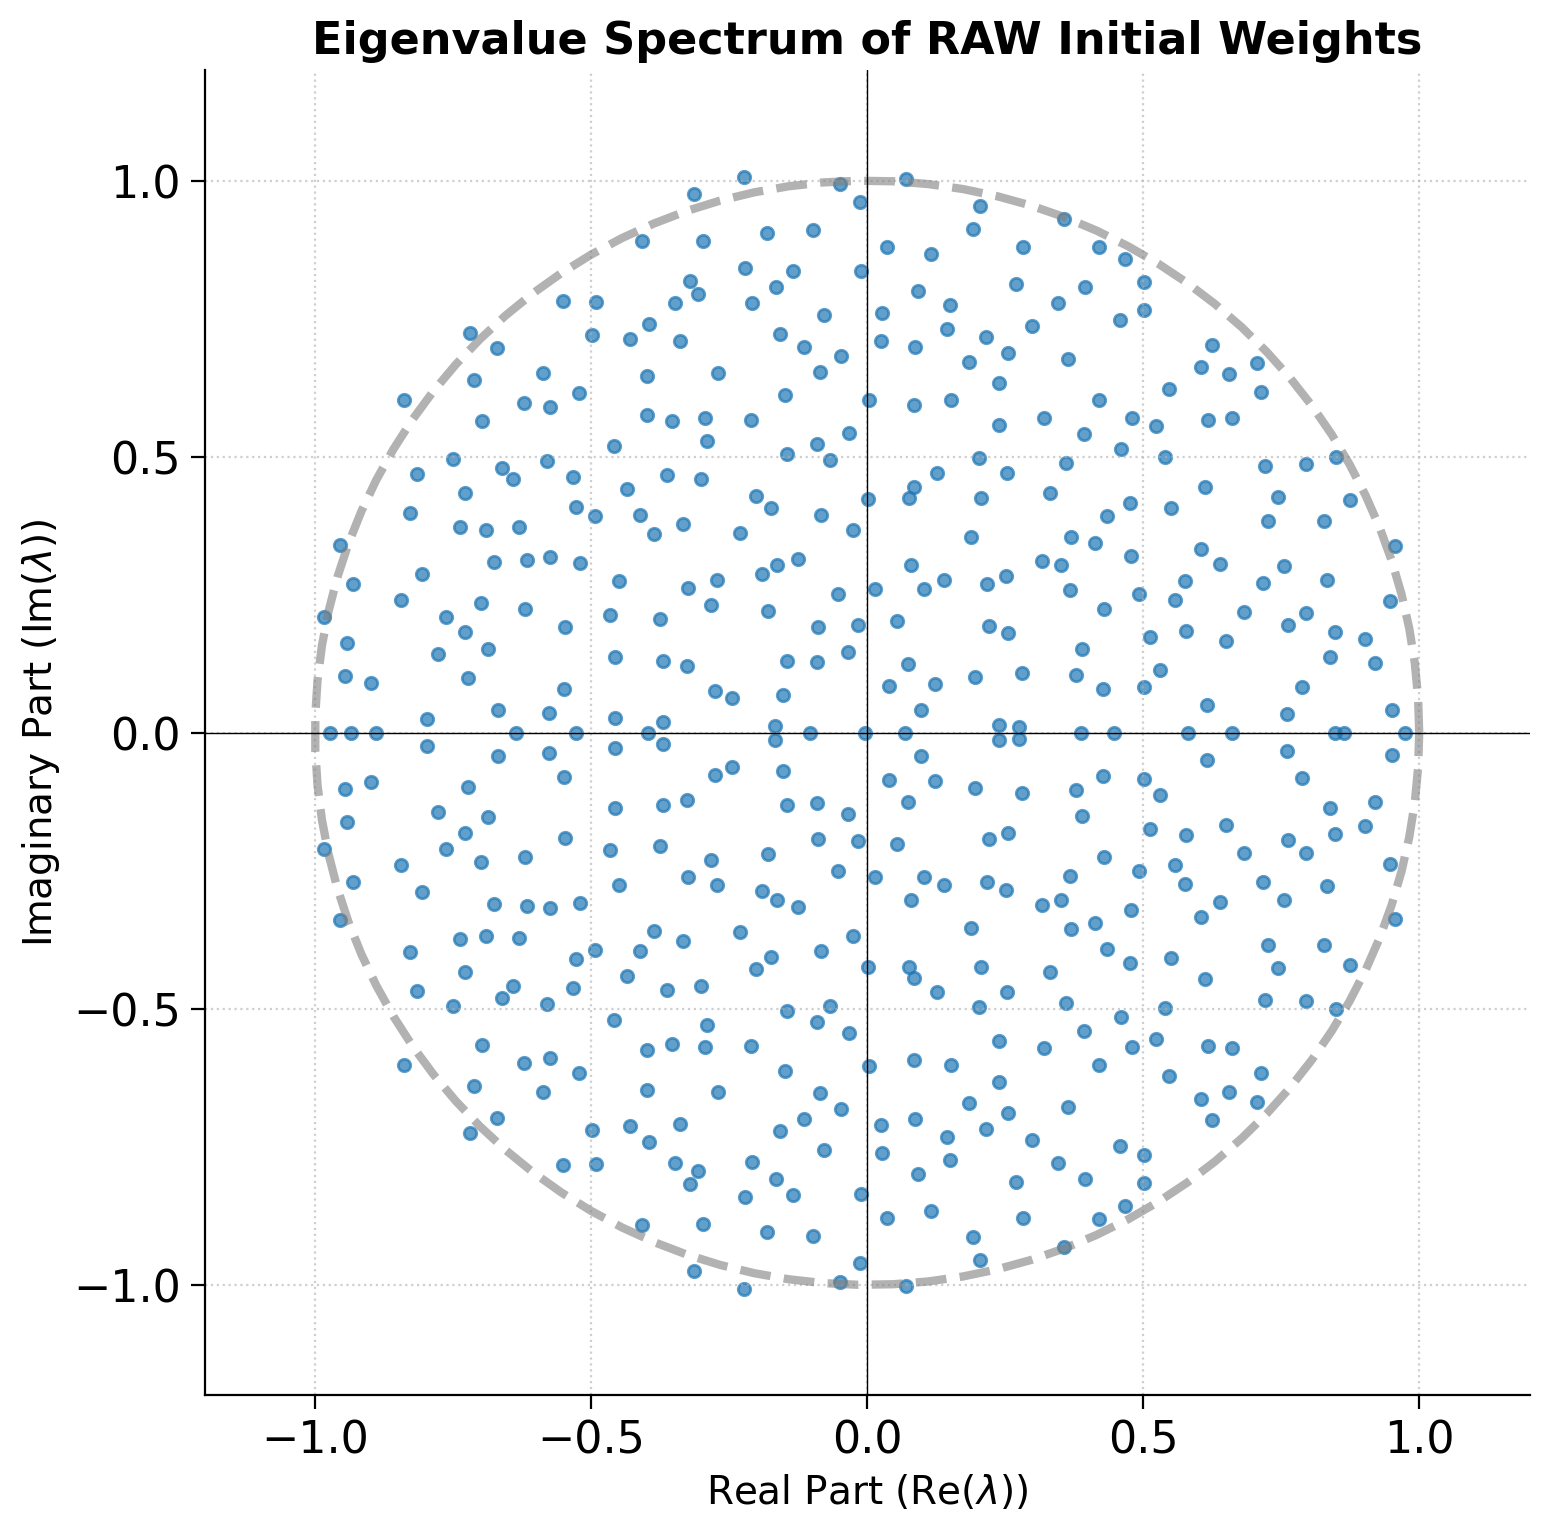

0.044245858
Computing eigenvalues for Eigenvalue Spectrum of Processed Initial Weights (Matrix size: (500, 500))...


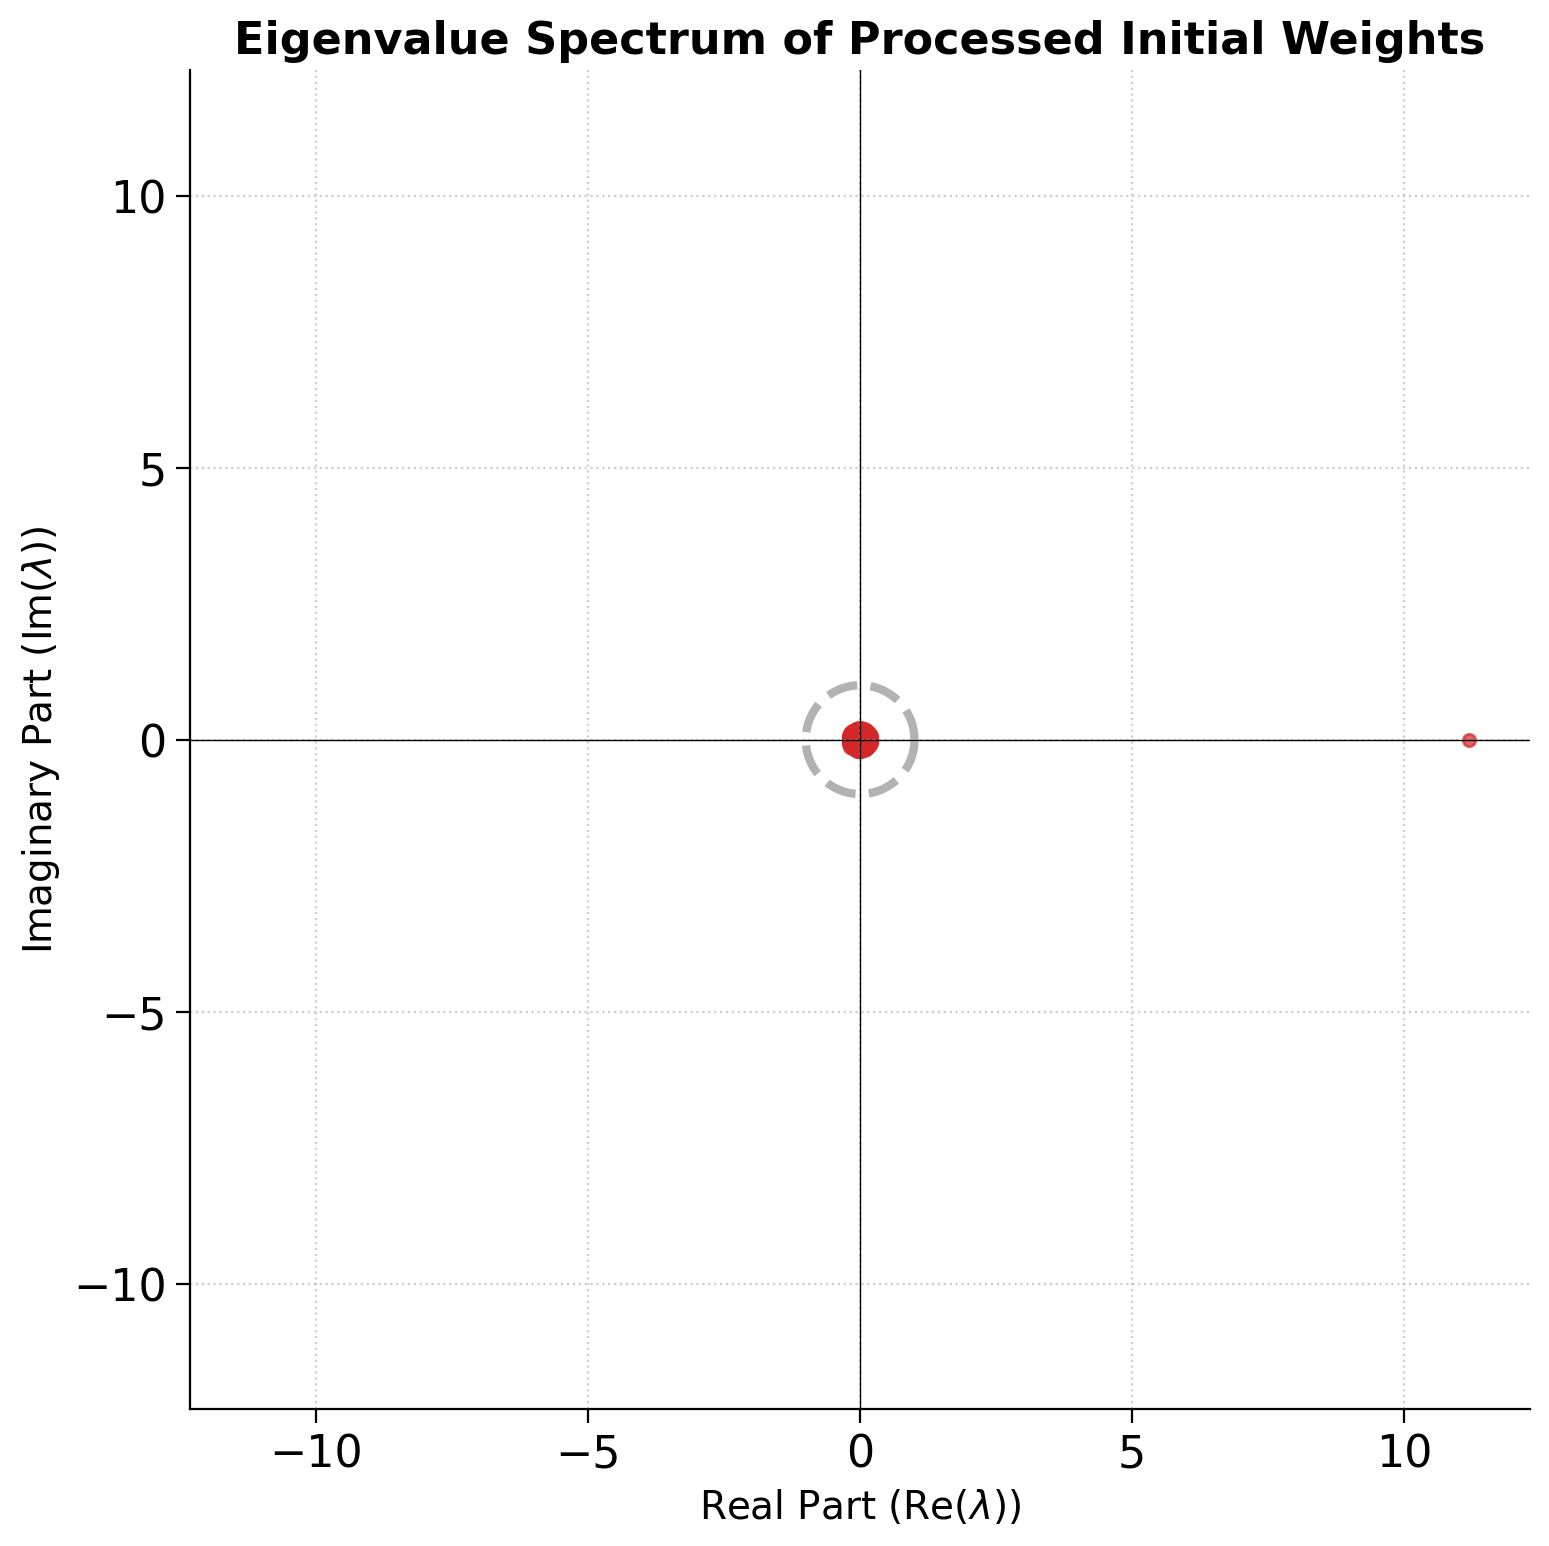

In [47]:
plot_full_spectrum(RAW_INITIAL_STATE_DICT, title="Eigenvalue Spectrum of RAW Initial Weights", color='tab:blue')
plot_full_spectrum(Proc_INITIAL_STATE_DICT, title="Eigenvalue Spectrum of Processed Initial Weights", color='tab:red')

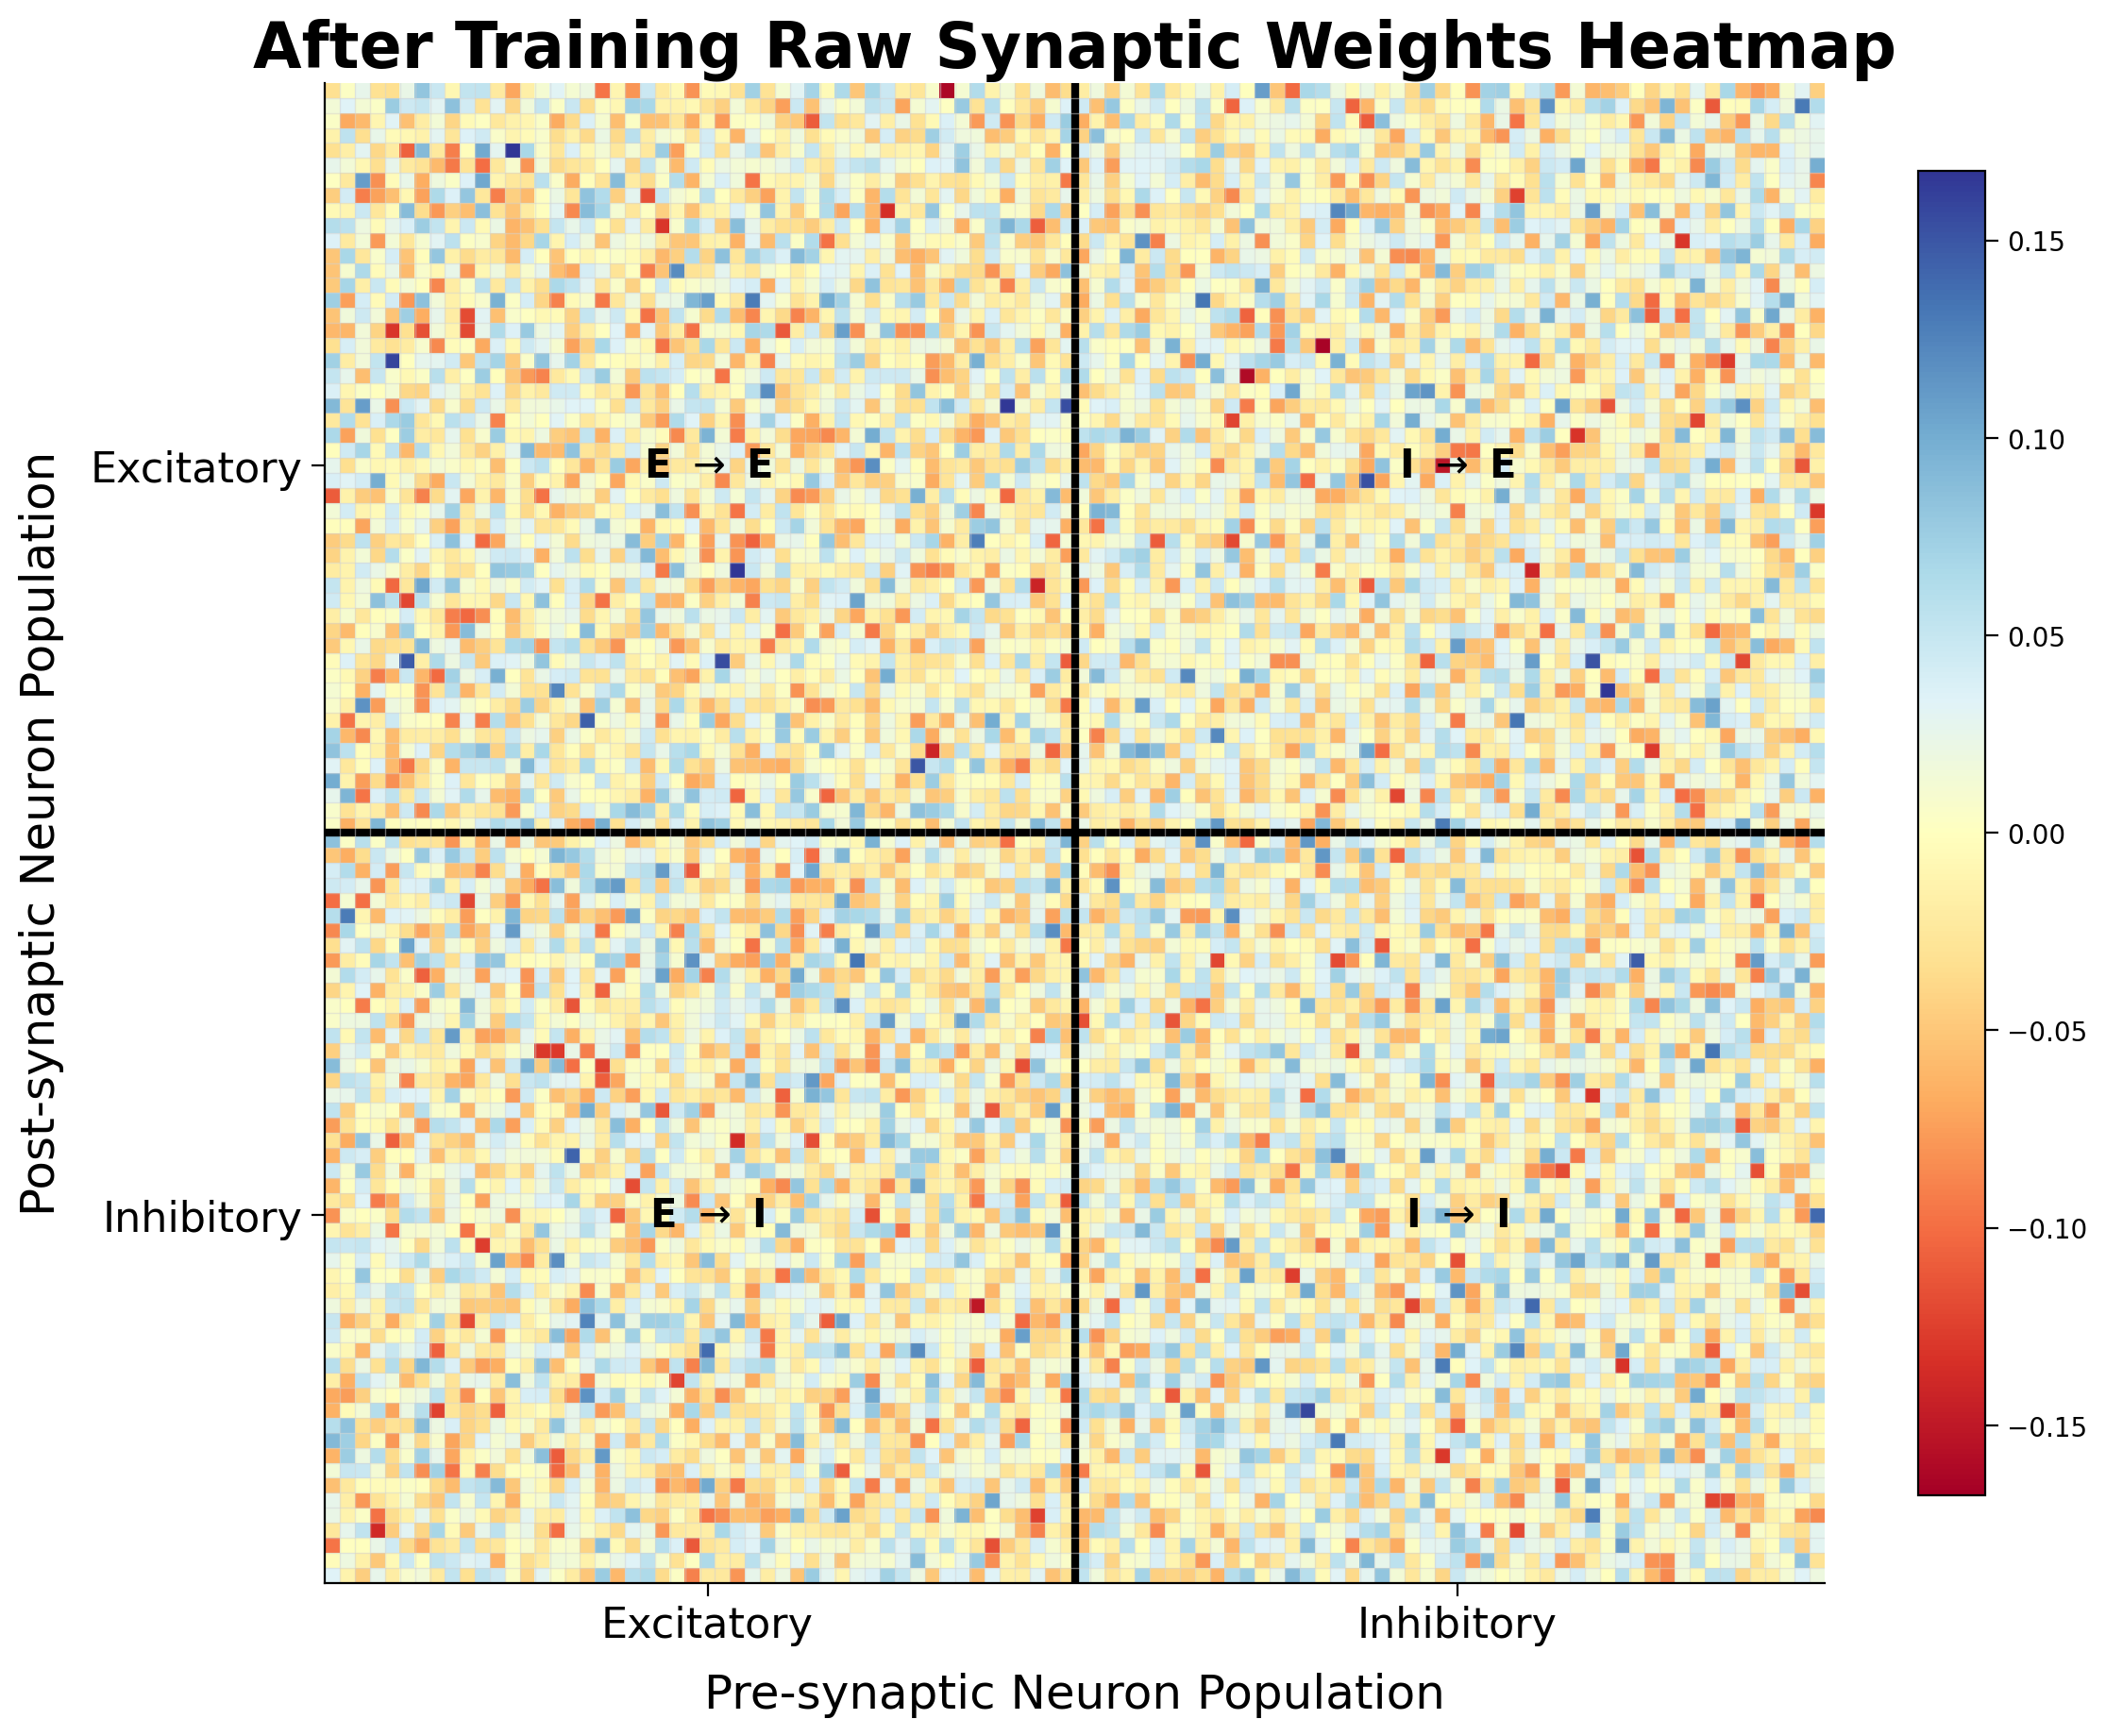

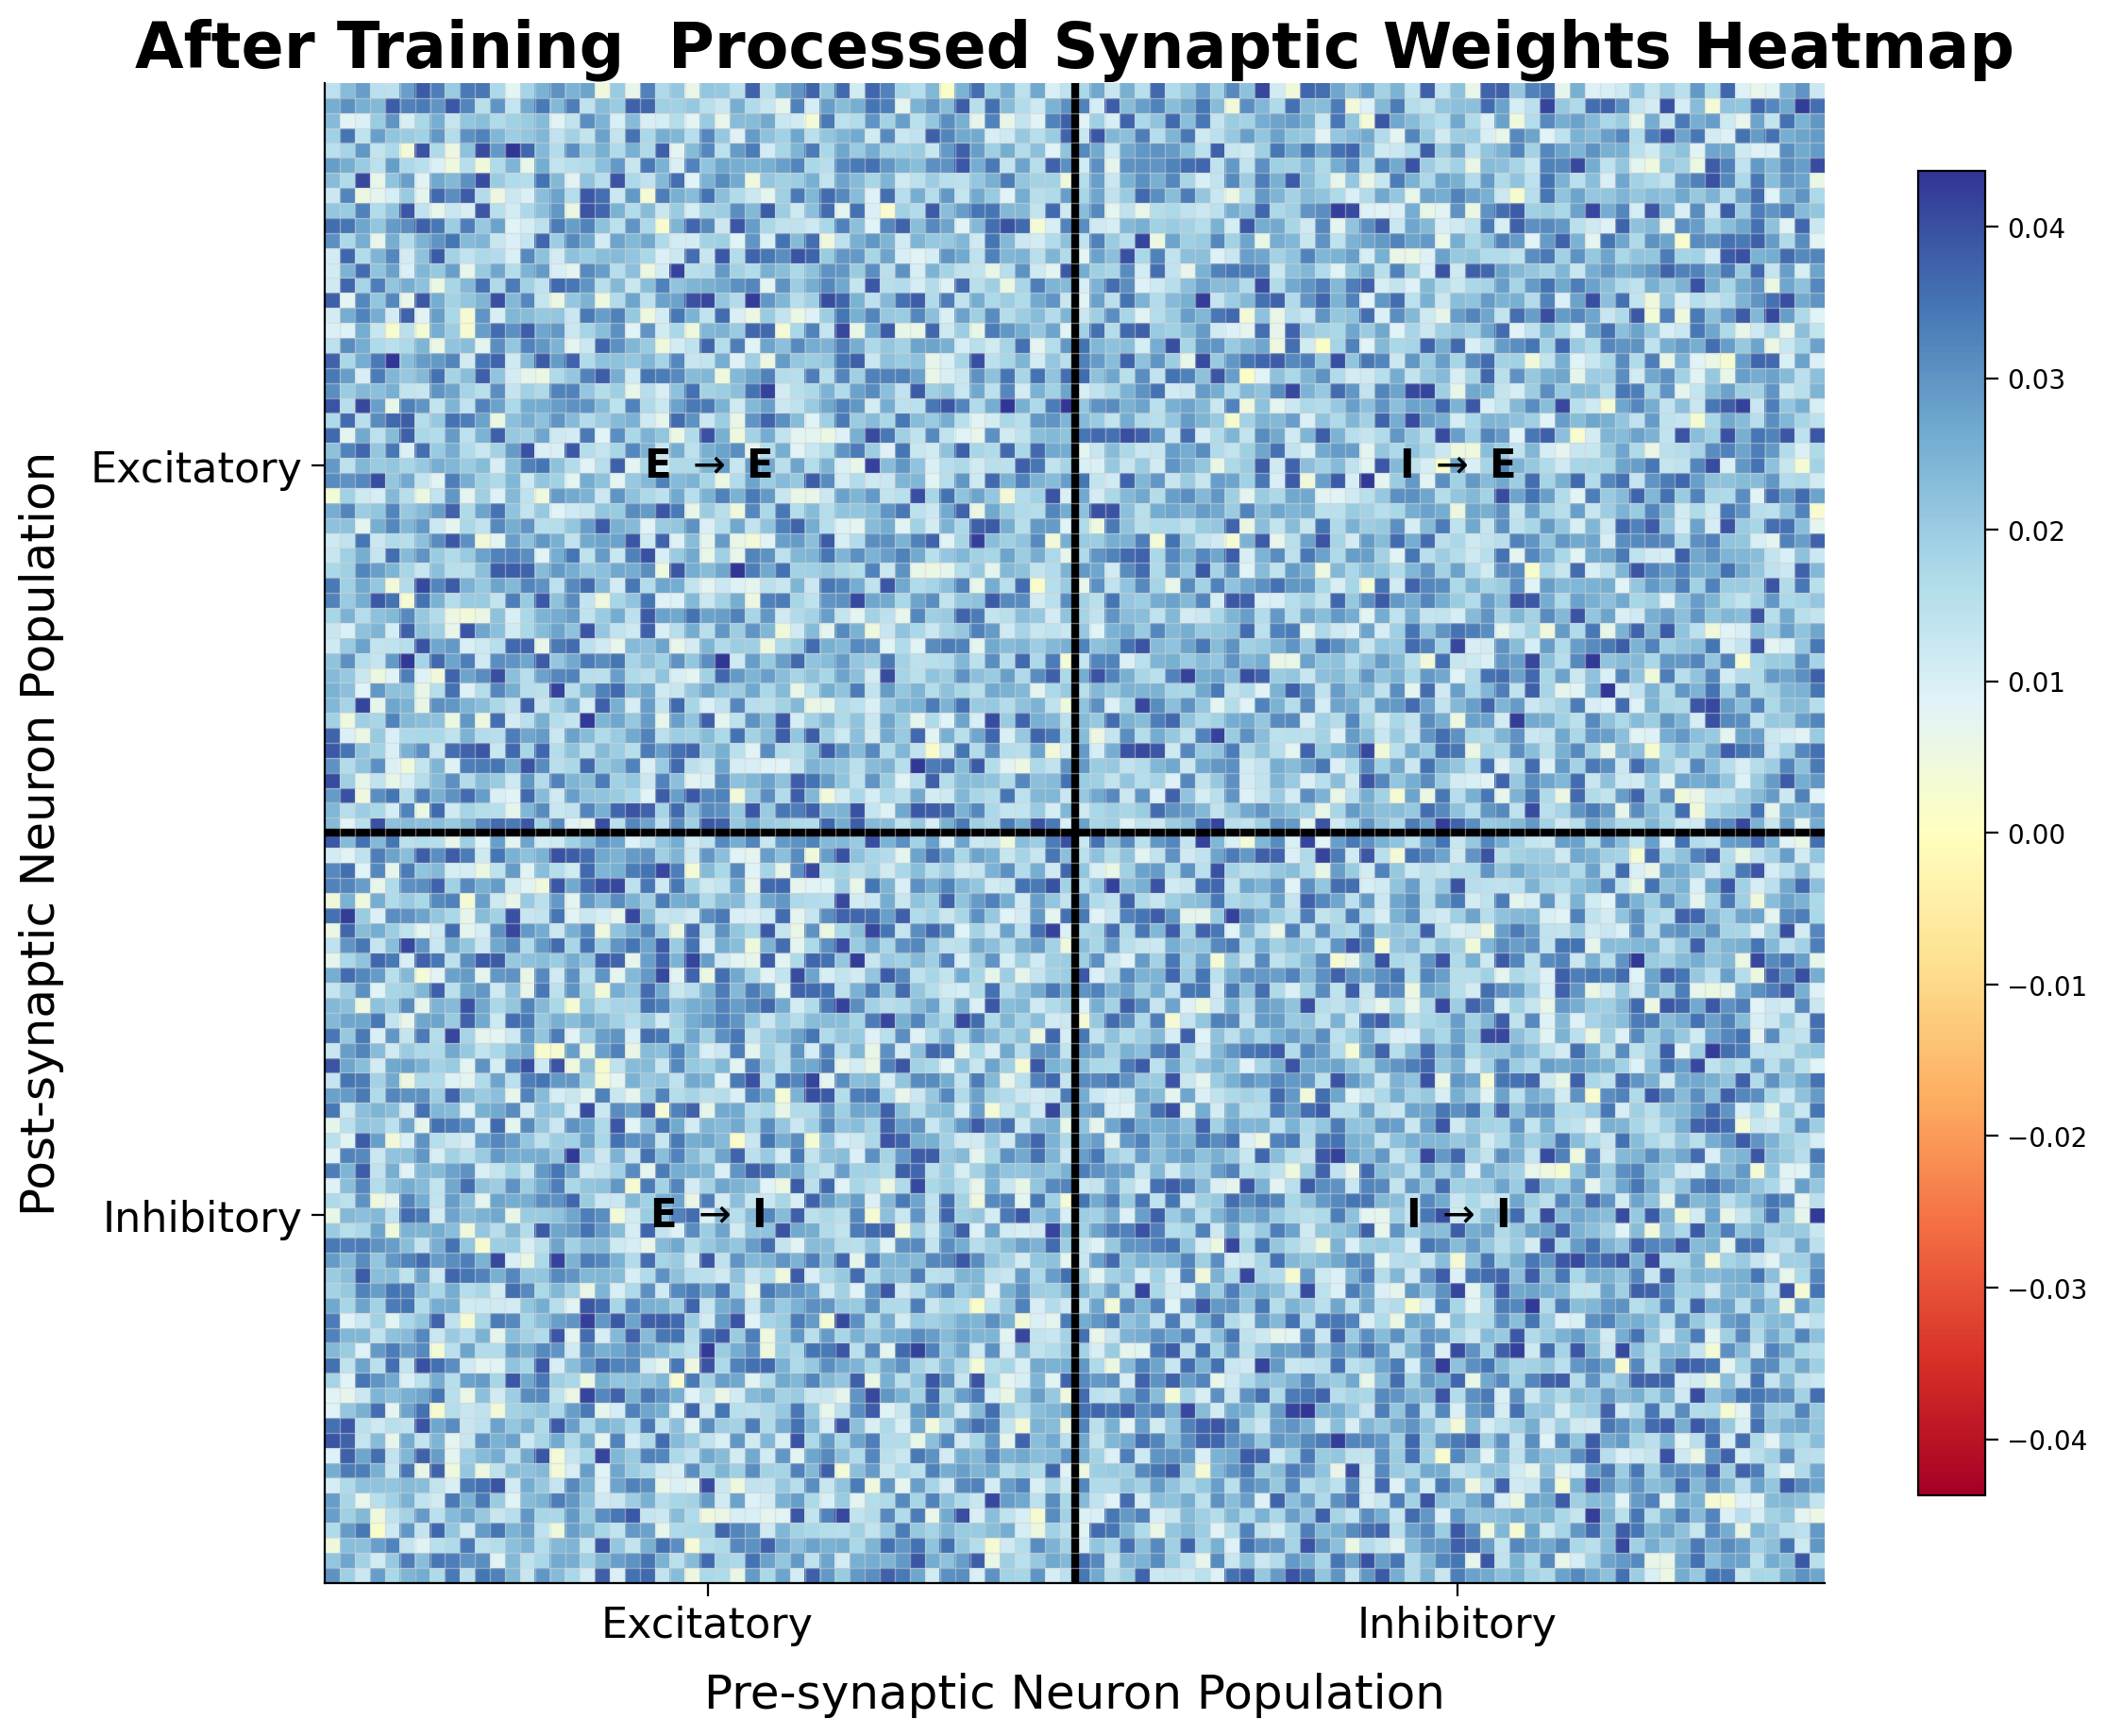

In [48]:
final_state_dict = trained_model.state_dict()
upper_bound = 1 / math.sqrt(500)

RAW_FINAL_STATE_DICT = {
    'omega_ee_raw': final_state_dict['omega_ee_raw']*upper_bound,
    'omega_ei_raw': final_state_dict['omega_ei_raw']*upper_bound,
    'omega_ie_raw': final_state_dict['omega_ie_raw']*upper_bound,
    'omega_ii_raw': final_state_dict['omega_ii_raw']*upper_bound}

Proc_FINAL_STATE_DICT = {
    'omega_ee_raw': torch.sigmoid(final_state_dict['omega_ee_raw'])*upper_bound,
    'omega_ei_raw': torch.sigmoid(final_state_dict['omega_ei_raw'])*upper_bound,
    'omega_ie_raw': torch.sigmoid(final_state_dict['omega_ie_raw'])*upper_bound,
    'omega_ii_raw': torch.sigmoid(final_state_dict['omega_ii_raw'])*upper_bound}

plot_sampled_weights_heatmap(RAW_FINAL_STATE_DICT, N_full=250, N_sub=50, title="After Training Raw Synaptic Weights Heatmap")
plot_sampled_weights_heatmap(Proc_FINAL_STATE_DICT, N_full=250, N_sub=50, title="After Training  Processed Synaptic Weights Heatmap")

0.20299946
Computing eigenvalues for Eigenvalue Spectrum of RAW After Training Weights (Matrix size: (500, 500))...


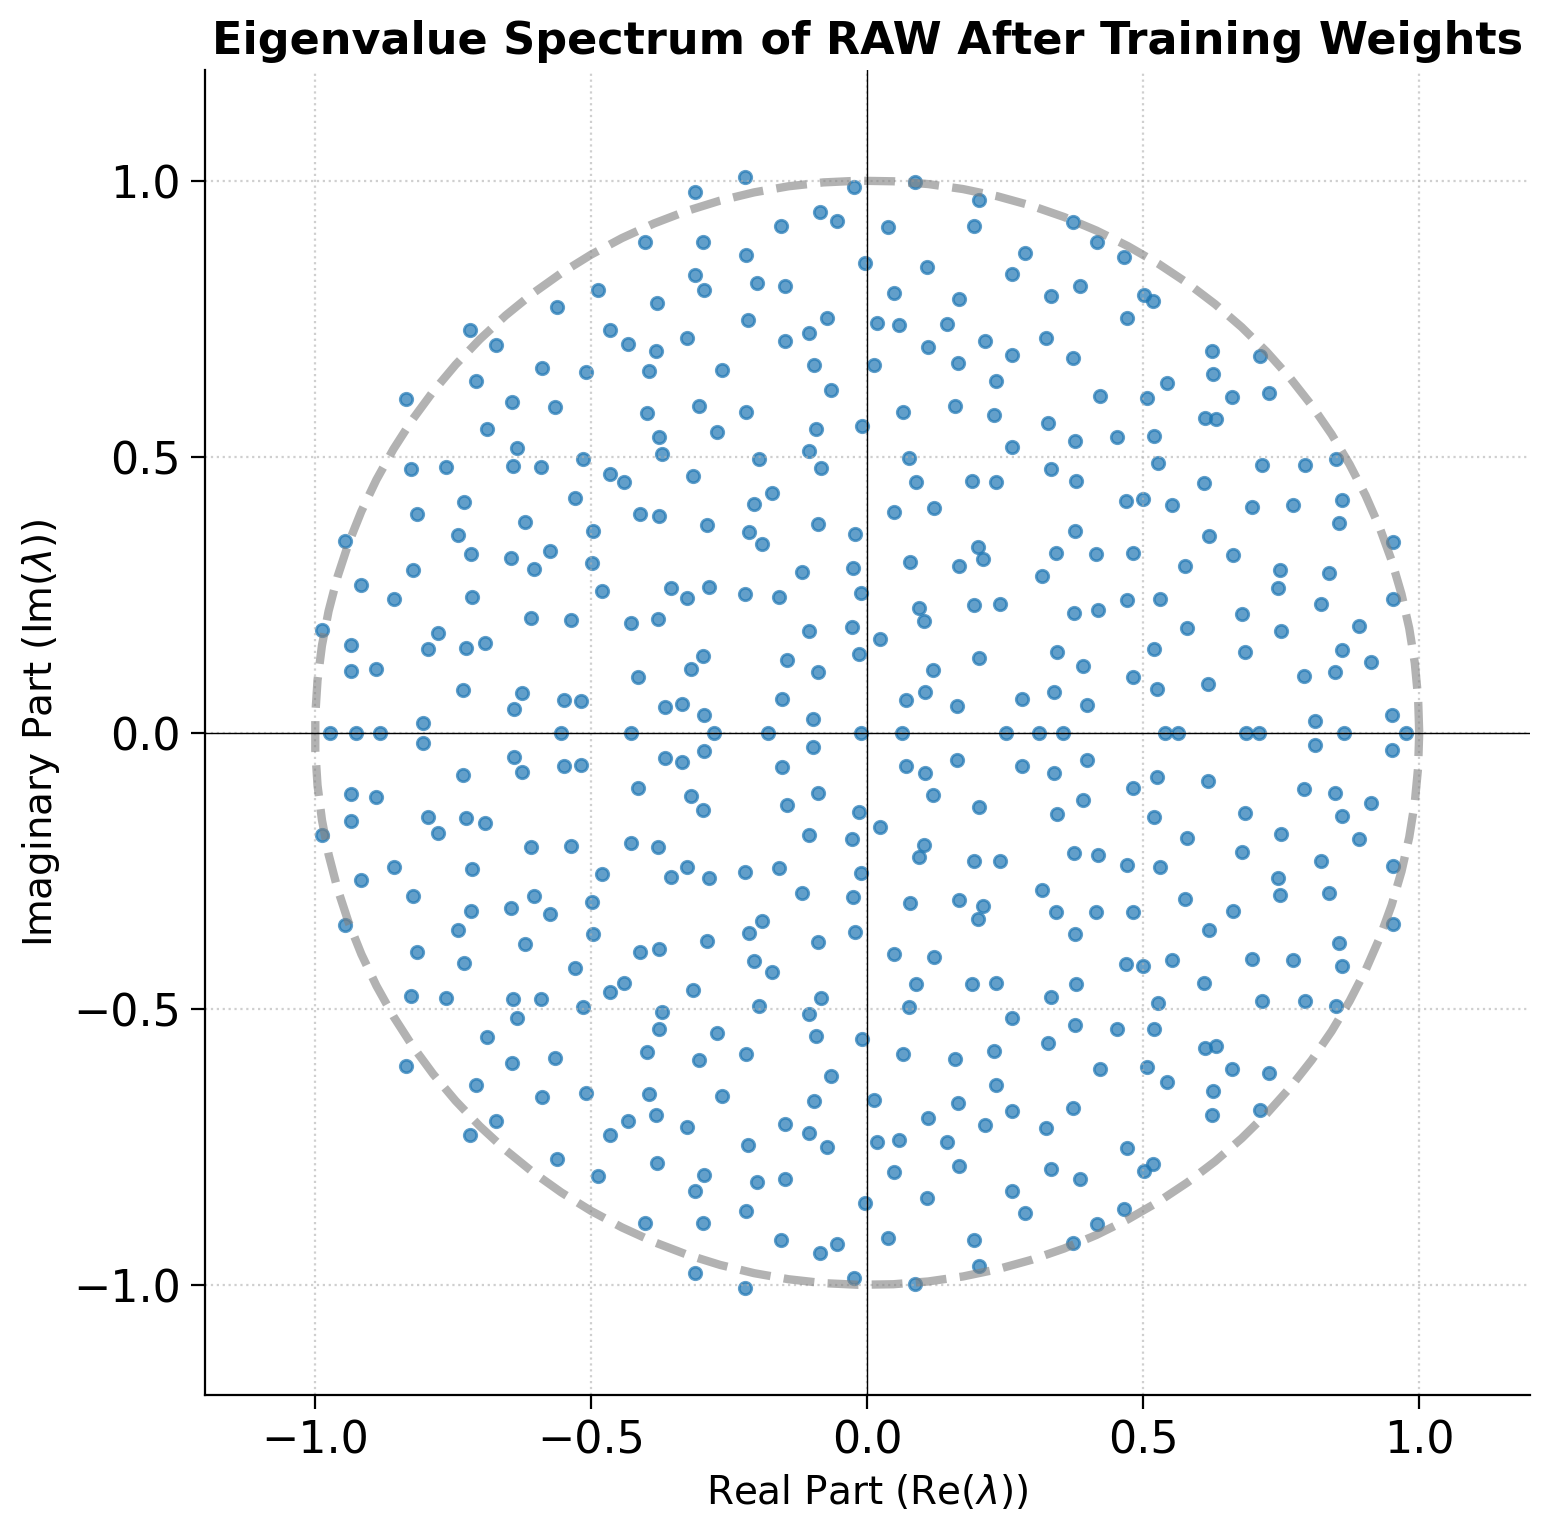

0.044248704
Computing eigenvalues for Eigenvalue Spectrum of Processed After Training  Weights (Matrix size: (500, 500))...


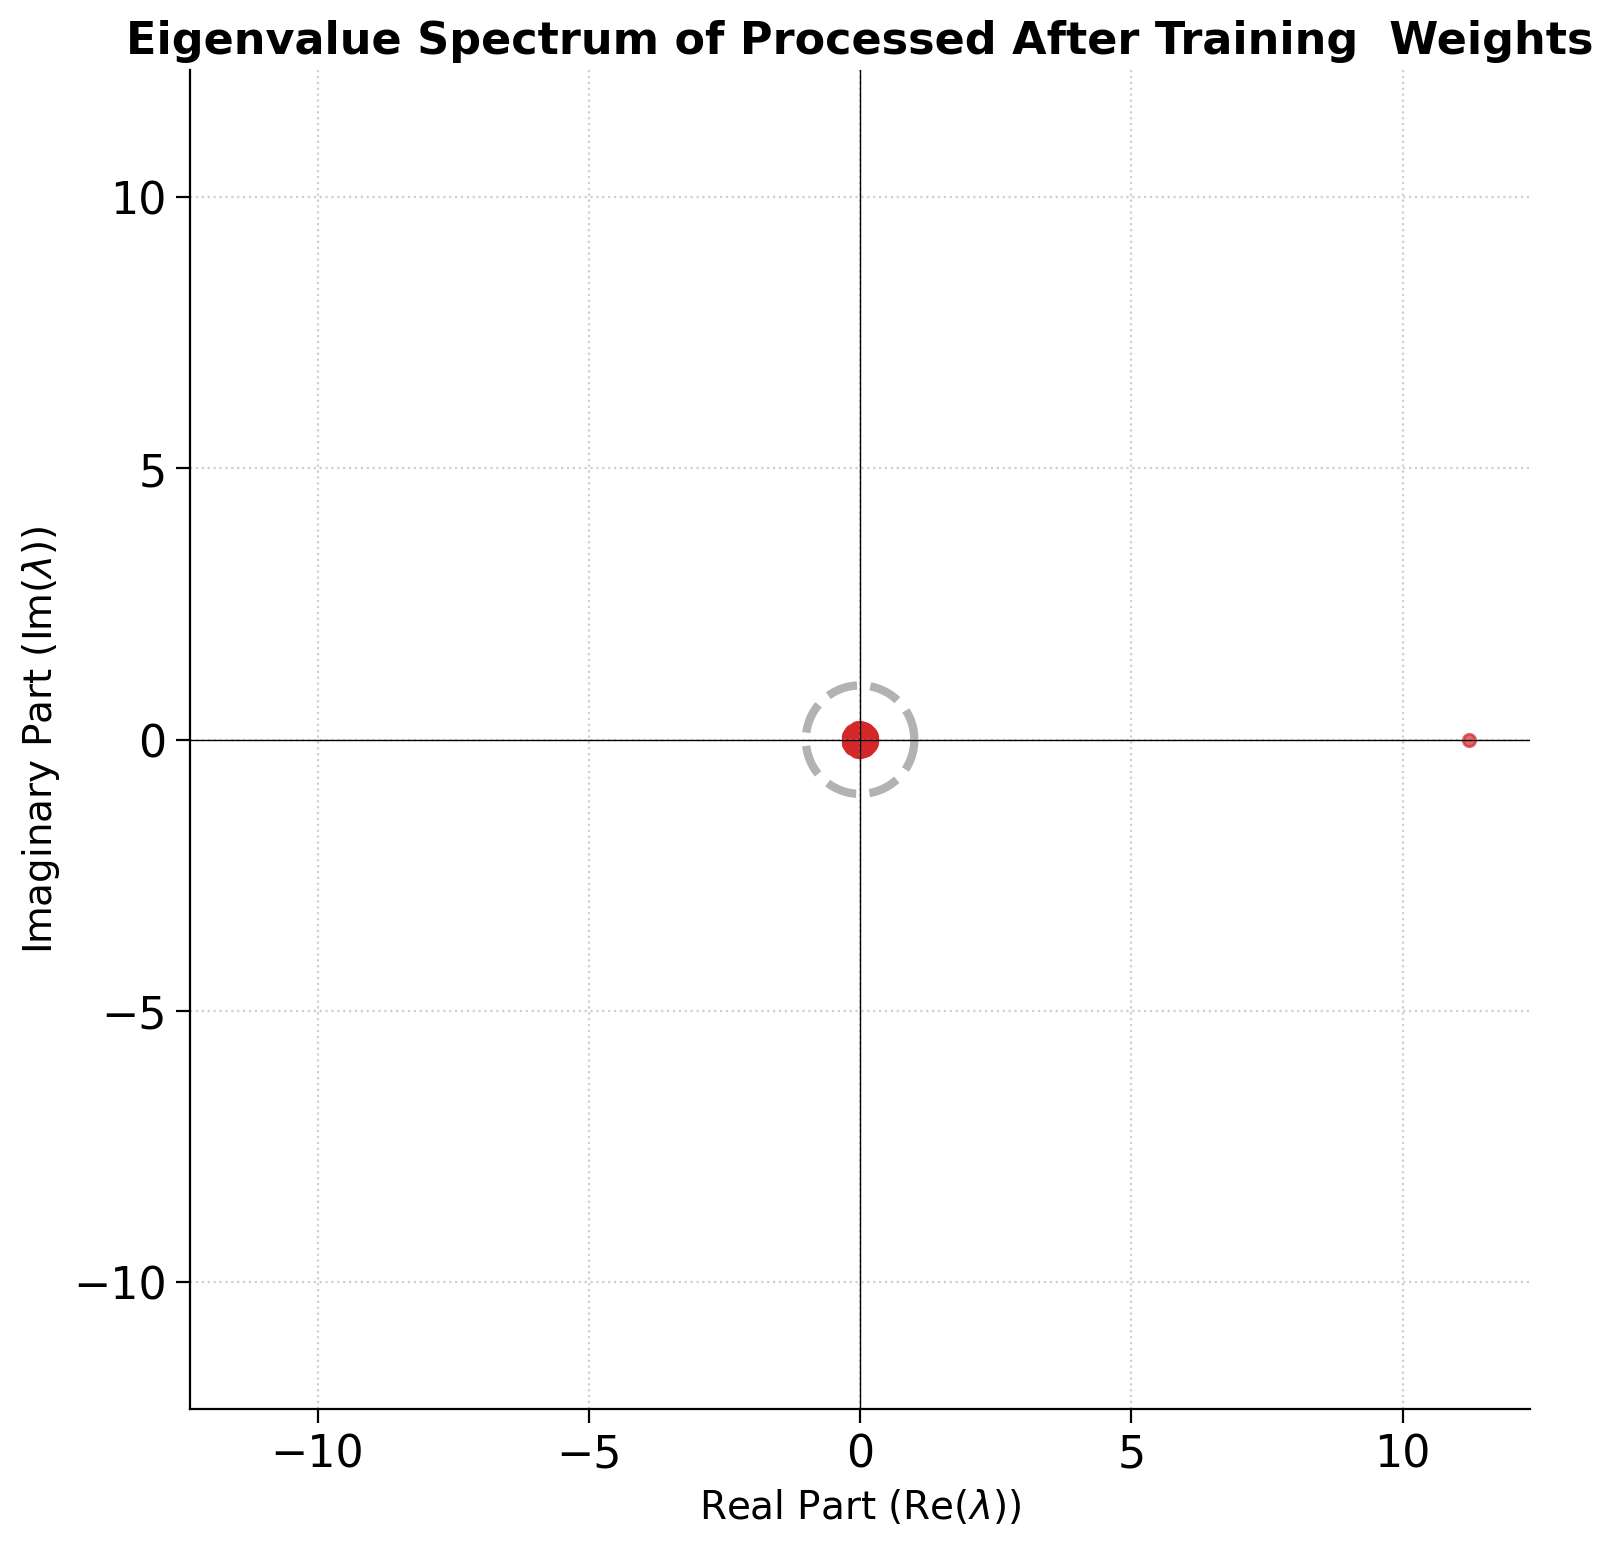

In [49]:
plot_full_spectrum(RAW_FINAL_STATE_DICT, title="Eigenvalue Spectrum of RAW After Training Weights", color='tab:blue')
plot_full_spectrum(Proc_FINAL_STATE_DICT, title="Eigenvalue Spectrum of Processed After Training  Weights", color='tab:red')